# C26 — RENIPED GeoAI · v3.3.2 (versión para envío)

Denuncias por desaparición de personas (RENIPED/SIDPOL, MININTER), Perú 2019–2025.
Pipeline reproducible: territorios prioritarios, estados espaciotemporales, estructura espacial y validación multinivel. Ejecutar de arriba abajo
(≈30 min en Colab; la Celda 12 concentra casi todo el tiempo).

| Celda | Contenido |
|---|---|
| 1 | Entorno, estructura del repositorio, versiones |
| 2 | Módulos del paquete `reniped` (`src/reniped/*.py`), perfil de hardware y **pruebas automáticas** |
| 3 | Subida y verificación de datos por SHA-256 |
| 4 | Plan congelado para la revisión (v3.3.2) y almacén de resultados |
| 5 | Panel departamento-mes y tasas con exposición observada y total |
| 5b | **Territorios prioritarios**: razón de tasas frente al resto del país, IC 95 % y FDR |
| 6 | Variables por fold y diagnóstico de rango de los espacios E1/E2/E3 |
| 7 | Selección de K: Gap desde K=1, bootstrap por unidades y bloques temporales |
| 8 | Multialgoritmo con etiquetas semánticas y perfiles |
| 9 | Auditoría del proxy territorial (nulo por bloques anuales; historia 6 y 12 meses) |
| 10 | Transferencia temporal 2024 / 2025 |
| 11 | Capa espacial: Queen y KNN geodésico, Moran, EB; LISA y Gi* con **p exactos** y FDR; mapas |
| 12 | **Etapa 3A — multiverso de especificaciones (M1 clustering, M2 espacial)** |
| 12b | **Figuras 1-5 del artículo** en español e inglés |
| 13 | Cierre: JSON estricto, README, CITATION, LICENSE, run_all.py, notebook, manifiesto y ZIP |

**Entradas (Celda 3):** CSV de RENIPED (SHA-256 `c41ebcce…`) y Excel del INEI (SHA-256 `9436df29…`).
El repositorio resultante también se ejecuta sin notebook con `python run_all.py`; las pruebas, con `python -m pytest -q tests`.

**Cambio v3.3–v3.3.2:** se añade la etapa de territorios prioritarios (objetivo aplicado del estudio), la razón de tasas anual (T14b), el perfil de los estados (T04c, T04d), la sensibilidad Benjamini–Yekutieli y las cinco figuras del artículo; las etapas anteriores no cambian y deben reproducir exactamente los resultados de la v3.2.

**Entorno:** usa esta Celda 1 tal como está. Fija `libpysal` y `esda` a las versiones de referencia; instalar `esda` sin versión puede actualizar numpy y pandas y cambiar resultados.


In [1]:
# ======================================================================
# CELDA 1 — ENTORNO, ESTRUCTURA DEL REPOSITORIO Y PERFIL DE HARDWARE
# ======================================================================
import os
import sys
import subprocess
import importlib.metadata as _md
from pathlib import Path
from IPython.display import Image, display

EN_COLAB = "google.colab" in sys.modules
BASE = Path("/content") if EN_COLAB else Path.cwd()
ROOT = BASE / "C26_RENIPED_GeoAI"
for c in ["config", "data/raw", "data/external", "data/processed", "src/reniped",
          "results/tables", "results/figures", "results/figures_article", "notebooks", "tests"]:
    (ROOT / c).mkdir(parents=True, exist_ok=True)
os.chdir(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

# Versiones de referencia del entorno Colab verificado (2026-09-26)
REFERENCIA = {"libpysal": "4.14.1", "esda": "2.9.0"}
MINIMOS = {"numpy": "1.26", "pandas": "2.0", "scipy": "1.11", "scikit-learn": "1.3",
           "matplotlib": "3.7", "openpyxl": "3.1", "statsmodels": "0.14", "geopandas": "0.14"}
for pkg in list(MINIMOS) + list(REFERENCIA):
    try:
        v = _md.version(pkg)
    except _md.PackageNotFoundError:
        spec = f"{pkg}=={REFERENCIA[pkg]}" if pkg in REFERENCIA else pkg
        print(f"  instalando {spec}…")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", spec], check=True)
        v = _md.version(pkg)
    nota = ""
    if pkg in MINIMOS and tuple(int(x) for x in v.split(".")[:2]) < \
            tuple(int(x) for x in MINIMOS[pkg].split(".")):
        raise RuntimeError(f"{pkg} {v} < {MINIMOS[pkg]}: pip install -U {pkg}")
    if pkg in REFERENCIA and v != REFERENCIA[pkg]:
        nota = f"  (referencia {REFERENCIA[pkg]}; p por permutación pueden variar en el 3.er decimal)"
    print(f"  {pkg:<13} {v}{nota}")

print(f"\nProyecto: {ROOT} | Colab: {EN_COLAB} | Python {sys.version.split()[0]}")

  numpy         2.1.3
  pandas        2.2.3
  scipy         1.16.3
  scikit-learn  1.6.1
  matplotlib    3.10.0
  openpyxl      3.1.5
  statsmodels   0.15.0
  geopandas     1.1.4
  libpysal      4.14.1
  esda          2.9.0

Proyecto: /content/C26_RENIPED_GeoAI | Colab: True | Python 3.13.15


## Celda 2 — Módulos del paquete `reniped`
Cada subcelda escribe un archivo en `src/reniped/`. Es el código que se deposita con el artículo.

In [2]:
%%writefile src/reniped/__init__.py
"""RENIPED GeoAI — pipeline reproducible (C26-2026)."""
__version__ = "3.3.2"


Writing src/reniped/__init__.py


In [3]:
%%writefile src/reniped/io_utils.py
"""Lectura y validación del CSV oficial de RENIPED (MININTER / Datos Abiertos)."""
import hashlib
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

EXPECTED_COLUMNS = ["ANO", "MES", "UBIGEO_HECHO", "DPTO_HECHO", "PROV_HECHO",
                    "DIST_HECHO", "SEXO", "RANGO_EDAD", "NACIONALIDAD", "CANTIDAD"]
MISSING_TOKENS = {"", "NAN", "NA", "N/A", "NULL", "NONE", "-"}


def sha256_file(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


def norm_text(value):
    """Mayúsculas, sin diacríticos y con espacios colapsados."""
    s = unicodedata.normalize("NFKD", str(value)).encode("ascii", "ignore").decode()
    return " ".join(s.upper().split())


def _norm_col(c):
    s = norm_text(c).replace(" ", "_")
    return {"AO": "ANO", "ANIO": "ANO"}.get(s, s)


def load_raw(path, expected_sha256=None, encoding="latin1"):
    """Lee el CSV sin transformar los conteos y devuelve (df, auditoria)."""
    path = Path(path)
    digest = sha256_file(path)
    if expected_sha256 and digest != expected_sha256:
        raise ValueError(f"SHA-256 inesperado para {path.name}: {digest}")

    df = pd.read_csv(path, encoding=encoding, dtype=str, keep_default_na=False)
    df.columns = [_norm_col(c) for c in df.columns]
    missing_cols = set(EXPECTED_COLUMNS) - set(df.columns)
    if missing_cols:
        raise ValueError(f"Faltan columnas: {sorted(missing_cols)}")
    df = df[EXPECTED_COLUMNS].copy()

    for c in EXPECTED_COLUMNS:
        df[c] = df[c].str.strip()
        df.loc[df[c].str.upper().isin(MISSING_TOKENS), c] = np.nan

    for c in ["ANO", "MES", "CANTIDAD"]:
        if df[c].isna().any():
            raise ValueError(f"Valores faltantes en {c}")
        df[c] = pd.to_numeric(df[c], errors="raise").astype("int64")

    if not df["MES"].between(1, 12).all():
        raise ValueError("MES fuera de 1-12")
    if not (df["CANTIDAD"] > 0).all():
        raise ValueError("CANTIDAD no positiva")

    # UBIGEO siempre como texto de 6 dígitos (conserva el cero inicial)
    df["UBIGEO_HECHO"] = df["UBIGEO_HECHO"].str.zfill(6)
    df["DPTO_KEY"] = df["DPTO_HECHO"].map(norm_text)
    df["EDAD_DESCONOCIDA"] = df["RANGO_EDAD"].isna()
    df["SEXO_DESCONOCIDO"] = df["SEXO"].isna()

    key = ["UBIGEO_HECHO", "ANO", "MES", "RANGO_EDAD", "SEXO", "NACIONALIDAD"]
    dup = int(df.duplicated(key, keep=False).sum())

    audit = {
        "archivo": path.name,
        "sha256": digest,
        "bytes": path.stat().st_size,
        "filas": int(len(df)),
        "total_reportes": int(df["CANTIDAD"].sum()),
        "cobertura": f"{df.ANO.min()}-{df.loc[df.ANO == df.ANO.min(), 'MES'].min():02d} "
                     f"a {df.ANO.max()}-{df.loc[df.ANO == df.ANO.max(), 'MES'].max():02d}",
        "unidades_territoriales": int(df["DPTO_KEY"].nunique()),
        "clave_observacional": key,
        "filas_con_clave_duplicada": dup,
        "edad_desconocida": {"filas": int(df.EDAD_DESCONOCIDA.sum()),
                             "reportes": int(df.loc[df.EDAD_DESCONOCIDA, "CANTIDAD"].sum())},
        "sexo_desconocido": {"filas": int(df.SEXO_DESCONOCIDO.sum()),
                             "reportes": int(df.loc[df.SEXO_DESCONOCIDO, "CANTIDAD"].sum())},
        "reportes_por_anio": {int(k): int(v) for k, v in
                              df.groupby("ANO")["CANTIDAD"].sum().items()},
    }
    if dup:
        raise ValueError(f"La clave observacional no es única ({dup} filas)")
    return df, audit


Writing src/reniped/io_utils.py


In [4]:
%%writefile src/reniped/population.py
"""Denominadores oficiales INEI (Cuadro N.° 01, 2018-2026) para las 26 unidades."""
import re

import numpy as np
import openpyxl
import pandas as pd

from .io_utils import norm_text

YEARS_XLSX = list(range(2018, 2027))


def _clean_name(s):
    return re.sub(r"\s*\d+\s*/.*$", "", str(s)).strip()


def read_inei(xlsx_path):
    wb = openpyxl.load_workbook(xlsx_path, read_only=True, data_only=True)
    rows = list(wb.worksheets[0].iter_rows(values_only=True))
    header = next(i for i, r in enumerate(rows) if r[2] == 2018 and r[10] == 2026)
    recs = []
    for r in rows[header + 1:]:
        code = str(r[0]).strip().replace("\xa0", "") if r[0] is not None else ""
        if re.fullmatch(r"\d{6}", code):
            vals = [float(v) if isinstance(v, (int, float)) else np.nan for v in r[2:11]]
            recs.append([code, _clean_name(r[1])] + vals)
    ine = pd.DataFrame(recs, columns=["UBIGEO", "NOMBRE"] + YEARS_XLSX)
    if ine["UBIGEO"].duplicated().any():
        raise ValueError("UBIGEO duplicado en el Excel INEI")
    return ine


def build_units(ine, years):
    """Lima Metropolitana = 150100; Región Lima = 150000 − 150100; Callao = 070000."""
    idx = ine.set_index("UBIGEO")
    deps = idx[idx.index.str.endswith("0000") & (idx.index != "000000")]
    rows = []
    for code, name in deps["NOMBRE"].items():
        if code == "150000":
            lm = idx.loc["150100", years]
            rows.append(["LIMA METROPOLITANA", "150100"] + list(lm))
            rows.append(["REGION LIMA", "150000-150100"] + list(idx.loc["150000", years] - lm))
        else:
            rows.append([norm_text(name), code] + list(deps.loc[code, years]))
    units = pd.DataFrame(rows, columns=["DPTO_KEY", "REGLA_UBIGEO"] + list(years))
    if len(units) != 26:
        raise ValueError(f"Se esperaban 26 unidades, hay {len(units)}")
    pais = idx.loc["000000", years].astype(float)
    if not np.allclose(units[list(years)].sum().values, pais.values):
        raise ValueError("La suma de las 26 unidades no coincide con el total nacional")
    long = units.melt(id_vars=["DPTO_KEY", "REGLA_UBIGEO"], value_vars=list(years),
                      var_name="ANO", value_name="POBLACION")
    long["ANO"] = long["ANO"].astype(int)
    long["POBLACION"] = long["POBLACION"].astype("int64")
    return long


Writing src/reniped/population.py


In [5]:
%%writefile src/reniped/config.py
"""Plan de análisis congelado para la revisión (v3.3.2) y su candado SHA-256.

El plan se fija antes de ejecutar el pipeline y su hash queda registrado. Esto
documenta que las decisiones no cambiaron durante la corrida; NO equivale a un
preregistro público previo al análisis.
"""
import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path

HUECOS_ENE_2023 = ["PIURA", "PUNO", "TACNA", "SAN MARTIN", "MOQUEGUA", "MADRE DE DIOS"]

PLAN = {
    "version_plan": "3.3.2",
    "estado": "Plan congelado para la revisión; no es un preregistro público.",
    "historial": [
        {"version": "2A-1.0", "fecha": "2026-09-25",
         "resumen": "Panel departamento-mes, K por bootstrap de filas, auditoría de proxy."},
        {"version": "2B-1.0", "fecha": "2026-09-26",
         "resumen": "Moran, LISA y Gi* con FDR; pesos Queen y KNN-4."},
        {"version": "3.0", "fecha": "2026-09-26",
         "resumen": "Correcciones tras revisión externa del paquete 2A+2B.",
         "cambios": [
             "Espacios de variables sin dependencia lineal entre sí (E1 relativo, E2 relativo+nivel, E3 nivel).",
             "Estabilidad por bootstrap de unidades y de bloques temporales; el de filas solo se reporta.",
             "Gap con K=1 para evaluar si hay evidencia de estructura agrupada.",
             "Nulo del NMI por permutación de unidades en bloques anuales.",
             "Etiquetas semánticas conservadas al transferir el modelo (LabeledKMeans).",
             "Jensen-Shannon reportado como distancia y como divergencia.",
             "Sensibilidad con historia completa de 12 meses.",
             "Gi* con pesos binarios explícitos (transform='B'); p locales bilaterales = min(1, 2·p_sim).",
             "KNN con distancias geodésicas (haversine).",
             "Tasas con exposición observada (principal) y total (sensibilidad).",
             "JSON estricto (sin NaN), manifiesto sin cachés, run_all.py y notebook en el paquete.",
         ]},
        {"version": "3.1", "fecha": "2026-09-26",
         "resumen": "Se añade la Etapa 3A (multiverso de especificaciones). Las etapas 1-7 "
                    "no cambian y deben reproducir exactamente los resultados de la v3.0.",
         "cambios": ["Sección 'multiverso' (M1 clustering, M2 espacial) con la especificación "
                     "del manuscrito original como ancla de reproducción."]},
        {"version": "3.2", "fecha": "2026-09-26",
         "resumen": "p locales (Gi* y LISA) por aleatorización condicional exacta.",
         "motivo": "Al reproducir la v3.1 en Colab (esda 2.9.0 con numba) el Gi* del Callao "
                   "(conteos, Queen, 2019-2024) dio p = 0,0002, cuando el valor exacto es 0,08 "
                   "(un solo vecino: 1/25 por cola). Sin numba, esda da 0,04. Además, con k = 1 "
                   "esda excluye la configuración observada en la cola inferior (Tumbes: 0,24 "
                   "frente a 0,32 exacto).",
         "cambios": ["Enumeración de los C(n-1,k) conjuntos de vecinos cuando <= 1 000 000; "
                     "Monte Carlo con numpy PCG64 (B = 99 999) en otro caso.",
                     "Se reporta el p bilateral mínimo alcanzable por unidad.",
                     "Pruebas automáticas (tests/) para los componentes críticos.",
                     "Las etapas 1-6, el Moran global y M1 no cambian."]},
        {"version": "3.3", "fecha": "2026-09-26",
         "resumen": "Se añade la etapa de territorios prioritarios (objetivo aplicado del estudio).",
         "motivo": "Añadida después de ver los resultados de la v3.2, a pedido de los autores, para "
                   "responder de forma directa qué territorios tienen tasas per cápita mayores o "
                   "menores que el resto del país. Se declara como análisis añadido tras resultados "
                   "intermedios; no modifica ninguna etapa anterior.",
         "cambios": ["Razón de tasas de cada territorio frente al resto del país (25 territorios).",
                     "IC 95 % por bootstrap de bloques móviles de 12 meses (B = 9 999), mismos meses "
                     "para todos los territorios; p bilateral y FDR de Benjamini-Hochberg.",
                     "Sensibilidades: periodo consolidado 2019-2024 y exposición total.",
                     "Figuras del artículo en español e inglés generadas por el paquete."]},
        {"version": "3.3.1", "fecha": "2026-09-26",
         "resumen": "Figura de persistencia anual y tabla T14b; sin cambios analíticos.",
         "motivo": "Mostrar año a año la razón de tasas de cada territorio frente al resto del país, "
                   "que sustenta la persistencia descrita en el artículo, y mejorar la legibilidad "
                   "de las figuras.",
         "cambios": ["T14b: razón de tasas anual por territorio (descriptiva, sin inferencia).",
                     "Fig. 2 nueva (persistencia); la selección de K pasa a Fig. 3 y las dos curvas "
                     "de especificaciones se unen en Fig. 4 con las decisiones más influyentes.",
                     "Las tablas T01-T14 no cambian."]},
        {"version": "3.3.2", "fecha": "2026-09-26",
         "resumen": "Figuras con letra de 7 pt o más, diagrama del marco y perfil de los estados; "
                    "sensibilidad Benjamini-Yekutieli en las pruebas locales.",
         "motivo": "Cumplir la guía de figuras de Elsevier (letra impresa ≥ 7 pt a 190 mm), mostrar la "
                   "arquitectura del marco y la dispersión interna de los estados, y comprobar los "
                   "puntos fríos con una corrección válida bajo cualquier dependencia.",
         "cambios": ["Fig. 1 nueva: diagrama del marco. Fig. 4 nueva: selección de K y perfil de los "
                     "estados (reemplaza a la antigua tabla de perfiles). Numeración 1-5.",
                     "T04c: percentiles de cada variable estandarizada por estado; T04d: media y DE "
                     "en la escala original; etiquetas de estado en data/processed.",
                     "T10: columna q_BY (Benjamini-Yekutieli) junto a q_FDR (Benjamini-Hochberg).",
                     "Ninguna otra cifra cambia."]},
    ],
    "datos": {
        "csv_reniped": {
            "nombre_canonico": "DATASET_Personas_Desaparecidas_2019-01_2025-12.csv",
            "sha256": "c41ebcced14fdf86bbf17db9f54bb381d73c0464a402f22ac5548a7899ef0e32",
            "fuente": "MININTER-DGIS, Plataforma Nacional de Datos Abiertos, recurso "
                      "f49ae77f-8822-45ea-aa16-911d677e303d (licencia ODC-By)",
            "codificacion": "latin1"},
        "xlsx_inei": {
            "nombre_canonico": "INEI_poblacion_proyectada_2018-2026_cuadro01.xlsx",
            "sha256": "9436df29b883fd4a9db3705040a6668ff4efe7047c2643249b6b6bedd90d5c8b",
            "fuente": "INEI, Perú: Población total proyectada al 30 de junio de cada año, "
                      "según departamento, provincia y distrito, 2018-2026 (Cuadro N.° 01); "
                      "proyecciones preliminares y referenciales"},
        "geometria": {
            "url": "https://raw.githubusercontent.com/juaneladio/peru-geojson/master/"
                   "peru_provincial_simple.geojson",
            "nombre_canonico": "limites_provinciales_peru_simplificados.geojson",
            "sha256": "3663a2b58e52a6bba9c43acabe33e7d9bb065e54551edd9aa375a411fd0c7fa1",
            "campo_codigo_provincia": "FIRST_IDPR",
            "fuente": "Capa provincial simplificada de terceros (repositorio GitHub "
                      "juaneladio/peru-geojson), derivada de la cartografía censal del INEI. "
                      "No es la capa oficial; puede sustituirse por la del INEI/IGN.",
            "crs_metrico": "EPSG:32718"},
        "anios": [2019, 2020, 2021, 2022, 2023, 2024, 2025],
    },
    "huecos_documentados": (
        [{"DPTO_KEY": d, "ANO": 2023, "MES": 1,
          "FUENTE": "Defensoría del Pueblo (16-02-2023): la estadística PNP al 13-02-2023 "
                    "no incluía este departamento"} for d in HUECOS_ENE_2023]
        + [{"DPTO_KEY": "MOQUEGUA", "ANO": 2020, "MES": m,
            "FUENTE": "Ausente en la fuente MININTER; cobertura no verificada"} for m in (5, 6)]),
    "tratamiento_huecos": "Faltante (NaN), nunca cero, sin imputación.",
    "tasas": {
        "principal": "exposicion_observada",
        "sensibilidad": "exposicion_total",
        "definicion": {
            "exposicion_observada": "reportes / personas-año de los meses con cobertura",
            "exposicion_total": "reportes / personas-año de todos los meses (incluye huecos)"},
        "nota": "La exposición observada describe la intensidad en los meses cubiertos; "
                "no recupera los reportes ausentes."},
    "folds": [
        {"nombre": "principal", "train_end": 2023, "eval": 2024,
         "nota": "2024 es el último año consolidado según MININTER."},
        {"nombre": "secundario", "train_end": 2024, "eval": 2025,
         "nota": "2025 es preliminar según MININTER y fue inspeccionado en versiones previas."},
    ],
    "features": {
        "min_prev_months": 6,
        "min_prev_months_sensibilidad": 12,
        "espacios": {
            "E1_relativo": ["ANOMALIA", "CAMBIO_12M"],
            "E2_relativo_mas_nivel": ["ANOMALIA", "CAMBIO_12M", "NIVEL_PREV12"],
            "E3_nivel": ["LOG_TASA", "NIVEL_PREV12"],
        },
        "espacio_principal": "E2_relativo_mas_nivel",
        "variable_orden_etiquetas": "LOG_TASA",
        "nota": "CAMBIO_12M = LOG_TASA − NIVEL_PREV12 y ANOMALIA está centrada por "
                "departamento; E1 no contiene nivel, E2 añade el nivel histórico y E3 "
                "solo contiene nivel. Ningún espacio incluye una combinación lineal exacta "
                "de sus propias columnas.",
    },
    "escalador": "standard",
    "seleccion_k": {
        "k_min": 2, "k_max": 8, "gap_B": 100, "n_init": 10,
        "bootstrap_B": 100, "bloque_meses": 12,
        "esquemas_bootstrap": ["unidad", "bloque_temporal", "fila"],
        "esquemas_para_regla": ["unidad", "bloque_temporal"],
        "estabilidad_min_ari": 0.80,
        "regla": "Candidatos: K con ARI medio >= umbral en TODOS los esquemas de la regla. "
                 "Se elige el menor K de Tibshirani (Gap, K>=2) si es candidato; si no, el "
                 "candidato con mayor silhouette; si no hay candidatos, el K de mayor "
                 "estabilidad mínima. Gap desde K=1 se reporta como evidencia de "
                 "agrupabilidad.",
        "alcance": "Fold principal y espacio principal; el K elegido se aplica sin cambios "
                   "a los demás espacios, folds y sensibilidades."},
    "algoritmos": {"n_init": 20, "gmm_n_init": 5, "hdbscan_min_frac": 0.05,
                   "hdbscan_min_samples": 5},
    "auditoria_proxy": {"n_perm": 999, "nulo_principal": "bloques_anuales",
                        "nulos": ["bloques_anuales", "filas"]},
    "espacial": {
        "pesos": {"principal": "queen", "sensibilidad": {"tipo": "knn_geodesico", "k": 4}},
        "permutaciones": 9999, "alpha": 0.05, "correccion_local": "fdr_bh",
        "p_valores": "Global: permutación total de esda, bilateral = min(1, 2·p_sim). Local: "
                     "aleatorización condicional exacta (enumeración de C(n-1,k) conjuntos de "
                     "vecinos; Monte Carlo PCG64 con B = 99 999 si C(n-1,k) > 1 000 000); "
                     "bilateral = min(1, 2·p plegado). Gi* y LISA comparten esa distribución.",
        "gi_star": {"star": True, "transform": "B"},
        "lisa": {"transformation": "r"},
        "periodos": {"principal": [2019, 2020, 2021, 2022, 2023, 2024, 2025],
                     "sensibilidad_consolidado": [2019, 2020, 2021, 2022, 2023, 2024]},
        "moran_rate_EB": "Assunção y Reis (1999), adjusted=True"},
    "multiverso": {
        "m1": {"unidad": ["panel", "celda"], "winsorizacion": [False, True],
               "escalador": ["standard", "robust"], "ks": [2, 3, 4, 5, 6],
               "bootstrap_B": 20, "n_init": 5, "submuestra_celdas": 20000,
               "silhouette_n": 5000, "n_perm": 199,
               "reglas_k": ["silhouette_max", "estabilidad_filas", "estabilidad_bloques"],
               "umbral_silhouette": 0.50, "umbral_fraccion_H": 0.25,
               "nota": "Presupuesto reducido (B=20, n_init=5, K 2-6) frente al análisis "
                       "principal; la submuestra de 20 000 celdas replica la del manuscrito "
                       "original. Umbral de silhouette 0,50: 'estructura razonable' "
                       "(Kaufman y Rousseeuw, 1990)."},
        "espacios_panel": {
            "E1_relativo": ["ANOMALIA", "CAMBIO_12M"],
            "E2_relativo_mas_nivel": ["ANOMALIA", "CAMBIO_12M", "NIVEL_PREV12"],
            "E3_nivel": ["LOG_TASA", "NIVEL_PREV12"],
            "E2_mas_ID": ["ANOMALIA", "CAMBIO_12M", "NIVEL_PREV12", "DPTO_ID"]},
        "espacios_celda": {
            "E1_relativo": ["ANOMALIA", "CAMBIO_12M"],
            "E2_relativo_mas_nivel": ["ANOMALIA", "CAMBIO_12M", "NIVEL_PREV12"],
            "E3_nivel": ["LOG_TASA", "NIVEL_PREV12"],
            "E2_mas_ID": ["ANOMALIA", "CAMBIO_12M", "NIVEL_PREV12", "DPTO_ID"],
            "O_manuscrito": ["EDAD_ORD", "DPTO_FREQ", "MES_SEN", "MES_COS", "LOG_RATE_10K",
                             "COVID_PHASE", "MONTHLY_ANOMALY", "TREND_INDEX", "ROLLING_MEAN_12"]},
        "definicion_ID": "Celda: DPTO_FREQ = proporción de filas del departamento en train "
                         "(original). Panel: proporción de reportes del departamento en train.",
        "m2": {"winsorizacion": [False, True],
               "periodos": {"2019_2025": [2019, 2020, 2021, 2022, 2023, 2024, 2025],
                            "2019_2024": [2019, 2020, 2021, 2022, 2023, 2024]},
               "pesos": ["queen", "knn4_geodesico", "knn5_geodesico",
                         "knn5_grados_manuscrito", "invdist_grados_manuscrito"],
               "tipo_p": ["original", "bilateral"],
               "correccion_local": ["ninguna", "fdr_bh"],
               "nota": "p 'original': global unilateral superior (como V1) y local plegado "
                       "de esda (como 2B-1.0). Pesos '_grados_manuscrito': centroides escritos "
                       "a mano en V1, distancia euclídea en grados."},
    },
    "prioridad": {"referencia": "resto del país (los otros 25 territorios)",
                  "bootstrap_B": 9999, "bloque_meses": 12, "alpha": 0.05,
                  "principal": {"anios": [2019, 2020, 2021, 2022, 2023, 2024, 2025],
                                "exposicion": "observada"},
                  "sensibilidades": {
                      "consolidado_2019_2024": {"anios": [2019, 2020, 2021, 2022, 2023, 2024],
                                                "exposicion": "observada"},
                      "exposicion_total": {"anios": [2019, 2020, 2021, 2022, 2023, 2024, 2025],
                                           "exposicion": "total"}}},
    "semilla": 42,
}


def freeze_plan(root, plan=PLAN):
    """Escribe el plan y su candado. Detiene la corrida si el plan cambió sin subir versión."""
    root = Path(root)
    txt = json.dumps(plan, indent=2, ensure_ascii=False, sort_keys=True)
    sha = hashlib.sha256(txt.encode("utf-8")).hexdigest()
    (root / "config").mkdir(parents=True, exist_ok=True)
    (root / "config" / "analysis_plan.json").write_text(txt, encoding="utf-8")
    lock = root / "config" / "analysis_plan.lock.json"
    if lock.exists():
        prev = json.loads(lock.read_text(encoding="utf-8"))
        if prev["version_plan"] == plan["version_plan"] and prev["sha256"] != sha:
            raise RuntimeError("El plan cambió sin subir 'version_plan'. Documenta el cambio "
                               "en 'historial' y sube la versión.")
        if prev["sha256"] == sha:
            return sha, prev["fijado_utc"]
    fixed = datetime.now(timezone.utc).isoformat()
    lock.write_text(json.dumps({"version_plan": plan["version_plan"], "sha256": sha,
                                "fijado_utc": fixed}, indent=2), encoding="utf-8")
    return sha, fixed


Writing src/reniped/config.py


In [6]:
%%writefile src/reniped/panel.py
"""Panel departamento-mes con calendario completo, cobertura y dos exposiciones."""
import numpy as np
import pandas as pd


def build_panel(df, pop_long, years, coverage_gaps_documented=None):
    units = sorted(df["DPTO_KEY"].unique())
    missing_pop = set(units) - set(pop_long["DPTO_KEY"])
    if missing_pop:
        raise ValueError(f"Unidades sin población: {sorted(missing_pop)}")

    grid = pd.MultiIndex.from_product([units, list(years), range(1, 13)],
                                      names=["DPTO_KEY", "ANO", "MES"])
    obs = df.groupby(["DPTO_KEY", "ANO", "MES"])["CANTIDAD"].sum()
    panel = obs.reindex(grid).rename("REPORTES").reset_index()
    panel["TIENE_FILAS_FUENTE"] = panel["REPORTES"].notna()   # sin filas = faltante, no cero
    panel = panel.merge(pop_long[["DPTO_KEY", "ANO", "POBLACION"]],
                        on=["DPTO_KEY", "ANO"], how="left", validate="many_to_one")
    if panel["POBLACION"].isna().any():
        raise ValueError("Pares (unidad, año) sin población")

    panel["PERSONAS_MES"] = panel["POBLACION"] / 12.0
    panel["TASA_10K"] = panel["REPORTES"] / panel["POBLACION"] * 1e4   # mensual por 10 000 hab.
    panel["LOG_TASA"] = np.log1p(panel["TASA_10K"])
    panel["FECHA"] = pd.to_datetime(dict(year=panel.ANO, month=panel.MES, day=1))

    gaps = {(g["DPTO_KEY"], g["ANO"], g["MES"]): g["FUENTE"]
            for g in (coverage_gaps_documented or [])}
    panel["COBERTURA"] = np.where(panel["TIENE_FILAS_FUENTE"], "OBSERVADO", "SIN_FILAS_FUENTE")
    panel["EVIDENCIA_HUECO"] = [gaps.get(k) for k in zip(panel.DPTO_KEY, panel.ANO, panel.MES)]
    panel["MES_NACIONAL_INCOMPLETO"] = panel.groupby(["ANO", "MES"])[
        "TIENE_FILAS_FUENTE"].transform(lambda s: not s.all())

    if int(panel["REPORTES"].sum()) != int(df["CANTIDAD"].sum()):
        raise ValueError("El panel no conserva el total de reportes")
    return panel.sort_values(["DPTO_KEY", "FECHA"]).reset_index(drop=True)


def unit_rates(panel, years):
    """Tasa por 10 000 personas-año con exposición observada y total."""
    p = panel[panel["ANO"].isin(years)]
    t = p.groupby("DPTO_KEY").agg(
        REPORTES=("REPORTES", "sum"),
        MESES_OBSERVADOS=("TIENE_FILAS_FUENTE", "sum"),
        PERSONAS_ANIO_TOTAL=("PERSONAS_MES", "sum"))
    t["PERSONAS_ANIO_OBSERVADA"] = p[p["TIENE_FILAS_FUENTE"]].groupby("DPTO_KEY")["PERSONAS_MES"].sum()
    t["TASA_10K_EXPOSICION_OBSERVADA"] = t.REPORTES / t.PERSONAS_ANIO_OBSERVADA * 1e4
    t["TASA_10K_EXPOSICION_TOTAL"] = t.REPORTES / t.PERSONAS_ANIO_TOTAL * 1e4
    t["REPORTES"] = t["REPORTES"].astype("int64")
    t["MESES_OBSERVADOS"] = t["MESES_OBSERVADOS"].astype("int64")
    return t.reset_index()


def national_rates(unit_table):
    rep = unit_table["REPORTES"].sum()
    return {"exposicion_observada": float(rep / unit_table["PERSONAS_ANIO_OBSERVADA"].sum() * 1e4),
            "exposicion_total": float(rep / unit_table["PERSONAS_ANIO_TOTAL"].sum() * 1e4)}


Writing src/reniped/panel.py


In [7]:
%%writefile src/reniped/features.py
"""Variables del panel calculadas solo con información disponible en cada fold."""
import numpy as np
import pandas as pd


def build_fold_features(panel, train_end_year, eval_year, min_prev_months=6):
    """
    NIVEL_PREV12 : media de LOG_TASA de los 12 meses previos (excluye el mes actual),
                   exigiendo al menos `min_prev_months` meses observados.
    CAMBIO_12M   : LOG_TASA − NIVEL_PREV12.
    ANOMALIA     : (LOG_TASA − media estacional depto×mes) / DE residual del depto, con
                   media y DE estimadas solo con años <= train_end_year.
    """
    p = panel.sort_values(["DPTO_KEY", "FECHA"]).copy()
    g = p.groupby("DPTO_KEY")["LOG_TASA"]
    p["NIVEL_PREV12"] = g.transform(
        lambda s: s.shift(1).rolling(12, min_periods=min_prev_months).mean())
    p["N_PREV12_OBS"] = g.transform(lambda s: s.shift(1).rolling(12, min_periods=1).count())
    p["HISTORIA_COMPLETA_12M"] = p["N_PREV12_OBS"] >= 12
    p["CAMBIO_12M"] = p["LOG_TASA"] - p["NIVEL_PREV12"]

    train = p["ANO"] <= train_end_year
    seas = (p.loc[train].groupby(["DPTO_KEY", "MES"])["LOG_TASA"]
            .agg(MEDIA_ESTACIONAL="mean", N_ESTACIONAL="count").reset_index())
    p = p.merge(seas, on=["DPTO_KEY", "MES"], how="left", validate="many_to_one")
    resid = p["LOG_TASA"] - p["MEDIA_ESTACIONAL"]
    sd = resid[p["ANO"] <= train_end_year].groupby(
        p.loc[p["ANO"] <= train_end_year, "DPTO_KEY"]).std(ddof=1).rename("DE_RESIDUAL")
    p = p.merge(sd, left_on="DPTO_KEY", right_index=True, how="left")
    if p["DE_RESIDUAL"].isna().any() or (p["DE_RESIDUAL"] <= 0).any():
        raise ValueError("DE residual nula o faltante en algún departamento")
    p["ANOMALIA"] = resid / p["DE_RESIDUAL"]

    p["SPLIT"] = np.select([p["ANO"] <= train_end_year, p["ANO"] == eval_year],
                           ["TRAIN", "EVAL"], "FUERA")
    p["TRAIN_END"] = train_end_year
    p["EVAL_YEAR"] = eval_year
    return p.sort_values(["DPTO_KEY", "FECHA"]).reset_index(drop=True)


def model_matrix(fold_df, features, split):
    """Filas del split con todas las variables observadas (sin imputación)."""
    sub = fold_df[fold_df["SPLIT"] == split]
    ok = sub[features].notna().all(axis=1)
    return sub.loc[ok].reset_index(drop=True), int((~ok).sum())


def design_diagnostics(X, features):
    """Rango y número de condición de la matriz estandarizada."""
    X = np.asarray(X, float)
    s = np.linalg.svd(X - X.mean(axis=0), compute_uv=False)
    rank = int(np.linalg.matrix_rank(X - X.mean(axis=0)))
    return {"variables": list(features), "rango": rank, "rango_completo": rank == len(features),
            "numero_condicion": float(s.max() / s.min()) if s.min() > 0 else float("inf"),
            "correlaciones": np.round(np.corrcoef(X, rowvar=False), 4).tolist()}


Writing src/reniped/features.py


In [8]:
%%writefile src/reniped/clustering.py
"""Selección de K, estabilidad respetando la estructura del panel y multialgoritmo."""
import numpy as np
import pandas as pd
from sklearn.cluster import HDBSCAN, AgglomerativeClustering, KMeans
from sklearn.metrics import (adjusted_rand_score, calinski_harabasz_score,
                             davies_bouldin_score, silhouette_score)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler, StandardScaler

SCALERS = {"standard": StandardScaler, "robust": RobustScaler}


def make_scaler(name):
    return SCALERS[name]()


def kmeans(k, seed, n_init):
    return KMeans(n_clusters=k, n_init=n_init, random_state=seed)


def semantic_mapping(raw_labels, ref):
    """Mapa etiqueta cruda -> etiqueta semántica (0 = menor media de `ref`). Ruido (-1) se conserva."""
    raw_labels = np.asarray(raw_labels)
    ref = np.asarray(ref, float)
    uniq = [c for c in np.unique(raw_labels) if c >= 0]
    order = sorted(uniq, key=lambda c: ref[raw_labels == c].mean())
    mapping = {int(old): new for new, old in enumerate(order)}
    mapping[-1] = -1
    return mapping


def apply_mapping(raw_labels, mapping):
    return np.array([mapping[int(c)] for c in raw_labels])


class LabeledKMeans:
    """K-Means cuyas predicciones usan SIEMPRE las etiquetas semánticas fijadas en el ajuste."""

    def __init__(self, k, seed, n_init):
        self.k, self.seed, self.n_init = k, seed, n_init
        self.model_ = None
        self.mapping_ = None

    def fit(self, X, ref):
        self.model_ = kmeans(self.k, self.seed, self.n_init).fit(X)
        self.mapping_ = semantic_mapping(self.model_.labels_, ref)
        self.labels_ = apply_mapping(self.model_.labels_, self.mapping_)
        inv = {v: k for k, v in self.mapping_.items() if k >= 0}
        self.cluster_centers_ = self.model_.cluster_centers_[[inv[i] for i in range(self.k)]]
        return self

    def predict(self, X):
        return apply_mapping(self.model_.predict(X), self.mapping_)


def internal_indices(X, labels):
    mask = np.asarray(labels) >= 0
    n_cl = len(np.unique(np.asarray(labels)[mask]))
    out = {"cobertura_pct": float(100 * mask.mean())}
    if n_cl < 2:
        out.update(silhouette=None, davies_bouldin=None, calinski_harabasz=None)
        return out
    out.update(silhouette=float(silhouette_score(X[mask], labels[mask])),
               davies_bouldin=float(davies_bouldin_score(X[mask], labels[mask])),
               calinski_harabasz=float(calinski_harabasz_score(X[mask], labels[mask])))
    return out


def _log_wk(X, k, seed, n_init):
    if k == 1:
        return np.log(((X - X.mean(axis=0)) ** 2).sum())
    return np.log(kmeans(k, seed, n_init).fit(X).inertia_)


def gap_statistic(X, ks, B, seed, n_init):
    """Tibshirani, Walther y Hastie (2001); referencia uniforme en la caja de componentes principales."""
    rng = np.random.default_rng(seed)
    mu = X.mean(axis=0)
    _, _, vt = np.linalg.svd(X - mu, full_matrices=False)
    Z = (X - mu) @ vt.T
    lo, hi = Z.min(axis=0), Z.max(axis=0)
    refs = [rng.uniform(lo, hi, size=Z.shape) @ vt + mu for _ in range(B)]
    rows = []
    for k in ks:
        lw = _log_wk(X, k, seed, n_init)
        ref = np.array([_log_wk(Xr, k, seed, n_init) for Xr in refs])
        rows.append({"K": k, "gap": float(ref.mean() - lw),
                     "s_k": float(ref.std(ddof=0) * np.sqrt(1 + 1 / B))})
    return pd.DataFrame(rows)


def tibshirani_k(gap_df, k_from):
    g = gap_df.set_index("K")
    for k in sorted(g.index):
        if k < k_from or k + 1 not in g.index:
            continue
        if g.loc[k, "gap"] >= g.loc[k + 1, "gap"] - g.loc[k + 1, "s_k"]:
            return int(k)
    return None


def _bootstrap_indices(meta, scheme, rng, block):
    n = len(meta)
    if scheme == "fila":
        return rng.integers(0, n, n)
    if scheme == "unidad":
        units = meta["DPTO_KEY"].unique()
        pick = rng.choice(units, size=len(units), replace=True)
        groups = meta.groupby("DPTO_KEY").indices
        return np.concatenate([groups[u] for u in pick])
    if scheme == "bloque_temporal":
        months = np.sort(meta["T_INDEX"].unique())
        n_blocks = int(np.ceil(len(months) / block))
        starts = rng.integers(0, max(1, len(months) - block + 1), n_blocks)
        chosen = np.concatenate([months[s:s + block] for s in starts])
        groups = meta.groupby("T_INDEX").indices
        return np.concatenate([groups[m] for m in chosen if m in groups])
    raise ValueError(scheme)


def bootstrap_stability(X, meta, k, B, seed, n_init, scheme, block=12):
    """ARI entre la partición de referencia y la de modelos ajustados sobre remuestras."""
    rng = np.random.default_rng(seed)
    ref = kmeans(k, seed, n_init).fit(X).labels_
    aris = []
    for b in range(B):
        idx = _bootstrap_indices(meta, scheme, rng, block)
        lab = kmeans(k, seed + b + 1, n_init).fit(X[idx]).predict(X)
        aris.append(adjusted_rand_score(ref, lab))
    aris = np.asarray(aris)
    return {"ari_media": float(aris.mean()), "ari_de": float(aris.std(ddof=1)),
            "ari_p2_5": float(np.percentile(aris, 2.5)),
            "ari_p97_5": float(np.percentile(aris, 97.5))}


def k_selection_table(X, meta, cfg, seed):
    ks = list(range(cfg["k_min"], cfg["k_max"] + 1))
    gap = gap_statistic(X, [1] + ks + [cfg["k_max"] + 1], cfg["gap_B"], seed, cfg["n_init"])
    rows = []
    for k in ks:
        lab = kmeans(k, seed, cfg["n_init"]).fit(X).labels_
        row = {"K": k, **{kk: v for kk, v in internal_indices(X, lab).items()
                          if kk != "cobertura_pct"}}
        for sch in cfg["esquemas_bootstrap"]:
            st = bootstrap_stability(X, meta, k, cfg["bootstrap_B"], seed, cfg["n_init"],
                                     sch, cfg["bloque_meses"])
            row.update({f"{m}_{sch}": v for m, v in st.items()})
        rows.append(row)
    tab = pd.DataFrame(rows).merge(gap, on="K", how="left")
    return tab, gap


def select_k(tab, gap, cfg):
    cols = [f"ari_media_{s}" for s in cfg["esquemas_para_regla"]]
    tab = tab.assign(ESTABILIDAD_MIN=tab[cols].min(axis=1))
    cand = tab[tab["ESTABILIDAD_MIN"] >= cfg["estabilidad_min_ari"]]
    k_tib = tibshirani_k(gap, k_from=cfg["k_min"])
    k_tib_1 = tibshirani_k(gap, k_from=1)
    if k_tib is not None and k_tib in set(cand["K"]):
        k, why = k_tib, "Tibshirani (K>=2) dentro de los candidatos estables"
    elif len(cand):
        best = cand.sort_values(["silhouette", "K"], ascending=[False, True]).iloc[0]
        k, why = int(best["K"]), "Mayor silhouette entre candidatos estables"
    else:
        best = tab.sort_values(["ESTABILIDAD_MIN", "K"], ascending=[False, True]).iloc[0]
        k, why = int(best["K"]), "Ningún K alcanzó el umbral; se eligió el de mayor estabilidad mínima"
    return {"K_elegido": int(k), "motivo": why,
            "K_tibshirani_desde_2": k_tib, "K_tibshirani_desde_1": k_tib_1,
            "evidencia_agrupabilidad_gap": bool(k_tib_1 is not None and k_tib_1 > 1),
            "candidatos_estables": [int(x) for x in cand["K"]]}, tab


def fit_algorithms(X, ref, k, cfg, seed):
    """Etiquetas semánticas (0 = menor `ref`) para cuatro algoritmos al mismo K."""
    lk = LabeledKMeans(k, seed, cfg["n_init"]).fit(X, ref)
    raw = {
        "Ward": AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X),
        "GMM": GaussianMixture(n_components=k, covariance_type="full",
                               n_init=cfg["gmm_n_init"], random_state=seed).fit(X).predict(X),
        "HDBSCAN": HDBSCAN(min_cluster_size=max(5, int(cfg["hdbscan_min_frac"] * len(X))),
                           min_samples=cfg["hdbscan_min_samples"], copy=True).fit_predict(X),
    }
    labels = {"KMeans": lk.labels_}
    labels.update({n: apply_mapping(l, semantic_mapping(l, ref)) for n, l in raw.items()})
    rows = []
    for name, lab in labels.items():
        mask = lab >= 0
        rows.append({"algoritmo": name, "K_resultante": int(len(set(lab[mask]))),
                     "ruido_pct": float(100 * (~mask).mean()),
                     **internal_indices(X, lab),
                     "ARI_vs_KMeans_todas": float(adjusted_rand_score(labels["KMeans"], lab)),
                     "ARI_vs_KMeans_sin_ruido": float(adjusted_rand_score(
                         labels["KMeans"][mask], lab[mask])) if mask.sum() > 1 else None})
    tab = pd.DataFrame(rows)
    tab["nota"] = np.where(tab["ruido_pct"] > 0,
                           "Índices internos calculados solo sobre la cobertura (sin ruido); "
                           "no comparables con algoritmos de cobertura completa.", "")
    return labels, lk, tab


Writing src/reniped/clustering.py


In [9]:
%%writefile src/reniped/audit.py
"""Auditoría del proxy de identidad territorial con nulos que respetan el panel."""
import numpy as np
import pandas as pd
from scipy.stats import entropy
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


def _entropy_terms(labels, unit):
    ct = pd.crosstab(unit, labels)
    n = ct.values.sum()
    h_c = float(entropy(ct.sum(axis=0) / n, base=2))
    h_c_u = float(sum((ct.loc[u].sum() / n) * entropy(ct.loc[u] / ct.loc[u].sum(), base=2)
                      for u in ct.index))
    purity = ct.max(axis=1) / ct.sum(axis=1)
    return h_c, h_c_u, purity


def _null_nmi(labels, unit, year, scheme, n_perm, rng):
    """
    filas           : permuta etiquetas entre todas las filas (ignora dependencia temporal).
    bloques_anuales : en cada año reasigna al azar las identidades de unidad (misma permutación
                      para los 12 meses), conservando la secuencia intra-anual de cada serie.
    """
    null = np.empty(n_perm)
    units = np.unique(unit)
    for b in range(n_perm):
        if scheme == "filas":
            null[b] = normalized_mutual_info_score(unit, rng.permutation(labels))
        elif scheme == "bloques_anuales":
            new_unit = np.empty(len(unit), dtype=object)
            for y in np.unique(year):
                m = year == y
                perm = dict(zip(units, rng.permutation(units)))
                new_unit[m] = [perm[u] for u in unit[m]]
            null[b] = normalized_mutual_info_score(new_unit.astype(str), labels)
        else:
            raise ValueError(scheme)
    return null


def identity_proxy_audit(labels, unit, year, n_perm=999, seed=42,
                         schemes=("bloques_anuales", "filas")):
    labels = np.asarray(labels)
    unit = np.asarray(unit).astype(str)
    year = np.asarray(year)
    h_c, h_c_u, purity = _entropy_terms(labels, unit)
    nmi = float(normalized_mutual_info_score(unit, labels))
    out = {"NMI_cluster_unidad": nmi,
           "ARI_cluster_unidad": float(adjusted_rand_score(unit, labels)),
           "H_cluster_bits": h_c, "H_cluster_dado_unidad_bits": h_c_u,
           "fraccion_H_asociada_a_unidad": float(1 - h_c_u / h_c) if h_c > 0 else None,
           "unidades_con_pureza_>=0.95": int((purity >= 0.95).sum()),
           "unidades_totales": int(len(purity)), "pureza_media": float(purity.mean())}
    rng = np.random.default_rng(seed)
    for sch in schemes:
        null = _null_nmi(labels, unit, year, sch, n_perm, rng)
        out[f"NMI_nulo_p95_{sch}"] = float(np.percentile(null, 95))
        out[f"p_perm_{sch}"] = float((np.sum(null >= nmi) + 1) / (n_perm + 1))
    return out


def unit_cluster_table(unit, labels):
    ct = pd.crosstab(pd.Series(unit, name="DPTO_KEY"), pd.Series(labels, name="CLUSTER"),
                     normalize="index")
    ct.columns = [f"PROP_C{c}" for c in ct.columns]
    ct["CLUSTER_MODAL"] = ct.values.argmax(axis=1)
    ct["PUREZA"] = ct.filter(like="PROP_").max(axis=1)
    return ct.reset_index()


Writing src/reniped/audit.py


In [10]:
%%writefile src/reniped/temporal.py
"""Transferencia temporal: el modelo de train asigna estados en un año posterior."""
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import adjusted_rand_score

from .clustering import LabeledKMeans, internal_indices


def evaluate_year(model, X_eval, ref_eval, train_labels, seed, n_init):
    """`model` es un LabeledKMeans ajustado en train; se devuelven etiquetas semánticas."""
    assigned = model.predict(X_eval)
    refit = LabeledKMeans(model.k, seed, n_init).fit(X_eval, ref_eval).labels_
    k = model.k
    p_train = np.bincount(train_labels, minlength=k) / len(train_labels)
    p_eval = np.bincount(assigned, minlength=k) / len(assigned)
    js_dist = float(jensenshannon(p_train, p_eval, base=2))
    return assigned, {
        "n_eval": int(len(X_eval)),
        "ARI_transferido_vs_reajustado": float(adjusted_rand_score(assigned, refit)),
        "concordancia_etiquetas_semanticas": float((assigned == refit).mean()),
        "indices_internos_eval": internal_indices(X_eval, assigned),
        "proporciones_train": np.round(p_train, 4).tolist(),
        "proporciones_eval": np.round(p_eval, 4).tolist(),
        "JS_distancia_base2": js_dist,
        "JS_divergencia_bits": js_dist ** 2,
        "nota": "El ARI mide acuerdo entre la partición transferida y una reajustada en el "
                "año evaluado; no es exactitud predictiva de desapariciones.",
    }


def yearly_shares(df, label_col="CLUSTER"):
    t = pd.crosstab(df["ANO"], df[label_col], normalize="index")
    t.columns = [f"PROP_C{c}" for c in t.columns]
    return t.reset_index()


Writing src/reniped/temporal.py


In [11]:
%%writefile src/reniped/figures.py
"""Figuras para Elsevier: sin título incrustado, 300 dpi, PNG + TIFF."""
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

DPI = 300
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False})


def save(fig, figures_dir, name):
    paths = []
    for ext, kw in (("png", {}), ("tiff", {"pil_kwargs": {"compression": "tiff_lzw"}})):
        p = figures_dir / f"{name}.{ext}"
        fig.savefig(p, dpi=DPI, bbox_inches="tight", **kw)
        paths.append(p)
    plt.close(fig)
    return paths


def k_selection_figure(tab, k_star, figures_dir, name):
    """Gap (con error), estabilidad por unidades y por bloques temporales, y silhouette."""
    fig, axes = plt.subplots(1, 3, figsize=(7.48, 2.4))
    ax = axes[0]
    ax.errorbar(tab["K"], tab["gap"], yerr=tab["s_k"], marker="o", capsize=2, color="0.2")
    ax.set_xlabel("K"); ax.set_ylabel("Gap statistic")
    ax = axes[1]
    for col, lab, ls in (("unidad", "Unit bootstrap", "-"), ("bloque_temporal", "Block bootstrap", "--")):
        ax.plot(tab["K"], tab[f"ari_media_{col}"], marker="o", ls=ls, color="0.2", label=lab)
        ax.fill_between(tab["K"], tab[f"ari_p2_5_{col}"], tab[f"ari_p97_5_{col}"], color="0.85")
    ax.set_xlabel("K"); ax.set_ylabel("Bootstrap ARI"); ax.legend(frameon=False, fontsize=7)
    ax = axes[2]
    ax.plot(tab["K"], tab["silhouette"], marker="o", color="0.2")
    ax.set_xlabel("K"); ax.set_ylabel("Silhouette")
    for a in axes:
        a.axvline(k_star, ls=":", lw=0.9, color="#b2182b")
    fig.tight_layout()
    return save(fig, figures_dir, name)


def profile_figure(profile, features, figures_dir, name):
    fig, ax = plt.subplots(figsize=(3.54, 2.6))
    for _, r in profile.iterrows():
        ax.plot(features, [r[f] for f in features], marker="o", label=f"C{int(r['CLUSTER'])}")
    ax.axhline(0, lw=0.6, color="0.5")
    ax.set_ylabel("Centroid (standardised units)")
    ax.legend(frameon=False, fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    fig.tight_layout()
    return save(fig, figures_dir, name)


def specification_curve(spec, outcome, factors, flag_col, anchor_col, figures_dir, name,
                        ylabel, hline=None):
    """Curva de especificaciones: resultado ordenado (arriba) y decisiones activas (abajo)."""
    d = spec.sort_values(outcome).reset_index(drop=True)
    levels = [(f, lv) for f in factors for lv in sorted(d[f].astype(str).unique())]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.48, 5.2), sharex=True,
                                   gridspec_kw={"height_ratios": [1.1, 1.6]})
    x = np.arange(len(d))
    ok = d[flag_col].astype(bool).to_numpy()
    ax1.scatter(x[~ok], d.loc[~ok, outcome], s=9, color="0.6", label=f"{flag_col} = False")
    ax1.scatter(x[ok], d.loc[ok, outcome], s=9, color="#b2182b", label=f"{flag_col} = True")
    anc = d[anchor_col].astype(bool).to_numpy()
    if anc.any():
        ax1.scatter(x[anc], d.loc[anc, outcome], s=60, facecolors="none", edgecolors="k",
                    linewidths=1.2, label="Original manuscript specification")
    if hline is not None:
        ax1.axhline(hline, ls="--", lw=0.8, color="0.3")
    ax1.set_ylabel(ylabel)
    ax1.legend(frameon=False, fontsize=6.5, loc="upper left")
    for j, (f, lv) in enumerate(levels):
        on = d[f].astype(str).to_numpy() == lv
        ax2.scatter(x[on], np.full(on.sum(), j), s=3, marker="|", color="0.2")
    ax2.set_yticks(range(len(levels)))
    ax2.set_yticklabels([f"{f}: {lv}" for f, lv in levels], fontsize=5.5)
    ax2.set_xlabel("Specification (ranked by outcome)")
    ax2.invert_yaxis()
    fig.tight_layout()
    return save(fig, figures_dir, name)


Writing src/reniped/figures.py


In [12]:
%%writefile src/reniped/maps.py
"""Mapas para Elsevier (300 dpi, sin título incrustado).
Pie de figura obligatorio: "Map lines delineate study areas and do not necessarily
depict accepted national boundaries."
"""
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from .figures import save

LIMA_AREA = ["LIMA METROPOLITANA", "CALLAO", "REGION LIMA"]
NOMBRES = {"ANCASH": "Áncash", "APURIMAC": "Apurímac", "HUANUCO": "Huánuco",
           "JUNIN": "Junín", "SAN MARTIN": "San Martín", "REGION LIMA": "Región Lima",
           "LIMA METROPOLITANA": "Lima Metropolitana", "MADRE DE DIOS": "Madre de Dios",
           "LA LIBERTAD": "La Libertad"}


def display_name(key):
    return NOMBRES.get(key, key.title())


def _inset_lima(ax, units, column=None, **kw):
    # recuadro fuera del mapa principal para no tapar la costa central
    ins = inset_axes(ax, width="42%", height="42%", loc="lower left",
                     bbox_to_anchor=(-0.46, 0.02, 1, 1), bbox_transform=ax.transAxes,
                     borderpad=0)
    sub = units[units.DPTO_KEY.isin(LIMA_AREA)]
    if column is None:
        sub.plot(ax=ins, **kw)
    else:
        sub.plot(ax=ins, column=column, **kw)
    sub.boundary.plot(ax=ins, color="0.2", linewidth=0.4)
    ins.set_title("Lima Metropolitana, Callao\ny Región Lima", fontsize=5.5, pad=2)
    ins.set_xticks([]); ins.set_yticks([])
    for s in ins.spines.values():
        s.set_visible(True)
        s.set_linewidth(0.5)
    return ins


def study_area_map(units, figures_dir, name):
    fig, ax = plt.subplots(figsize=(4.8, 4.6))
    colors = {"LIMA METROPOLITANA": "#d95f02", "CALLAO": "#b2182b", "REGION LIMA": "#1b9e77"}
    units.assign(C=units.DPTO_KEY.map(colors).fillna("0.88")).plot(
        ax=ax, color=units.DPTO_KEY.map(colors).fillna("0.88"), edgecolor="0.3", linewidth=0.3)
    for _, r in units[~units.DPTO_KEY.isin(LIMA_AREA)].iterrows():
        pt = r.geometry.representative_point()
        ax.annotate(display_name(r.DPTO_KEY), (pt.x, pt.y), fontsize=4.2, ha="center")
    _inset_lima(ax, units, color=units[units.DPTO_KEY.isin(LIMA_AREA)]
                .DPTO_KEY.map(colors).tolist(), edgecolor="0.3", linewidth=0.3)
    ax.legend(handles=[Patch(color=c, label=display_name(k)) for k, c in colors.items()],
              loc="upper right", fontsize=6, frameon=False)
    ax.set_axis_off()
    return save(fig, figures_dir, name)


def choropleth(units, column, figures_dir, name, label):
    fig, ax = plt.subplots(figsize=(4.8, 4.6))
    units.plot(ax=ax, column=column, cmap="cividis", edgecolor="0.3", linewidth=0.3,
               legend=True, legend_kwds={"label": label, "shrink": 0.6})
    _inset_lima(ax, units, column=column, cmap="cividis",
                vmin=units[column].min(), vmax=units[column].max())
    ax.set_axis_off()
    return save(fig, figures_dir, name)


def gi_map(units, local_df, figures_dir, name, class_col="Gi_clase_FDR"):
    colors = {"Hotspot": "#b2182b", "Coldspot": "#2166ac", "n.s.": "0.88"}
    g = units.merge(local_df[["DPTO_KEY", class_col]], on="DPTO_KEY")
    fig, ax = plt.subplots(figsize=(4.8, 4.6))
    g.plot(ax=ax, color=g[class_col].map(colors), edgecolor="0.3", linewidth=0.3)
    _inset_lima(ax, g, color=g[g.DPTO_KEY.isin(LIMA_AREA)][class_col].map(colors).tolist(),
                edgecolor="0.3", linewidth=0.3)
    ax.legend(handles=[Patch(color=c, label=k) for k, c in colors.items()],
              loc="upper right", fontsize=6, frameon=False)
    ax.set_axis_off()
    return save(fig, figures_dir, name)


Writing src/reniped/maps.py


In [13]:
%%writefile src/reniped/spatial.py
"""Capa espacial (n = 26): geometría, pesos, Moran global/EB, LISA y Gi* con FDR.

Convención de p-valores
-----------------------
* Moran global: permutación total (esda.Moran, generador de numpy); p bilateral = min(1, 2·p_sim).
* Estadísticos locales (Gi* binario y LISA): p por ALEATORIZACIÓN CONDICIONAL EXACTA
  (Anselin, 1995). Para cada unidad i se fija y_i y se consideran todos los subconjuntos de
  k_i vecinos tomados de los n−1 valores restantes. Con pesos binarios (Gi*) o estandarizados
  por fila (LISA), ambos estadísticos son funciones monótonas de la suma de los valores
  vecinos, de modo que comparten la misma distribución de aleatorización condicional:
      p_superior = #{S >= S_obs} / N,   p_inferior = #{S <= S_obs} / N,
      p_plegado  = min(p_superior, p_inferior),  p_bilateral = min(1, 2·p_plegado),
  con N = C(n−1, k_i) y la configuración observada incluida en el conteo.
  Si N supera `max_enum`, se usa Monte Carlo con numpy.random.Generator(PCG64) y
  p = (#{S_sim >= S_obs} + 1) / (B + 1) en cada cola.
  Esto elimina la dependencia de la versión de esda, de numba y del número de CPU
  (esda 2.9 con numba devolvió p = 0,0002 para una unidad cuyo p exacto es 0,08).
* Con un solo vecino (k = 1), N = 25 y el p bilateral mínimo alcanzable es 2/25 = 0,08:
  esas unidades no pueden ser significativas al 5 %. Se reporta en la columna
  `p_bilateral_min_alcanzable`.
"""
import warnings
from math import comb

import numpy as np
import pandas as pd

import esda
import geopandas as gpd
from libpysal.weights import Queen, W
from statsmodels.stats.multitest import multipletests

EARTH_RADIUS_KM = 6371.0088
MAX_ENUM = 1_000_000
MC_DRAWS = 99_999
_COMBOS_CACHE = {}


def two_sided(p_sim):
    return np.minimum(1.0, 2.0 * np.asarray(p_sim, float))


def unit_key_from_province(idpr, prefix_to_unit):
    idpr = str(idpr).zfill(4)
    if idpr == "1501":
        return "LIMA METROPOLITANA"
    if idpr.startswith("15"):
        return "REGION LIMA"
    return prefix_to_unit[idpr[:2]]


def load_units_geometry(path, pop_long, prov_code_field, crs_metric):
    """Disuelve provincias en las 26 unidades y devuelve (unidades, auditoría de la capa)."""
    prov = gpd.read_file(path)
    if prov.crs is None:
        raise ValueError("La geometría no declara CRS")
    audit = {"provincias_en_capa": int(len(prov)), "crs_original": str(prov.crs),
             "vertices_totales": int(sum(len(g.exterior.coords) if g.geom_type == "Polygon"
                                         else sum(len(p.exterior.coords) for p in g.geoms)
                                         for g in prov.geometry)),
             "geometrias_invalidas_originales": int((~prov.is_valid).sum())}
    reglas = pop_long.drop_duplicates("DPTO_KEY")[["DPTO_KEY", "REGLA_UBIGEO"]]
    prefix_to_unit = {r.REGLA_UBIGEO[:2]: r.DPTO_KEY for r in reglas.itertuples()
                      if r.REGLA_UBIGEO.endswith("0000")}
    prov["DPTO_KEY"] = [unit_key_from_province(c, prefix_to_unit) for c in prov[prov_code_field]]
    units = prov.dissolve(by="DPTO_KEY", as_index=False)[["DPTO_KEY", "geometry"]]
    units = units.to_crs(crs_metric)
    units["geometry"] = units.geometry.make_valid()
    expected = set(pop_long["DPTO_KEY"])
    if set(units["DPTO_KEY"]) != expected:
        raise ValueError(f"Unidades geométricas no coinciden: faltan "
                         f"{sorted(expected - set(units.DPTO_KEY))}, sobran "
                         f"{sorted(set(units.DPTO_KEY) - expected)}")
    units["AREA_KM2"] = units.geometry.area / 1e6
    rp = units.geometry.representative_point()
    ll = gpd.GeoSeries(rp, crs=crs_metric).to_crs("EPSG:4326")
    units["LON"], units["LAT"] = ll.x.values, ll.y.values
    audit["unidades"] = int(len(units))
    audit["punto_de_referencia_knn"] = "representative_point() calculado en " + crs_metric
    return units.sort_values("DPTO_KEY").reset_index(drop=True), audit


def haversine_matrix(lat, lon):
    lat, lon = np.radians(lat), np.radians(lon)
    dlat = lat[:, None] - lat[None, :]
    dlon = lon[:, None] - lon[None, :]
    a = np.sin(dlat / 2) ** 2 + np.cos(lat[:, None]) * np.cos(lat[None, :]) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def build_weights(units, kind, k=4):
    """queen: contigüidad de polígonos. knn_geodesico: k vecinos por distancia haversine."""
    if kind == "queen":
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            w = Queen.from_dataframe(units, use_index=False)
    elif kind == "knn_geodesico":
        d = haversine_matrix(units["LAT"].to_numpy(), units["LON"].to_numpy())
        np.fill_diagonal(d, np.inf)
        neigh = {i: [int(j) for j in np.argsort(d[i])[:k]] for i in range(len(units))}
        w = W(neigh, silence_warnings=True)
    else:
        raise ValueError(kind)
    if w.islands:
        raise ValueError(f"Unidades sin vecinos ({kind}): "
                         f"{[units.DPTO_KEY.iloc[i] for i in w.islands]}")
    w.transform = "r"
    return w


def neighbours_table(units, w):
    names = units["DPTO_KEY"].tolist()
    return pd.DataFrame({"DPTO_KEY": names,
                         "N_VECINOS": [len(w.neighbors[i]) for i in range(len(names))],
                         "VECINOS": ["; ".join(names[j] for j in w.neighbors[i])
                                     for i in range(len(names))]})


def global_moran(y, w, permutations, seed):
    np.random.seed(seed)
    m = esda.Moran(np.asarray(y, float), w, transformation="r", permutations=permutations)
    return {"I": float(m.I), "E_I": float(m.EI), "z_perm": float(m.z_sim),
            "p_sim_plegado": float(m.p_sim), "p_bilateral": float(two_sided(m.p_sim)),
            "p_normal_bilateral": float(m.p_norm)}


def eb_moran_rate(events, base, w, permutations, seed):
    np.random.seed(seed)
    m = esda.Moran_Rate(np.asarray(events, float), np.asarray(base, float), w,
                        adjusted=True, transformation="r", permutations=permutations)
    return {"I": float(m.I), "E_I": float(m.EI), "z_perm": float(m.z_sim),
            "p_sim_plegado": float(m.p_sim), "p_bilateral": float(two_sided(m.p_sim)),
            "p_normal_bilateral": None}


def leave_one_out_moran(units, y, kind, permutations, seed, k=4):
    rows = []
    for i, name in enumerate(units["DPTO_KEY"]):
        keep = np.arange(len(units)) != i
        sub = units.loc[keep].reset_index(drop=True)
        try:
            w = build_weights(sub, kind, k)
            rows.append({"EXCLUIDA": name, **global_moran(np.asarray(y)[keep], w,
                                                          permutations, seed), "nota": ""})
        except ValueError as e:
            rows.append({"EXCLUIDA": name, "I": None, "E_I": None, "z_perm": None,
                         "p_sim_plegado": None, "p_bilateral": None,
                         "p_normal_bilateral": None, "nota": str(e)[:160]})
    return pd.DataFrame(rows)


def _combinations_index(m, k):
    """Matriz (C(m,k) × k) con todos los subconjuntos de índices 0..m-1 de tamaño k (en caché)."""
    key = (m, k)
    if key not in _COMBOS_CACHE:
        from itertools import combinations
        _COMBOS_CACHE[key] = np.fromiter(
            (j for c in combinations(range(m), k) for j in c), dtype=np.int16,
            count=comb(m, k) * k).reshape(-1, k)
    return _COMBOS_CACHE[key]


def conditional_randomization_p(y, neighbors, seed=42, max_enum=MAX_ENUM, draws=MC_DRAWS):
    """p locales por aleatorización condicional (exacta si C(n−1,k) <= max_enum).

    `neighbors` es un dict {i: [j, ...]} sin incluir i. Devuelve un DataFrame por unidad con
    k, N, método, p_superior, p_inferior, p_plegado, p_bilateral y el p bilateral mínimo
    alcanzable.
    """
    y = np.asarray(y, float)
    n = len(y)
    rows = []
    for i in range(n):
        nb = list(neighbors[i])
        k = len(nb)
        others = np.delete(y, i)
        s_obs = float(y[nb].sum())
        tol = 1e-9 * max(1.0, abs(s_obs))
        n_conf = comb(n - 1, k)
        if n_conf <= max_enum:
            sums = others[_combinations_index(n - 1, k)].sum(axis=1)
            up = float((sums >= s_obs - tol).mean())
            lo = float((sums <= s_obs + tol).mean())
            method, pmin = "exacto", min(1.0, 2.0 / n_conf)
        else:
            rng = np.random.default_rng(seed + i)
            idx = np.argsort(rng.random((draws, n - 1)), axis=1)[:, :k]
            sums = others[idx].sum(axis=1)
            up = float(((sums >= s_obs - tol).sum() + 1) / (draws + 1))
            lo = float(((sums <= s_obs + tol).sum() + 1) / (draws + 1))
            method, pmin = f"monte_carlo_B{draws}", min(1.0, 2.0 / (draws + 1))
        folded = min(up, lo)
        rows.append({"k": k, "N_configuraciones": n_conf, "metodo_p": method,
                     "p_superior": up, "p_inferior": lo, "p_plegado": folded,
                     "p_bilateral": min(1.0, 2.0 * folded),
                     "p_bilateral_min_alcanzable": pmin})
    return pd.DataFrame(rows)


def local_statistics(units, y, w_row, seed, alpha):
    """Gi* (binario, star) y LISA con p de aleatorización condicional exacta y FDR (BH)."""
    names = units["DPTO_KEY"].to_numpy()
    y = np.asarray(y, float)
    lisa = esda.Moran_Local(y, w_row, transformation="r", permutations=0)
    w_bin = W(w_row.neighbors, id_order=w_row.id_order, silence_warnings=True)
    gi = esda.G_Local(y, w_bin, transform="B", star=True, permutations=0)
    cr = conditional_randomization_p(y, w_row.neighbors, seed)
    q = multipletests(cr["p_bilateral"], alpha=alpha, method="fdr_bh")[1]
    # v3.3.2: sensibilidad con Benjamini-Yekutieli (válida con cualquier dependencia entre pruebas)
    q_by = multipletests(cr["p_bilateral"], alpha=alpha, method="fdr_by")[1]
    quad = {1: "Alto-Alto", 2: "Bajo-Alto", 3: "Bajo-Bajo", 4: "Alto-Bajo"}
    out = pd.DataFrame({
        "DPTO_KEY": names, "VALOR": y, "k_vecinos": cr["k"],
        "N_configuraciones": cr["N_configuraciones"], "metodo_p": cr["metodo_p"],
        "LISA_Ii": lisa.Is, "LISA_cuadrante": [quad[v] for v in lisa.q],
        "Gi_z": gi.Zs,
        "p_plegado": cr["p_plegado"], "p_bilateral": cr["p_bilateral"],
        "p_bilateral_min_alcanzable": cr["p_bilateral_min_alcanzable"], "q_FDR": q, "q_BY": q_by})
    out["LISA_clase_FDR"] = np.where(out.q_FDR < alpha, out.LISA_cuadrante, "n.s.")
    out["LISA_clase_sin_ajuste"] = np.where(out.p_bilateral < alpha, out.LISA_cuadrante, "n.s.")
    out["LISA_clase_BY"] = np.where(out.q_BY < alpha, out.LISA_cuadrante, "n.s.")
    for suf, pcol in (("FDR", "q_FDR"), ("sin_ajuste", "p_bilateral")):
        out[f"Gi_clase_{suf}"] = np.select(
            [(out[pcol] < alpha) & (out.Gi_z > 0), (out[pcol] < alpha) & (out.Gi_z < 0)],
            ["Hotspot", "Coldspot"], "n.s.")
    meta = {"gi_transform": gi.w.transform, "gi_star": True,
            "lisa_transform": lisa.w.transform,
            "p_locales": "aleatorización condicional exacta (Gi* y LISA comparten distribución)",
            "unidades_no_significables_al_5pct": out.loc[
                out.p_bilateral_min_alcanzable > alpha, "DPTO_KEY"].tolist()}
    return out.sort_values("Gi_z", ascending=False).reset_index(drop=True), meta


Writing src/reniped/spatial.py


In [14]:
%%writefile src/reniped/multiverse.py
"""Etapa 3A — Multiverso de especificaciones.

M1 (clustering): unidad × winsorización × espacio de variables × escalador, y para cada
    combinación tres reglas de selección de K (silhouette máximo, estabilidad por filas,
    estabilidad por unidades y bloques temporales).
M2 (espacial): conteos × exposición × período × variable × pesos × tipo de p × corrección.

Incluye la especificación del manuscrito original como ancla de reproducción:
celdas, winsorización p99, 9 variables originales, escalador robusto, K por silhouette y,
en lo espacial, KNN-5 euclídeo sobre centroides escritos a mano, p unilateral superior.
"""
import itertools
import time

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from libpysal.weights import W as PysalW
from libpysal.weights.util import full2W
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests

import esda

from .audit import identity_proxy_audit
from .clustering import bootstrap_stability, kmeans, make_scaler
from .features import build_fold_features
from .panel import build_panel, unit_rates
from .spatial import build_weights, conditional_randomization_p, two_sided

# Centroides (lat, lon) escritos a mano en el notebook original V1_C26_2026_FINALV2
CENTROIDES_MANUSCRITO = {
    "AMAZONAS": (-5.87, -78.09), "ANCASH": (-9.53, -77.53), "APURIMAC": (-13.64, -73.09),
    "AREQUIPA": (-15.84, -72.25), "AYACUCHO": (-13.16, -74.22), "CAJAMARCA": (-6.97, -78.61),
    "CALLAO": (-12.07, -77.12), "CUSCO": (-13.53, -71.97), "HUANCAVELICA": (-12.78, -74.97),
    "HUANUCO": (-9.93, -76.24), "ICA": (-14.06, -75.73), "JUNIN": (-11.16, -74.94),
    "LA LIBERTAD": (-7.97, -78.27), "LAMBAYEQUE": (-6.70, -79.91),
    "LIMA METROPOLITANA": (-12.05, -77.04), "REGION LIMA": (-11.30, -76.80),
    "LORETO": (-4.37, -76.13), "MADRE DE DIOS": (-12.59, -70.06), "MOQUEGUA": (-16.19, -71.34),
    "PASCO": (-10.47, -75.56), "PIURA": (-5.20, -80.62), "PUNO": (-15.84, -70.03),
    "SAN MARTIN": (-6.97, -76.36), "TACNA": (-17.60, -70.23), "TUMBES": (-3.57, -80.45),
    "UCAYALI": (-9.10, -74.00)}
SUR_ANDINO_MANUSCRITO = ["AREQUIPA", "MOQUEGUA", "TACNA", "CUSCO", "AYACUCHO"]
EDAD_ORD = {"0-5 ANOS": 0, "6-11 ANOS": 1, "12-17 ANOS": 2, "18-29 ANOS": 3,
            "30-59 ANOS": 4, "60 A MAS ANOS": 5}
COVID_PHASE = {2019: 0, 2020: 1, 2021: 1, 2022: 2, 2023: 2, 2024: 2, 2025: 3}


# ====================================================================== utilidades
def winsorize_counts(df, apply):
    """Winsorización p1–p99 de CANTIDAD sobre todo el archivo, como en el manuscrito original."""
    d = df.copy()
    if apply:
        lo, hi = d["CANTIDAD"].quantile(0.01), d["CANTIDAD"].quantile(0.99)
        d["CANTIDAD"] = d["CANTIDAD"].clip(lower=lo, upper=hi)
    return d


def _norm_age(s):
    import unicodedata
    return " ".join(unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore")
                    .decode().upper().split())


# ====================================================================== M1: datos
def cell_features(df_w, panel_feats, pop, train_end):
    """Variables a nivel de celda (fila del CSV) para el año de corte `train_end`."""
    c = df_w[df_w["ANO"] <= train_end].copy()
    c = c.merge(pop[["DPTO_KEY", "ANO", "POBLACION"]], on=["DPTO_KEY", "ANO"], how="left",
                validate="many_to_one")
    c["LOG_TASA"] = np.log1p(c["CANTIDAD"] / c["POBLACION"] * 1e4)
    seas = c.groupby(["DPTO_KEY", "MES"])["LOG_TASA"].mean().rename("MED_EST")
    c = c.join(seas, on=["DPTO_KEY", "MES"])
    sd = (c["LOG_TASA"] - c["MED_EST"]).groupby(c["DPTO_KEY"]).std(ddof=1).rename("DE_RES")
    c = c.join(sd, on="DPTO_KEY")
    c["ANOMALIA"] = (c["LOG_TASA"] - c["MED_EST"]) / c["DE_RES"]
    ctx_cols = ["DPTO_KEY", "ANO", "MES", "NIVEL_PREV12"]
    c = c.merge(panel_feats[ctx_cols], on=["DPTO_KEY", "ANO", "MES"], how="left",
                validate="many_to_one")
    c["CAMBIO_12M"] = c["LOG_TASA"] - c["NIVEL_PREV12"]
    c["DPTO_ID"] = c["DPTO_KEY"].map(c["DPTO_KEY"].value_counts(normalize=True))  # DPTO_FREQ
    # --- las 9 variables del manuscrito original (definiciones portadas de V1) ---
    c["EDAD_ORD"] = c["RANGO_EDAD"].map(lambda v: EDAD_ORD.get(_norm_age(v), np.nan))
    c["MES_SEN"] = np.sin(2 * np.pi * c["MES"] / 12)
    c["MES_COS"] = np.cos(2 * np.pi * c["MES"] / 12)
    c["COVID_PHASE"] = c["ANO"].map(COVID_PHASE)
    y0, y1 = c["ANO"].min(), c["ANO"].max()
    c["TREND_INDEX"] = ((c["ANO"] - y0) * 12 + c["MES"]) / ((y1 - y0 + 1) * 12)
    lc = np.log1p(c["CANTIDAD"])
    st = lc.groupby([c["DPTO_KEY"], c["MES"]]).agg(["mean", "std"])
    mu = st["mean"].reindex(pd.MultiIndex.from_arrays([c["DPTO_KEY"], c["MES"]])).to_numpy()
    sg = st["std"].reindex(pd.MultiIndex.from_arrays([c["DPTO_KEY"], c["MES"]])).to_numpy()
    c["MONTHLY_ANOMALY"] = ((lc.to_numpy() - mu) / (np.nan_to_num(sg, nan=1.0) + 1e-6)).clip(-3, 3)
    dm = c.groupby(["DPTO_KEY", "ANO", "MES"])["CANTIDAD"].sum().rename("C_DM").reset_index()
    dm = dm.sort_values(["DPTO_KEY", "ANO", "MES"])
    dm["ROLLING_MEAN_12"] = dm.groupby("DPTO_KEY")["C_DM"].transform(
        lambda s: np.log1p(s).rolling(12, min_periods=1).mean())   # incluye el mes actual (original)
    c = c.merge(dm[["DPTO_KEY", "ANO", "MES", "ROLLING_MEAN_12"]], on=["DPTO_KEY", "ANO", "MES"])
    c["LOG_RATE_10K"] = c["LOG_TASA"]
    c["DPTO_FREQ"] = c["DPTO_ID"]
    c["T_INDEX"] = (c["ANO"] - y0) * 12 + c["MES"]
    return c


def panel_train(panel_feats, train_end):
    p = panel_feats[panel_feats["ANO"] <= train_end].copy()
    rep = p.groupby("DPTO_KEY")["REPORTES"].sum()
    p["DPTO_ID"] = p["DPTO_KEY"].map(rep / rep.sum())    # cuota de volumen: proxy de identidad
    p["T_INDEX"] = (p["ANO"] - p["ANO"].min()) * 12 + p["MES"]
    return p


# ====================================================================== M1: núcleo
def _k_table(X, meta, ks, B, seed, n_init, block, sil_n, rng):
    sil_idx = rng.choice(len(X), size=min(sil_n, len(X)), replace=False)
    rows = []
    for k in ks:
        lab = kmeans(k, seed, n_init).fit(X).labels_
        row = {"K": k, "silhouette": float(silhouette_score(X[sil_idx], lab[sil_idx]))}
        for sch in ("fila", "unidad", "bloque_temporal"):
            row[f"ari_{sch}"] = bootstrap_stability(X, meta, k, B, seed, n_init, sch, block)["ari_media"]
        rows.append(row)
    return pd.DataFrame(rows)


def _select(tab, rule, thr):
    if rule == "silhouette_max":
        return int(tab.sort_values(["silhouette", "K"], ascending=[False, True]).iloc[0]["K"])
    cols = ["ari_fila"] if rule == "estabilidad_filas" else ["ari_unidad", "ari_bloque_temporal"]
    stab = tab[cols].min(axis=1)
    ok = tab.loc[stab >= thr, "K"]
    if len(ok):
        return int(ok.min())
    return int(tab.loc[stab.idxmax(), "K"])


def run_m1(df, pop, plan, seed, log=print):
    mv = plan["multiverso"]["m1"]
    train_end = plan["folds"][0]["train_end"]
    spaces_cell = dict(plan["multiverso"]["espacios_celda"])
    spaces_panel = dict(plan["multiverso"]["espacios_panel"])
    rng_master = np.random.default_rng(seed)
    rows, ktabs = [], []
    t0 = time.perf_counter()
    for wins in mv["winsorizacion"]:
        dw = winsorize_counts(df, wins)
        pw = build_panel(dw, pop, plan["datos"]["anios"], plan["huecos_documentados"])
        pf = build_fold_features(pw, train_end, train_end + 1, plan["features"]["min_prev_months"])
        data = {"panel": panel_train(pf, train_end),
                "celda": cell_features(dw, pf, pop, train_end)}
        for unidad in mv["unidad"]:
            base = data[unidad]
            spaces = spaces_panel if unidad == "panel" else spaces_cell
            for esp, feats in spaces.items():
                sub = base.dropna(subset=feats + ["DPTO_KEY"]).reset_index(drop=True)
                if unidad == "celda" and len(sub) > mv["submuestra_celdas"]:
                    idx = np.random.default_rng(seed).choice(len(sub), mv["submuestra_celdas"],
                                                             replace=False)
                    sub = sub.iloc[np.sort(idx)].reset_index(drop=True)
                for scaler in mv["escalador"]:
                    X = make_scaler(scaler).fit_transform(sub[feats].to_numpy(float))
                    tab = _k_table(X, sub[["DPTO_KEY", "T_INDEX"]], mv["ks"], mv["bootstrap_B"],
                                   seed, mv["n_init"], plan["seleccion_k"]["bloque_meses"],
                                   mv["silhouette_n"], rng_master)
                    tab = tab.assign(unidad=unidad, winsor=wins, espacio=esp, escalador=scaler)
                    ktabs.append(tab)
                    for rule in mv["reglas_k"]:
                        k = _select(tab, rule, plan["seleccion_k"]["estabilidad_min_ari"])
                        r = tab.set_index("K").loc[k]
                        lab = kmeans(k, seed, mv["n_init"]).fit(X).labels_
                        a = identity_proxy_audit(lab, sub["DPTO_KEY"].to_numpy(),
                                                 sub["ANO"].to_numpy(), mv["n_perm"], seed,
                                                 ("bloques_anuales",))
                        rows.append({
                            "unidad": unidad, "winsor": wins, "espacio": esp, "escalador": scaler,
                            "regla_k": rule, "n": int(len(X)), "K": k,
                            "silhouette": float(r["silhouette"]),
                            "ari_fila": float(r["ari_fila"]), "ari_unidad": float(r["ari_unidad"]),
                            "ari_bloque_temporal": float(r["ari_bloque_temporal"]),
                            "NMI_unidad": a["NMI_cluster_unidad"],
                            "p_NMI_bloques": a["p_perm_bloques_anuales"],
                            "fraccion_H_unidad": a["fraccion_H_asociada_a_unidad"],
                            "unidades_pureza_095": a["unidades_con_pureza_>=0.95"],
                            "es_manuscrito_original": bool(unidad == "celda" and wins and
                                                           esp == "O_manuscrito" and
                                                           scaler == "robust" and
                                                           rule == "silhouette_max")})
                    log(f"  M1 {unidad:<5} winsor={str(wins):<5} {esp:<22} {scaler:<8} "
                        f"n={len(X):>6} | {time.perf_counter() - t0:6.0f} s")
    spec = pd.DataFrame(rows)
    thr = plan["seleccion_k"]["estabilidad_min_ari"]
    spec["afirma_estructura_por_silhouette"] = spec["silhouette"] >= mv["umbral_silhouette"]
    spec["afirma_estructura_por_filas"] = spec["ari_fila"] >= thr
    spec["estructura_robusta_panel"] = spec[["ari_unidad", "ari_bloque_temporal"]].min(axis=1) >= thr
    spec["fuga_identidad"] = (spec["p_NMI_bloques"] < 0.05) & (spec["fraccion_H_unidad"] >= mv["umbral_fraccion_H"])
    return spec, pd.concat(ktabs, ignore_index=True)


# ====================================================================== M2
# p locales: aleatorización condicional exacta (spatial.conditional_randomization_p).
# tipo_p "original" = p plegado (una cola, como el p_sim de esda usado antes);
# "bilateral" = min(1, 2·p plegado).
def _dense_weights(units, kind):
    names = units["DPTO_KEY"].tolist()
    if kind in ("knn5_grados_manuscrito", "invdist_grados_manuscrito"):
        coords = np.array([CENTROIDES_MANUSCRITO[n] for n in names])
        D = cdist(coords, coords)
        np.fill_diagonal(D, np.inf)
        if kind == "knn5_grados_manuscrito":
            Wm = np.zeros_like(D)
            for i in range(len(names)):
                Wm[i, np.argsort(D[i])[:5]] = 1.0
        else:
            bw = np.percentile(D[D < np.inf], 50)
            Wm = np.where(D <= bw, 1.0 / (D + 1e-9), 0.0)
            np.fill_diagonal(Wm, 0)
        rs = Wm.sum(axis=1, keepdims=True)
        rs[rs == 0] = 1
        w = full2W(Wm / rs)
        w.transform = "r"
        return w
    if kind == "queen":
        return build_weights(units, "queen")
    if kind.startswith("knn") and kind.endswith("_geodesico"):
        return build_weights(units, "knn_geodesico", int(kind[3:kind.index("_")]))
    raise ValueError(kind)


def run_m2(df, pop, units, plan, seed):
    mv = plan["multiverso"]["m2"]
    perm = plan["espacial"]["permutaciones"]
    alpha = plan["espacial"]["alpha"]
    Ws = {k: _dense_weights(units, k) for k in mv["pesos"]}
    rows = []
    for wins in mv["winsorizacion"]:
        pw = build_panel(winsorize_counts(df, wins), pop, plan["datos"]["anios"],
                         plan["huecos_documentados"])
        for per_name, yrs in mv["periodos"].items():
            r = units[["DPTO_KEY"]].merge(unit_rates(pw, yrs), on="DPTO_KEY", validate="one_to_one")
            vars_ = {"tasa_exposicion_observada": r["TASA_10K_EXPOSICION_OBSERVADA"],
                     "tasa_exposicion_total": r["TASA_10K_EXPOSICION_TOTAL"],
                     "conteo": r["REPORTES"].astype(float)}
            for var, y in vars_.items():
                y = y.to_numpy(float)
                for wn, w in Ws.items():
                    np.random.seed(seed)
                    m = esda.Moran(y, w, transformation="r", permutations=perm)
                    p_sup = float((np.sum(m.sim >= m.I) + 1) / (perm + 1))
                    wb = PysalW(w.neighbors, id_order=w.id_order, silence_warnings=True)
                    gi = esda.G_Local(y, wb, transform="B", star=True, permutations=0)
                    cr = conditional_randomization_p(y, w.neighbors, seed)
                    for ptype in mv["tipo_p"]:
                        p_glob = p_sup if ptype == "original" else float(two_sided(m.p_sim))
                        p_loc = (cr["p_plegado"] if ptype == "original"
                                 else cr["p_bilateral"]).to_numpy()
                        for corr in mv["correccion_local"]:
                            q = p_loc if corr == "ninguna" else multipletests(
                                p_loc, alpha=alpha, method="fdr_bh")[1]
                            hot = (q < alpha) & (gi.Zs > 0)
                            cold = (q < alpha) & (gi.Zs < 0)
                            names = units["DPTO_KEY"].to_numpy()
                            lima = int(np.where(names == "LIMA METROPOLITANA")[0][0])
                            rows.append({
                                "winsor": wins, "periodo": per_name, "variable": var,
                                "pesos": wn, "tipo_p": ptype, "correccion_local": corr,
                                "moran_I": float(m.I), "p_global": p_glob,
                                "moran_significativo": p_glob < alpha,
                                "n_hotspots": int(hot.sum()), "n_coldspots": int(cold.sum()),
                                "hotspots": ";".join(names[hot]),
                                "sur_andino_hotspots": int(sum(n in SUR_ANDINO_MANUSCRITO
                                                               for n in names[hot])),
                                "lima_hotspot": bool(hot[lima]),
                                "es_manuscrito_original": bool(
                                    wins and per_name == "2019_2025" and
                                    var == "tasa_exposicion_total" and
                                    wn == "knn5_grados_manuscrito" and ptype == "original" and
                                    corr == "ninguna")})
    return pd.DataFrame(rows)


# ====================================================================== resúmenes
def decision_importance(spec, outcome, factors):
    """η² parcial por decisión (ANOVA tipo II, efectos principales)."""
    d = spec[[outcome] + factors].dropna().copy()
    for f in factors:
        d[f] = d[f].astype(str)
    use = [f for f in factors if d[f].nunique() > 1]
    model = smf.ols(f"{outcome} ~ " + " + ".join(f"C({f})" for f in use), data=d).fit()
    a = anova_lm(model, typ=2)
    ss_res = a.loc["Residual", "sum_sq"]
    out = [{"resultado": outcome, "decision": f,
            "eta2_parcial": float(a.loc[f"C({f})", "sum_sq"] / (a.loc[f"C({f})", "sum_sq"] + ss_res)),
            "F": float(a.loc[f"C({f})", "F"]), "p": float(a.loc[f"C({f})", "PR(>F)"])}
           for f in use]
    return pd.DataFrame(out).sort_values("eta2_parcial", ascending=False)


def claim_support(spec, claims, by=None):
    if by is None:
        return pd.DataFrame([{"afirmacion": c, "especificaciones": int(len(spec)),
                              "proporcion_que_la_sostiene": float(spec[c].mean())} for c in claims])
    return (spec.groupby(by)[claims].mean().reset_index()
            .melt(id_vars=by, var_name="afirmacion", value_name="proporcion_que_la_sostiene"))


Writing src/reniped/multiverse.py


In [15]:
%%writefile src/reniped/prioridad.py
"""Territorios prioritarios: tasa de cada territorio frente a la del resto del país.

Para cada territorio u se calcula la razón de tasas RR_u = tasa_u / tasa del resto del país
(los otros 25 territorios), con las denuncias y las personas-año del mismo periodo. Se compara
con el resto y no con el total nacional porque un territorio grande (Lima Metropolitana aporta un
tercio de las denuncias) pesa en el promedio nacional y acerca artificialmente su RR a 1. La
incertidumbre se estima con un bootstrap de bloques móviles de 12 meses consecutivos (Künsch,
1989): en cada réplica se sortean los mismos meses para todos los territorios, de modo que se
conserva la correlación entre ellos, y la tasa del resto se recalcula con esos meses.
Intervalo percentil al 95 %; valor p bilateral
de RR = 1; control de la tasa de falsos descubrimientos (Benjamini-Hochberg) entre los 26
territorios.

Clasificación: 'superior' (q < alfa y RR > 1), 'inferior' (q < alfa y RR < 1) o
'no_distinguible'. También se cuenta en cuántos años la tasa anual del territorio superó la
del resto del país ese año.
"""
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests


def _matrices(panel, years, exposure):
    p = panel[panel["ANO"].isin(years)].copy()
    p["T"] = (p["ANO"] - min(years)) * 12 + p["MES"] - 1
    units = sorted(p["DPTO_KEY"].unique())
    n_months = len(years) * 12
    idx = {u: i for i, u in enumerate(units)}
    R = np.zeros((len(units), n_months))
    E = np.zeros((len(units), n_months))
    obs = p["COBERTURA"].eq("OBSERVADO").to_numpy()
    ui = p["DPTO_KEY"].map(idx).to_numpy()
    ti = p["T"].to_numpy()
    R[ui, ti] = np.nan_to_num(p["REPORTES"].to_numpy(float))
    pm = p["PERSONAS_MES"].to_numpy(float)
    if exposure == "observada":
        E[ui, ti] = np.where(obs, pm, 0.0)
    elif exposure == "total":
        E[ui, ti] = pm
    else:
        raise ValueError(exposure)
    return units, R, E


def priority_table(panel, years, exposure="observada", B=9999, block=12, seed=42, alpha=0.05):
    """Tabla por territorio con tasa, RR frente al resto del país, IC95 %, p, q y clase."""
    units, R, E = _matrices(panel, years, exposure)
    n_units, n_months = R.shape
    rate = R.sum(1) / E.sum(1) * 1e4
    nat = R.sum() / E.sum() * 1e4
    rest = (R.sum() - R.sum(1)) / (E.sum() - E.sum(1)) * 1e4
    rr = rate / rest

    # Sumas por bloque de 12 meses consecutivos que empiezan en cada mes posible
    starts_possible = n_months - block + 1
    cR = np.concatenate([np.zeros((n_units, 1)), np.cumsum(R, 1)], 1)
    cE = np.concatenate([np.zeros((n_units, 1)), np.cumsum(E, 1)], 1)
    bR = cR[:, block:block + starts_possible] - cR[:, :starts_possible]
    bE = cE[:, block:block + starts_possible] - cE[:, :starts_possible]
    n_blocks = int(np.ceil(n_months / block))
    rng = np.random.default_rng(seed)
    S = rng.integers(0, starts_possible, size=(B, n_blocks))
    Rs = bR[:, S].sum(-1)            # (unidades, B)
    Es = bE[:, S].sum(-1)
    rate_b = Rs / Es * 1e4
    rest_b = (Rs.sum(0) - Rs) / (Es.sum(0) - Es) * 1e4
    rr_b = rate_b / rest_b

    lo_rr, hi_rr = np.percentile(rr_b, [2.5, 97.5], axis=1)
    lo_rt, hi_rt = np.percentile(rate_b, [2.5, 97.5], axis=1)
    p_hi = ((rr_b <= 1).sum(1) + 1) / (B + 1)
    p_lo = ((rr_b >= 1).sum(1) + 1) / (B + 1)
    p = np.minimum(1.0, 2 * np.minimum(p_hi, p_lo))
    q = multipletests(p, alpha=alpha, method="fdr_bh")[1]
    clase = np.where((q < alpha) & (rr > 1), "superior",
                     np.where((q < alpha) & (rr < 1), "inferior", "no_distinguible"))

    # Años con tasa anual del territorio por encima de la del resto del país ese año
    yearly = []
    for k, y in enumerate(years):
        sl = slice(k * 12, (k + 1) * 12)
        ry = R[:, sl].sum(1) / E[:, sl].sum(1)
        resty = (R[:, sl].sum() - R[:, sl].sum(1)) / (E[:, sl].sum() - E[:, sl].sum(1))
        yearly.append(ry > resty)
    years_above = np.vstack(yearly).sum(0)

    out = pd.DataFrame({
        "DPTO_KEY": units, "REPORTES": R.sum(1).astype(int),
        "CUOTA_REPORTES_PCT": 100 * R.sum(1) / R.sum(),
        "TASA_10K": rate, "TASA_IC95_INF": lo_rt, "TASA_IC95_SUP": hi_rt,
        "TASA_RESTO_10K": rest, "RAZON_VS_NACIONAL": rate / nat,
        "RR_VS_RESTO": rr, "RR_IC95_INF": lo_rr, "RR_IC95_SUP": hi_rr,
        "p_bilateral": p, "q_FDR": q, "CLASE": clase,
        "ANIOS_SOBRE_RESTO": years_above, "ANIOS_TOTAL": len(years)})
    out["PUESTO_TASA"] = out["TASA_10K"].rank(ascending=False, method="min").astype(int)
    out["PUESTO_VOLUMEN"] = out["REPORTES"].rank(ascending=False, method="min").astype(int)
    meta = {"tasa_nacional_10k": float(nat), "referencia_RR": "resto del país (25 territorios)",
            "exposicion": exposure,
            "periodo": f"{min(years)}-{max(years)}", "B": B, "bloque_meses": block,
            "bloques_por_replica": n_blocks, "alpha": alpha}
    return out.sort_values("TASA_10K", ascending=False).reset_index(drop=True), meta


def priority_summary(tables):
    """Coincidencia de la clase entre el análisis principal y las sensibilidades."""
    main = tables["principal"].set_index("DPTO_KEY")["CLASE"]
    out = {}
    for name, t in tables.items():
        c = t.set_index("DPTO_KEY")["CLASE"].reindex(main.index)
        out[name] = {"superior": sorted(c[c == "superior"].index.tolist()),
                     "inferior": sorted(c[c == "inferior"].index.tolist()),
                     "coincidencia_con_principal": float((c == main).mean())}
    return out


def annual_rr_table(panel, years, exposure="observada"):
    """Tasa anual de cada territorio y su razón frente al resto del país en ese mismo año.

    Descriptivo (sin intervalos): muestra si la clasificación del periodo completo se repite
    año a año. Formato largo: una fila por territorio y año.
    """
    units, R, E = _matrices(panel, years, exposure)
    rows = []
    for k, y in enumerate(years):
        sl = slice(k * 12, (k + 1) * 12)
        r_u, e_u = R[:, sl].sum(1), E[:, sl].sum(1)
        rate = r_u / e_u * 1e4
        rest = (r_u.sum() - r_u) / (e_u.sum() - e_u) * 1e4
        for i, u in enumerate(units):
            rows.append({"DPTO_KEY": u, "ANO": y, "REPORTES": int(r_u[i]), "TASA_10K": rate[i],
                         "TASA_RESTO_10K": rest[i], "RR_VS_RESTO": rate[i] / rest[i]})
    return pd.DataFrame(rows)


Writing src/reniped/prioridad.py


In [16]:
%%writefile src/reniped/article_figures.py
"""Figuras del artículo (Fig. 1-5) en español (revisión) e inglés (envío).

Se construyen solo con las tablas de results/tables y la geometría de las 26 unidades.
Guía de Elsevier: ancho de doble columna 190 mm; letra impresa de al menos 7 pt (6 pt para
subíndices); TIFF a 1000 ppp para gráficos de líneas y 600 ppp para mapas; PNG a 300 ppp para
previsualizar. Todas las figuras se dibujan a su tamaño final (190 mm de ancho), de modo que el
tamaño de letra declarado es el tamaño impreso. Pie obligatorio de los mapas: "Map lines delineate
study areas and do not necessarily depict accepted national boundaries."
"""
import textwrap
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import patheffects
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch, Patch, Rectangle

W_FIG = 7.48      # 190 mm, ancho de doble columna
FS = 7.0          # letra mínima impresa
FS_T = 8.0        # títulos de panel
AZUL, NARANJA, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#9a9a96", "#e4e3df"
TXT2 = "#52514e"
ESTADO_COLOR = {0: "#1f5fae", 1: "#8fb8e8", 2: "#f2a878", 3: "#d9531e"}
LIMA_AREA = ["LIMA METROPOLITANA", "CALLAO", "REGION LIMA"]
NOMBRES = {"ANCASH": "Áncash", "APURIMAC": "Apurímac", "HUANUCO": "Huánuco", "JUNIN": "Junín",
           "SAN MARTIN": "San Martín", "REGION LIMA": "Región Lima",
           "LIMA METROPOLITANA": "Lima Metropolitana", "MADRE DE DIOS": "Madre de Dios",
           "LA LIBERTAD": "La Libertad"}
VARS_E2 = ["ANOMALIA", "CAMBIO_12M", "NIVEL_PREV12"]

L = {
    "es": {
        "sup": "Tasa mayor que el resto del país", "inf": "Tasa menor que el resto del país",
        "nd": "No se distingue del resto del país",
        "f2a": "(a) Clasificación de los territorios", "f2b": "(b) Razón de tasas frente al resto del país",
        "rr": "Razón de tasas (IC 95 %)", "share": "% de las\ndenuncias", "inset": "Lima y Callao",
        "k": "Número de grupos (K)", "gap": "Estadístico gap", "f4a": "(a) Estadístico gap",
        "gapnote": "Máximo en K = 1\n(sin evidencia\nde grupos)",
        "rows": "Filas", "units": "Territorios", "blocks": "Bloques de 12 meses",
        "thr": "Umbral 0,80", "stab": "Estabilidad (ARI medio)", "f4b": "(b) Estabilidad",
        "sil": "Índice de silueta", "f4c": "(c) Separación", "silthr": "Estructura razonable (≥ 0,50)",
        "kchosen": "K elegido",
        "f4d": "(d) Perfil de los cuatro estados en el espacio mixto (E2)",
        "zlab": "Valor estandarizado",
        "vars": {"ANOMALIA": "Anomalía estacional (A)", "CAMBIO_12M": "Cambio frente al nivel previo (C)",
                 "NIVEL_PREV12": "Nivel previo (N)"},
        "state": "Estado {k}: {n} meses, {u} territorios, tasa media {r} por 10 000",
        "boxnote": "Caja: percentiles 25-75; línea: mediana; bigotes: percentiles 10-90",
        "anchor": "Especificación del análisis inicial",
        "ranked": "Especificaciones ordenadas por el resultado",
        "leak": ("Con fuga de identidad territorial", "Sin fuga de identidad territorial"),
        "nmi": "Información compartida\ncon el territorio (NMI)",
        "sig": ("Significativo (p bilateral < 0,05)", "No significativo"),
        "moran": "I de Moran global\nde las tasas",
        "m1rows": [("unidad", "panel", "Unidad: departamento-mes"),
                   ("unidad", "celda", "Unidad: celda del registro"),
                   ("espacio", "E1_relativo", "Variables: relativas (E1)"),
                   ("espacio", "E2_relativo_mas_nivel", "Variables: mixtas (E2)"),
                   ("espacio", "E3_nivel", "Variables: de nivel (E3)"),
                   ("espacio", "E2_mas_ID", "Variables: E2 + peso del territorio"),
                   ("espacio", "O_manuscrito", "Variables: nueve iniciales"),
                   ("escalador", "standard", "Escalado: estándar"),
                   ("escalador", "robust", "Escalado: robusto")],
        "m2rows": [("pesos", "queen", "Vecindad: contigüidad"),
                   ("pesos", "knn4_geodesico", "Vecindad: 4 vecinos"),
                   ("pesos", "knn5_geodesico", "Vecindad: 5 vecinos"),
                   ("pesos", "knn5_grados_manuscrito", "Vecindad: 5 vecinos (inicial)"),
                   ("pesos", "invdist_grados_manuscrito", "Vecindad: distancia inversa (inicial)"),
                   ("periodo", "2019_2024", "Periodo: 2019–2024"),
                   ("periodo", "2019_2025", "Periodo: 2019–2025")],
        "f3cb": "Razón de tasas frente al resto del país (escala logarítmica)",
        "f3leg": "Clasificación 2019–2025",
        "f3note": "* 2025 preliminar",
        "years_above": "Años por\nencima",
        "f5a": "(a) Agrupamiento: información compartida con el territorio (108 especificaciones)",
        "f5b": "(b) Estructura espacial: I de Moran global de las tasas (40 especificaciones)",
        "dec": ",",
        "fw": {
            "in_title": "Entradas",
            "inputs": [("Registro RENIPED", "Denuncias mensuales por desaparición, MININTER, 2019–2025"),
                       ("Población INEI", "Proyecciones anuales por territorio"),
                       ("Límites", "Capa provincial agregada en 26 territorios")],
            "panel": ("Panel territorio-mes",
                      ["26 territorios × 84 meses", "Denuncias por 10 000 personas-año",
                       "Meses sin cobertura: faltantes, nunca cero",
                       "Exposición observada (principal) y total (sensibilidad)"]),
            "stages": [("(i) Territorios prioritarios",
                        ["Razón de tasas frente al resto del país",
                         "Bootstrap de bloques de 12 meses y FDR"], "Fig. 2 y Fig. 3"),
                       ("(ii) Estados espaciotemporales",
                        ["Espacios E1, E2 y E3; k-medias, Ward, mezcla gaussiana y HDBSCAN",
                         "K por gap y estabilidad"], "Fig. 4"),
                       ("(iii) Estructura espacial",
                        ["I de Moran global, LISA y Gi* con valores p exactos",
                         "Dos matrices de vecindad y FDR"], "Tabla 2"),
                       ("(iv) Dinámica temporal",
                        ["Transferencia de los estados a 2024 y 2025",
                         "ARI y distancia de Jensen–Shannon"], "Sección 5.4")],
            "val": ("(v) Validación multinivel",
                    ["Identidad territorial: NMI frente a permutaciones por año",
                     "Reproducción del análisis inicial",
                     "Multiverso: 108 especificaciones de agrupamiento y 240 espaciales"],
                    "Fig. 5 y Tabla 3"),
            "repro": ("Reproducibilidad",
                      "Plan de análisis congelado con huella SHA-256 · archivos de entrada verificados · "
                      "semilla 42 · versiones de librerías fijadas · pruebas automáticas · "
                      "todas las cifras leídas de un único archivo de resultados"),
        },
    },
    "en": {
        "sup": "Rate higher than the rest of the country", "inf": "Rate lower than the rest of the country",
        "nd": "Not distinguishable from the rest",
        "f2a": "(a) Classification of territories", "f2b": "(b) Rate ratio versus the rest of the country",
        "rr": "Rate ratio (95% CI)", "share": "% of\nreports", "inset": "Lima and Callao",
        "k": "Number of clusters (K)", "gap": "Gap statistic", "f4a": "(a) Gap statistic",
        "gapnote": "Maximum at K = 1\n(no evidence\nof clusters)",
        "rows": "Rows", "units": "Territories", "blocks": "12-month blocks",
        "thr": "Threshold 0.80", "stab": "Stability (mean ARI)", "f4b": "(b) Stability",
        "sil": "Silhouette index", "f4c": "(c) Separation", "silthr": "Reasonable structure (≥ 0.50)",
        "kchosen": "K chosen",
        "f4d": "(d) Profile of the four states in the mixed space (E2)",
        "zlab": "Standardized value",
        "vars": {"ANOMALIA": "Seasonal anomaly (A)", "CAMBIO_12M": "Change from prior level (C)",
                 "NIVEL_PREV12": "Prior level (N)"},
        "state": "State {k}: {n} months, {u} territories, mean rate {r} per 10,000",
        "boxnote": "Box: 25th-75th percentiles; line: median; whiskers: 10th-90th percentiles",
        "anchor": "Initial-analysis specification",
        "ranked": "Specifications ranked by outcome",
        "leak": ("Territorial identity leakage", "No identity leakage"),
        "nmi": "Information shared\nwith territory (NMI)",
        "sig": ("Significant (two-sided p < 0.05)", "Not significant"),
        "moran": "Global Moran's I\nof rates",
        "m1rows": [("unidad", "panel", "Unit: department-month"),
                   ("unidad", "celda", "Unit: register cell"),
                   ("espacio", "E1_relativo", "Features: relative (E1)"),
                   ("espacio", "E2_relativo_mas_nivel", "Features: mixed (E2)"),
                   ("espacio", "E3_nivel", "Features: level (E3)"),
                   ("espacio", "E2_mas_ID", "Features: E2 + territory share"),
                   ("espacio", "O_manuscrito", "Features: nine initial"),
                   ("escalador", "standard", "Scaler: standard"),
                   ("escalador", "robust", "Scaler: robust")],
        "m2rows": [("pesos", "queen", "Weights: contiguity"),
                   ("pesos", "knn4_geodesico", "Weights: 4 neighbours"),
                   ("pesos", "knn5_geodesico", "Weights: 5 neighbours"),
                   ("pesos", "knn5_grados_manuscrito", "Weights: 5 neighbours (initial)"),
                   ("pesos", "invdist_grados_manuscrito", "Weights: inverse distance (initial)"),
                   ("periodo", "2019_2024", "Period: 2019–2024"),
                   ("periodo", "2019_2025", "Period: 2019–2025")],
        "f3cb": "Rate ratio versus the rest of the country (log scale)",
        "f3leg": "Classification 2019–2025",
        "f3note": "* 2025 preliminary",
        "years_above": "Years\nabove",
        "f5a": "(a) Clustering: information shared with territory (108 specifications)",
        "f5b": "(b) Spatial structure: global Moran's I of rates (40 specifications)",
        "dec": ".",
        "fw": {
            "in_title": "Inputs",
            "inputs": [("RENIPED register", "Monthly missing-person reports, MININTER, 2019–2025"),
                       ("INEI population", "Annual projections by territory"),
                       ("Boundaries", "Provincial layer aggregated into 26 territories")],
            "panel": ("Territory-month panel",
                      ["26 territories × 84 months", "Reports per 10,000 person-years",
                       "Months without coverage: missing, never zero",
                       "Observed exposure (main) and total (sensitivity)"]),
            "stages": [("(i) Priority territories",
                        ["Rate ratio versus the rest of the country",
                         "12-month block bootstrap and FDR"], "Fig. 2 and Fig. 3"),
                       ("(ii) Spatiotemporal states",
                        ["Spaces E1, E2 and E3; k-means, Ward, Gaussian mixture and HDBSCAN",
                         "K by gap statistic and stability"], "Fig. 4"),
                       ("(iii) Spatial structure",
                        ["Global Moran's I, LISA and Gi* with exact p-values",
                         "Two weights matrices and FDR"], "Table 2"),
                       ("(iv) Temporal dynamics",
                        ["Transfer of the states to 2024 and 2025",
                         "ARI and Jensen–Shannon distance"], "Section 5.4")],
            "val": ("(v) Multilevel validation",
                    ["Territorial identity: NMI against within-year permutations",
                     "Reproduction of the initial analysis",
                     "Multiverse: 108 clustering and 240 spatial specifications"],
                    "Fig. 5 and Table 3"),
            "repro": ("Reproducibility",
                      "Frozen analysis plan with SHA-256 fingerprint · verified input files · "
                      "seed 42 · pinned library versions · automated tests · "
                      "every number read from a single results file"),
        },
    },
}


def nombre(k):
    return NOMBRES.get(k, k.title())


def _style():
    plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": FS, "axes.labelsize": FS,
                         "axes.titlesize": FS_T, "xtick.labelsize": FS, "ytick.labelsize": FS,
                         "legend.fontsize": FS, "legend.title_fontsize": FS,
                         "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.6,
                         "xtick.major.width": 0.6, "ytick.major.width": 0.6,
                         "xtick.major.size": 2.5, "ytick.major.size": 2.5})


def _comma_axes(fig):
    from matplotlib.ticker import FuncFormatter
    for ax in fig.axes:
        for axis in (ax.xaxis, ax.yaxis):
            if axis.get_scale() == "linear" and axis.get_major_formatter().__class__.__name__ == "ScalarFormatter":
                axis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}".replace(".", ",").replace("-", "\u2212")))


def _save(fig, out_dir, name, tiff_dpi):
    """Guarda PNG (vista previa) y TIFF (envío); avisa si el ancho supera 190 mm."""
    if name.endswith("_es"):
        _comma_axes(fig)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    kw = {"bbox_inches": "tight", "pad_inches": 0.03, "facecolor": "white"}
    fig.savefig(out_dir / f"{name}.png", dpi=300, **kw)
    fig.savefig(out_dir / f"{name}.tiff", dpi=tiff_dpi, pil_kwargs={"compression": "tiff_lzw"}, **kw)
    bb = fig.get_tightbbox(fig.canvas.get_renderer())
    if bb.width > W_FIG + 0.07:
        print(f"AVISO {name}: ancho {bb.width * 25.4:.0f} mm > 190 mm; la letra se reduciría al imprimir")
    plt.close(fig)


def _fmt(x, lang, nd=2):
    s = f"{x:.{nd}f}"
    return s.replace(".", ",") if L[lang]["dec"] == "," else s


def _int(n, lang):
    s = f"{int(n):,}"
    return s.replace(",", " ") if lang == "es" else s


# ---------------------------------------------------------------- Fig. 1 (diagrama del marco)
def _wrap(text, width_in, fs=FS, k=0.53):
    n = max(10, int(width_in * 72 / (fs * k)))
    return textwrap.wrap(text, n, break_on_hyphens=False)


def _box(ax, x, y, w, h, title, lines, fc, bar=None, ref=None, pad=0.08):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0,rounding_size=0.04",
                                fc=fc, ec="0.45", lw=0.6))
    x0 = x + pad
    if bar:
        ax.add_patch(Rectangle((x, y), 0.05, h, fc=bar, ec="none"))
        x0 += 0.03
    yy = y + h - pad
    for tl in _wrap(title, w - (x0 - x) - pad, FS + 0.5, 0.64):
        ax.text(x0, yy, tl, fontsize=FS + 0.5, weight="bold", va="top")
        yy -= 0.135
    yy -= 0.02
    body = [ln for t in lines for ln in _wrap(t, w - (x0 - x) - pad)]
    for ln in body:
        ax.text(x0, yy, ln, fontsize=FS, va="top")
        yy -= 0.118
    if ref:
        ax.text(x + w - pad, y + pad * 0.7, "→ " + ref, fontsize=FS, va="bottom", ha="right",
                color=TXT2, style="italic")


def _arrow(ax, p0, p1):
    ax.annotate("", xy=p1, xytext=p0,
                arrowprops={"arrowstyle": "-|>", "lw": 0.7, "color": "0.35", "mutation_scale": 7,
                            "shrinkA": 0, "shrinkB": 0})


def figure1_framework(out_dir, lang):
    _style()
    t = L[lang]["fw"]
    H = 4.05
    Wi = W_FIG - 0.10                      # margen para que el TIFF recortado no supere 190 mm
    fig = plt.figure(figsize=(Wi, H))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, Wi); ax.set_ylim(0, H); ax.axis("off")
    ytop = 3.98
    xa, wa = 0.02, 1.40
    ax.text(xa, ytop, t["in_title"], fontsize=FS_T, weight="bold", va="top")
    hb, gap = 0.78, 0.13
    ys = [ytop - 0.22 - hb - i * (hb + gap) for i in range(3)]
    for (ti, tx), y in zip(t["inputs"], ys):
        _box(ax, xa, y, wa, hb, ti, [tx], fc="#f3f2ef")
    xb, wb = 1.66, 1.36
    yb0, yb1 = ys[-1], ys[0] + hb
    _box(ax, xb, yb0, wb, yb1 - yb0, t["panel"][0], t["panel"][1], fc="#e8f0fb")
    for y in ys:
        _arrow(ax, (xa + wa, y + hb / 2), (xb, y + hb / 2))
    xc, wc = 3.26, 2.42
    hs, gs = 0.72, 0.09
    yc = [ytop - hs - i * (hs + gs) for i in range(4)]
    bars = [NARANJA, AZUL, "#3d9a6a", "#8a6bbd"]
    for (ti, ln, ref), y, bc in zip(t["stages"], yc, bars):
        _box(ax, xc, y, wc, hs, ti, ln, fc="white", bar=bc, ref=ref)
        _arrow(ax, (xb + wb, y + hs / 2), (xc, y + hs / 2))
    xd, wd = 5.92, Wi - 5.92 - 0.02
    yd0, yd1 = yc[3], yc[1] + hs
    _box(ax, xd, yd0, wd, yd1 - yd0, t["val"][0], t["val"][1], fc="#fdf0e9", ref=t["val"][2])
    for y in yc[1:]:
        _arrow(ax, (xc + wc, y + hs / 2), (xd, y + hs / 2))
    _box(ax, 0.02, 0.05, Wi - 0.04, 0.56, t["repro"][0], [t["repro"][1]], fc="#f3f2ef")
    _save(fig, out_dir, f"Fig1_framework_{lang}", 1000)


# ---------------------------------------------------------------- Fig. 2 (prioridad)
def _halo(color):
    other = "black" if color == "white" else "white"
    return [patheffects.withStroke(linewidth=1.6, foreground=other, alpha=0.55)]


def figure2_priority(units, prio, out_dir, lang):
    _style()
    t = L[lang]
    d = prio.sort_values("RR_VS_RESTO", ascending=False).reset_index(drop=True)
    rank = {k: i + 1 for i, k in enumerate(d.DPTO_KEY)}
    g = units.merge(prio[["DPTO_KEY", "CLASE"]], on="DPTO_KEY", validate="one_to_one")
    color_clase = {"superior": NARANJA, "inferior": AZUL, "no_distinguible": GRIS_CLARO}
    fig = plt.figure(figsize=(W_FIG, 6.0))
    a = fig.add_axes([0.0, 0.08, 0.47, 0.85])
    b = fig.add_axes([0.665, 0.115, 0.26, 0.815])

    g.plot(ax=a, color=g.CLASE.map(color_clase), edgecolor="0.3", linewidth=0.35)
    offs = {"TUMBES": (-14, 6)}
    for _, r in g[~g.DPTO_KEY.isin(["LIMA METROPOLITANA", "CALLAO"])].iterrows():
        p = r.geometry.representative_point()
        col = "white" if r.CLASE == "inferior" else "black"
        kw = {"fontsize": FS + 0.5, "ha": "center", "va": "center", "weight": "bold"}
        if r.DPTO_KEY in offs:
            a.annotate(str(rank[r.DPTO_KEY]), (p.x, p.y), xytext=offs[r.DPTO_KEY], textcoords="offset points",
                       arrowprops={"arrowstyle": "-", "lw": 0.5, "color": "0.25", "shrinkA": 0, "shrinkB": 0},
                       color="black", **kw)
        else:
            a.annotate(str(rank[r.DPTO_KEY]), (p.x, p.y), color=col, path_effects=_halo(col), **kw)
    ins = a.inset_axes([0.0, 0.0, 0.33, 0.33])
    sub = g[g.DPTO_KEY.isin(LIMA_AREA)]
    sub.plot(ax=ins, color=sub.CLASE.map(color_clase), edgecolor="0.3", linewidth=0.35)
    geo = {r.DPTO_KEY: r.geometry.representative_point() for _, r in sub.iterrows()}
    x0, y0, x1, y1 = sub.total_bounds
    ins.annotate(str(rank["REGION LIMA"]), (geo["REGION LIMA"].x, y0 + 0.70 * (y1 - y0)),
                 fontsize=FS + 0.5, weight="bold", ha="center", va="center")
    for key, dy in (("LIMA METROPOLITANA", -0.14), ("CALLAO", 0.08)):
        ins.annotate(str(rank[key]), (geo[key].x, geo[key].y),
                     xytext=(x0 - 0.08 * (x1 - x0), geo[key].y + dy * (y1 - y0)),
                     fontsize=FS + 0.5, weight="bold", ha="right", va="center",
                     arrowprops={"arrowstyle": "-", "lw": 0.5, "color": "0.25"})
    ins.set_xlim(x0 - 0.45 * (x1 - x0), x1 + 0.05 * (x1 - x0))
    ins.set_title(t["inset"], fontsize=FS, pad=2)
    ins.set_xticks([]); ins.set_yticks([])
    for sp in ins.spines.values():
        sp.set_visible(True); sp.set_linewidth(0.5)
    a.set_axis_off()
    fig.text(0.005, 0.975, t["f2a"], fontsize=FS_T, va="top")

    y = np.arange(len(d))[::-1]
    for yi, (_, r) in zip(y, d.iterrows()):
        c = color_clase[r.CLASE] if r.CLASE != "no_distinguible" else GRIS
        b.plot([r.RR_IC95_INF, r.RR_IC95_SUP], [yi, yi], color=c, lw=1.3, solid_capstyle="butt")
        b.plot(r.RR_VS_RESTO, yi, "o", color=c, ms=4.0, mec="white", mew=0.5)
        b.text(2.30, yi, _fmt(r.CUOTA_REPORTES_PCT, lang, 1), fontsize=FS, va="center", ha="right",
               color=TXT2)
    b.axvline(1.0, color="0.2", lw=0.7, ls=(0, (4, 2)))
    b.set_yticks(y)
    b.set_yticklabels([nombre(k) + "\u2007\u2007" + f"{rank[k]:>2}".replace(" ", "\u2007") for k in d.DPTO_KEY])
    b.tick_params(axis="y", length=0, pad=3)
    b.set_xlim(0.35, 2.32)
    b.set_xticks([0.5, 1.0, 1.5, 2.0])
    b.set_ylim(-0.7, len(d) - 0.3)
    b.set_xlabel(t["rr"])
    b.text(2.30, len(d) - 0.2, t["share"], fontsize=FS, ha="right", va="bottom", color=TXT2)
    fig.text(0.47, 0.975, t["f2b"], fontsize=FS_T, va="top")
    from matplotlib.ticker import FuncFormatter
    dec = "," if lang == "es" else "."
    b.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1f}".replace(".", dec)))
    fig.legend(handles=[Patch(fc=NARANJA, ec="0.3", lw=0.3, label=t["sup"]),
                        Patch(fc=GRIS_CLARO, ec="0.3", lw=0.3, label=t["nd"]),
                        Patch(fc=AZUL, ec="0.3", lw=0.3, label=t["inf"])],
               loc="lower center", bbox_to_anchor=(0.5, -0.005), frameon=False, ncol=3,
               handlelength=1.4, columnspacing=1.2)
    _save(fig, out_dir, f"Fig2_priority_{lang}", 600)


# ---------------------------------------------------------------- Fig. 3 (persistencia)
def figure3_persistence(anual, prio, out_dir, lang):
    """Mapa de calor: razón de tasas anual de cada territorio frente al resto del país."""
    from matplotlib.colors import LinearSegmentedColormap, LogNorm
    _style()
    t = L[lang]
    order = prio.sort_values("RR_VS_RESTO", ascending=False)["DPTO_KEY"].tolist()
    piv = anual.pivot(index="DPTO_KEY", columns="ANO", values="RR_VS_RESTO").loc[order]
    years = list(piv.columns)
    cmap = LinearSegmentedColormap.from_list("div", [AZUL, "#f0efec", NARANJA])
    norm = LogNorm(vmin=0.4, vmax=2.5)
    color_clase = {"superior": NARANJA, "inferior": AZUL, "no_distinguible": GRIS_CLARO}
    fig = plt.figure(figsize=(W_FIG, 6.3))
    ax = fig.add_axes([0.19, 0.155, 0.60, 0.80])
    ax.imshow(piv.values, cmap=cmap, norm=norm, aspect="auto")
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            ax.text(j, i, _fmt(v, lang, 2), ha="center", va="center", fontsize=FS,
                    color="white" if (v >= 1.9 or v <= 0.55) else "black")
    ax.set_xticks(range(len(years)))
    ax.set_xticklabels([f"{y}*" if y == max(years) else str(y) for y in years])
    ax.xaxis.tick_top()
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([nombre(k) for k in order])
    ax.tick_params(length=0)
    for sp in ax.spines.values():
        sp.set_visible(False)
    p = prio.set_index("DPTO_KEY").loc[order]
    for i, (cl, n_up) in enumerate(zip(p["CLASE"], p["ANIOS_SOBRE_RESTO"])):
        ax.add_patch(plt.Rectangle((len(years) - 0.5 + 0.15, i - 0.38), 0.28, 0.76, fc=color_clase[cl],
                                   clip_on=False, ec="0.3", lw=0.3))
        ax.text(len(years) + 0.85, i, f"{int(n_up)}/{len(years)}", fontsize=FS, va="center", ha="center",
                color=TXT2)
    ax.text(len(years) + 0.85, -0.75, t["years_above"], fontsize=FS, ha="center", va="bottom", color=TXT2)
    cax = fig.add_axes([0.19, 0.075, 0.36, 0.016])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    ticks = [0.5, 0.75, 1, 1.5, 2]
    cb = fig.colorbar(sm, cax=cax, orientation="horizontal", ticks=ticks)
    cb.ax.set_xticklabels([_fmt(v, lang, 2 if v == 0.75 else (1 if v in (0.5, 1.5) else 0)) for v in ticks])
    cb.ax.minorticks_off()
    cb.outline.set_linewidth(0.4)
    cb.ax.set_title(t["f3cb"], fontsize=FS, pad=3)
    fig.text(0.19, 0.012, t["f3note"], fontsize=FS, color=TXT2)
    fig.legend(handles=[Patch(fc=NARANJA, ec="0.3", lw=0.3, label=t["sup"]),
                        Patch(fc=GRIS_CLARO, ec="0.3", lw=0.3, label=t["nd"]),
                        Patch(fc=AZUL, ec="0.3", lw=0.3, label=t["inf"])],
               loc="lower right", bbox_to_anchor=(0.995, 0.0), frameon=False, ncol=1,
               title=t["f3leg"], handlelength=1.4, alignment="left")
    _save(fig, out_dir, f"Fig3_persistence_{lang}", 1000)


# ---------------------------------------------------------------- Fig. 4 (estados)
def figure4_states(ktab, gap, k_star, prof, dist, out_dir, lang):
    _style()
    t = L[lang]
    gap = gap[gap.K <= ktab.K.max()]
    fig = plt.figure(figsize=(W_FIG, 5.3))
    gsp = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.15], hspace=0.48, wspace=0.42,
                           left=0.085, right=0.99, top=0.95, bottom=0.135)
    a, b, c = (fig.add_subplot(gsp[0, i]) for i in range(3))
    a.errorbar(gap.K, gap.gap, yerr=gap.s_k, color=AZUL, marker="o", ms=3.5, lw=1.3, capsize=2)
    a.plot(gap.K.iloc[0], gap.gap.iloc[0], "o", ms=8, mfc="none", mec=NARANJA, mew=1.3)
    a.annotate(t["gapnote"], (gap.K.iloc[0], gap.gap.iloc[0]), xytext=(2.6, gap.gap.iloc[0] - 0.02),
               fontsize=FS, color=TXT2, va="top",
               arrowprops={"arrowstyle": "-", "lw": 0.5, "color": TXT2})
    a.set_xlabel(t["k"]); a.set_ylabel(t["gap"]); a.set_title(t["f4a"], loc="left")
    a.set_xticks(range(1, int(ktab.K.max()) + 1))
    for col, lab, cc, ls, mk in (("ari_media_fila", t["rows"], GRIS, ":", "s"),
                                 ("ari_media_unidad", t["units"], AZUL, "-", "o"),
                                 ("ari_media_bloque_temporal", t["blocks"], NARANJA, "--", "^")):
        b.plot(ktab.K, ktab[col], color=cc, ls=ls, marker=mk, ms=3.5, lw=1.3, label=lab)
    b.axhline(0.80, color="0.2", lw=0.7, ls=(0, (4, 2)))
    b.text(8.2, 0.81, t["thr"], fontsize=FS, color=TXT2, ha="right", va="bottom")
    b.set_ylim(0.2, 1.0)
    b.set_xlabel(t["k"]); b.set_ylabel(t["stab"]); b.set_title(t["f4b"], loc="left")
    b.legend(frameon=False, loc="lower left", handlelength=2.2, borderaxespad=0.2, labelspacing=0.3)
    c.plot(ktab.K, ktab.silhouette, color=AZUL, marker="o", ms=3.5, lw=1.3)
    c.set_ylim(0, 0.6)
    c.axhline(0.5, color="0.2", lw=0.7, ls=(0, (4, 2)))
    c.text(1.8, 0.515, t["silthr"], fontsize=FS, color=TXT2, va="bottom",
           bbox={"fc": "white", "ec": "none", "pad": 0.5}, zorder=5)
    c.set_xlabel(t["k"]); c.set_ylabel(t["sil"]); c.set_title(t["f4c"], loc="left")
    for x in (b, c):
        x.axvline(k_star, color="0.5", lw=0.6, ls=":")
        x.set_xticks(range(int(ktab.K.min()), int(ktab.K.max()) + 1))
    b.text(k_star + 0.15, 0.985, t["kchosen"], fontsize=FS, color=TXT2, va="top")

    dd = fig.add_subplot(gsp[1, :])
    states = sorted(prof.CLUSTER.unique())
    offs = np.linspace(-0.3, 0.3, len(states))
    for gi, var in enumerate(VARS_E2):
        for off, k in zip(offs, states):
            r = dist[(dist.CLUSTER == k) & (dist.VARIABLE == var)].iloc[0]
            x = gi + off
            col = ESTADO_COLOR.get(k, GRIS)
            dd.plot([x, x], [r["10%"], r["25%"]], color="0.3", lw=0.7)
            dd.plot([x, x], [r["75%"], r["90%"]], color="0.3", lw=0.7)
            dd.add_patch(Rectangle((x - 0.075, r["25%"]), 0.15, r["75%"] - r["25%"], fc=col, ec="0.3", lw=0.5))
            dd.plot([x - 0.075, x + 0.075], [r["50%"], r["50%"]], color="black", lw=1.0)
    dd.axhline(0, color="0.5", lw=0.5, ls=":")
    dd.set_xticks(range(len(VARS_E2)))
    dd.set_xticklabels([t["vars"][v] for v in VARS_E2])
    dd.set_xlim(-0.55, len(VARS_E2) - 0.45)
    dd.set_ylabel(t["zlab"])
    dd.tick_params(axis="x", length=0)
    dd.set_title(t["f4d"], loc="left")
    dd.text(0.995, 0.98, t["boxnote"], transform=dd.transAxes, ha="right", va="top", fontsize=FS, color=TXT2)
    hand = []
    for k in states:
        r = prof[prof.CLUSTER == k].iloc[0]
        hand.append(Patch(fc=ESTADO_COLOR.get(k, GRIS), ec="0.3", lw=0.4,
                          label=t["state"].format(k=int(k), n=_int(r.N, lang), u=int(r.UNIDADES),
                                                  r=_fmt(r.TASA_10K_MENSUAL_MEDIA, lang, 2))))
    fig.legend(handles=hand, loc="lower center", bbox_to_anchor=(0.53, 0.0), ncol=2, frameon=False,
               handlelength=1.4, columnspacing=1.5, labelspacing=0.4)
    _save(fig, out_dir, f"Fig4_states_{lang}", 1000)


# ---------------------------------------------------------------- Fig. 5 (validación)
def _curve(a, b, spec, y, flag, flag_labels, rows, ylab, anchor_col, t):
    s = spec.sort_values(y).reset_index(drop=True)
    x = np.arange(len(s))
    a.scatter(x, s[y], c=np.where(s[flag], NARANJA, GRIS), s=11, lw=0)
    anc = s.index[s[anchor_col]]
    a.scatter(anc, s.loc[anc, y], s=70, facecolors="none", edgecolors="black", lw=1.1)
    a.set_ylabel(ylab)
    a.legend(handles=[Line2D([], [], ls="", marker="o", ms=4, mfc=NARANJA, mec=NARANJA, label=flag_labels[0]),
                      Line2D([], [], ls="", marker="o", ms=4, mfc=GRIS, mec=GRIS, label=flag_labels[1]),
                      Line2D([], [], ls="", marker="o", ms=8, mfc="none", mec="black", label=t["anchor"])],
             frameon=False, loc="upper left", borderaxespad=0.2)
    plt.setp(a.get_xticklabels(), visible=False)
    ticks, labels = [], []
    for r, (col, val, lab) in enumerate(rows):
        m = s[col].astype(str) == str(val)
        b.scatter(x[m], np.full(m.sum(), -r), marker="|", s=18, color="0.25", lw=0.9)
        ticks.append(-r); labels.append(lab)
    b.set_yticks(ticks); b.set_yticklabels(labels)
    b.set_ylim(-len(rows) + 0.4, 0.6)
    b.set_xlabel(t["ranked"])
    b.spines["left"].set_visible(False); b.tick_params(axis="y", length=0)


def figure5_validation(m1, m2, out_dir, lang):
    """Dos curvas de especificaciones; solo se muestran las decisiones con mayor influencia."""
    _style()
    t = L[lang]
    n1, n2 = len(t["m1rows"]), len(t["m2rows"])
    fig = plt.figure(figsize=(W_FIG, 8.2))
    gs = fig.add_gridspec(5, 1, height_ratios=[1.8, 0.16 * n1, 0.5, 1.8, 0.16 * n2], hspace=0.10,
                          top=0.965, bottom=0.06, left=0.29, right=0.99)
    a1 = fig.add_subplot(gs[0]); b1 = fig.add_subplot(gs[1], sharex=a1)
    a2 = fig.add_subplot(gs[3]); b2 = fig.add_subplot(gs[4], sharex=a2)
    _curve(a1, b1, m1, "NMI_unidad", "fuga_identidad", t["leak"], t["m1rows"], t["nmi"],
           "es_manuscrito_original", t)
    d = m2[(m2.variable != "conteo") & (m2.tipo_p == "bilateral") & (m2.correccion_local == "ninguna")].copy()
    d["sig"] = d.p_global < 0.05
    d["ancla"] = (d.winsor.astype(bool) & (d.periodo == "2019_2025")
                  & (d.variable == "tasa_exposicion_total") & (d.pesos == "knn5_grados_manuscrito"))
    _curve(a2, b2, d, "moran_I", "sig", t["sig"], t["m2rows"], t["moran"], "ancla", t)
    fig.text(0.005, 0.992, t["f5a"], fontsize=FS_T, va="top")
    pos = a2.get_position()
    fig.text(0.005, pos.y1 + 0.032, t["f5b"], fontsize=FS_T, va="bottom")
    _save(fig, out_dir, f"Fig5_validation_{lang}", 1000)


def build_all(tables_dir, units, k_star, out_dir, langs=("es", "en")):
    tables_dir = Path(tables_dir)
    prio = pd.read_csv(tables_dir / "T14_territorios_prioritarios.csv")
    anual = pd.read_csv(tables_dir / "T14b_razon_tasas_anual.csv")
    ktab = pd.read_csv(tables_dir / "T02_seleccion_K.csv")
    gap = pd.read_csv(tables_dir / "T02b_gap_desde_K1.csv")
    prof = pd.read_csv(tables_dir / "T04_perfiles_cluster.csv")
    dist = pd.read_csv(tables_dir / "T04c_distribucion_estandarizada_por_estado.csv")
    m1 = pd.read_csv(tables_dir / "T12_multiverso_M1_especificaciones.csv")
    m2 = pd.read_csv(tables_dir / "T13_multiverso_M2_especificaciones.csv")
    for lang in langs:
        figure1_framework(out_dir, lang)
        figure2_priority(units, prio, out_dir, lang)
        figure3_persistence(anual, prio, out_dir, lang)
        figure4_states(ktab, gap, k_star, prof, dist, out_dir, lang)
        figure5_validation(m1, m2, out_dir, lang)
    return sorted(p.name for p in Path(out_dir).iterdir())


Writing src/reniped/article_figures.py


In [17]:
%%writefile src/reniped/results.py
"""Almacén único de resultados (JSON estricto), entorno, hardware y manifiesto SHA-256."""
import json
import math
import os
import platform
import subprocess
import sys
import time
from contextlib import contextmanager
from datetime import datetime, timezone
import importlib.metadata as md
from pathlib import Path

import numpy as np
import pandas as pd

from .io_utils import sha256_file

PACKAGES = ["numpy", "pandas", "scipy", "scikit-learn", "matplotlib", "openpyxl",
            "statsmodels", "geopandas", "shapely", "pyproj", "libpysal", "esda"]
EXCLUDE_PARTS = {"__pycache__", ".ipynb_checkpoints"}


def sanitize(o):
    """Convierte a tipos JSON estrictos: NaN/Inf -> None; numpy/pandas -> nativos."""
    if isinstance(o, dict):
        return {str(k): sanitize(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [sanitize(v) for v in o]
    if isinstance(o, np.ndarray):
        return [sanitize(v) for v in o.tolist()]
    if isinstance(o, (np.bool_, bool)):
        return bool(o)
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, (np.floating, float)):
        v = float(o)
        return None if (math.isnan(v) or math.isinf(v)) else v
    if isinstance(o, (pd.Timestamp, datetime)):
        return o.isoformat()
    if o is None or isinstance(o, (str, int)):
        return o
    if o is pd.NA or o is pd.NaT:
        return None
    return str(o)


def records(df, decimals=6):
    return sanitize(df.round(decimals).to_dict("records"))


class ResultsStore:
    def __init__(self, root):
        self.root = Path(root)
        self.tables = self.root / "tables"
        self.figures = self.root / "figures"
        for d in (self.root, self.tables, self.figures):
            d.mkdir(parents=True, exist_ok=True)
        self.data = {"generado_utc": datetime.now(timezone.utc).isoformat()}
        self.timings = {}

    def set(self, dotted_key, value):
        node = self.data
        parts = dotted_key.split(".")
        for p in parts[:-1]:
            node = node.setdefault(p, {})
        node[parts[-1]] = sanitize(value)

    def table(self, name, df):
        path = self.tables / f"{name}.csv"
        df.to_csv(path, index=False, encoding="utf-8-sig")
        return path

    @contextmanager
    def timer(self, stage):
        t0 = time.perf_counter()
        yield
        self.timings[stage] = round(time.perf_counter() - t0, 2)
        print(f"  [tiempo] {stage}: {self.timings[stage]:.1f} s")

    def save(self, name="FINAL_RESULTS.json"):
        self.data["tiempos_por_etapa_s"] = self.timings
        path = self.root / name
        txt = json.dumps(sanitize(self.data), indent=2, ensure_ascii=False, allow_nan=False)
        path.write_text(txt, encoding="utf-8")
        return path


def hardware_profile():
    hw = {"python": sys.version.split()[0], "plataforma": platform.platform(),
          "procesador": platform.processor() or None, "cpu_logicos": os.cpu_count()}
    try:
        import psutil
        vm = psutil.virtual_memory()
        hw.update(cpu_fisicos=psutil.cpu_count(logical=False),
                  ram_total_gb=round(vm.total / 1024 ** 3, 2))
    except Exception:
        pass
    gpu = None
    try:
        r = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                            "--format=csv,noheader"], capture_output=True, text=True, timeout=5)
        if r.returncode == 0 and r.stdout.strip():
            gpu = r.stdout.strip()
    except Exception:
        pass
    hw["gpu"] = gpu or "sin GPU (no requerida)"
    return hw


def freeze_environment(out_dir):
    out_dir = Path(out_dir)
    versions = {}
    for p in PACKAGES:
        try:
            versions[p] = md.version(p)
        except md.PackageNotFoundError:
            versions[p] = None
    (out_dir / "requirements.txt").write_text(
        "\n".join(f"{k}=={v}" for k, v in versions.items() if v) + "\n", encoding="utf-8")
    env = {"hardware": hardware_profile(), "paquetes": versions}
    (out_dir / "environment.json").write_text(json.dumps(env, indent=2), encoding="utf-8")
    return env


def _included(p, root):
    return p.is_file() and not (set(p.relative_to(root).parts) & EXCLUDE_PARTS) \
        and p.suffix != ".pyc"


def write_manifest(root, name="MANIFEST.sha256"):
    root = Path(root)
    files = [p for p in sorted(root.rglob("*")) if _included(p, root) and p.name != name]
    (root / name).write_text("\n".join(f"{sha256_file(p)}  {p.relative_to(root).as_posix()}"
                                       for p in files) + "\n", encoding="utf-8")
    return len(files)


def bundle_files(root):
    root = Path(root)
    return [p for p in sorted(root.rglob("*")) if _included(p, root)]


Writing src/reniped/results.py


In [18]:
%%writefile src/reniped/pipeline.py
"""Orquestación del pipeline completo. Cada etapa recibe y devuelve el contexto `ctx`.

Uso sin notebook:  python run_all.py   (requiere los datos en data/raw y data/external)
"""
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score

from . import __version__
from .audit import identity_proxy_audit, unit_cluster_table
from .clustering import (LabeledKMeans, fit_algorithms, k_selection_table, make_scaler,
                         select_k, bootstrap_stability)
from .config import PLAN, freeze_plan
from .features import build_fold_features, design_diagnostics, model_matrix
from .figures import k_selection_figure, profile_figure
from .io_utils import load_raw, sha256_file
from .maps import choropleth, gi_map, study_area_map
from .panel import build_panel, national_rates, unit_rates
from .population import build_units, read_inei
from .prioridad import annual_rr_table, priority_summary, priority_table
from .results import ResultsStore, records
from .spatial import (build_weights, eb_moran_rate, global_moran, leave_one_out_moran,
                      load_units_geometry, local_statistics, neighbours_table)
from .temporal import evaluate_year, yearly_shares


def data_paths(root, plan=PLAN):
    d = plan["datos"]
    return {"csv": root / "data/raw" / d["csv_reniped"]["nombre_canonico"],
            "xlsx": root / "data/external" / d["xlsx_inei"]["nombre_canonico"],
            "geo": root / "data/external" / d["geometria"]["nombre_canonico"]}


def _t_index(df):
    return (df["ANO"] - df["ANO"].min()) * 12 + df["MES"]


# ---------------------------------------------------------------- etapa 0
def stage_init(root, plan=PLAN):
    root = Path(root)
    sha, fixed = freeze_plan(root, plan)
    res = ResultsStore(root / "results")
    res.set("paquete", {"version": __version__})
    res.set("plan", {"version": plan["version_plan"], "sha256": sha, "fijado_utc": fixed,
                     "estado": plan["estado"]})
    print(f"Plan {plan['version_plan']} congelado | SHA-256 {sha[:16]}… | {plan['estado']}")
    return {"root": root, "plan": plan, "res": res, "seed": plan["semilla"],
            "paths": data_paths(root, plan)}


# ---------------------------------------------------------------- etapa 1
def stage_data(ctx):
    plan, res, paths = ctx["plan"], ctx["res"], ctx["paths"]
    with res.timer("1_datos_y_panel"):
        for key, meta in (("csv", plan["datos"]["csv_reniped"]), ("xlsx", plan["datos"]["xlsx_inei"])):
            if not paths[key].exists():
                raise FileNotFoundError(f"Falta {paths[key]}")
            if sha256_file(paths[key]) != meta["sha256"]:
                raise ValueError(f"{paths[key].name}: SHA-256 distinto al del plan")
        df, audit = load_raw(paths["csv"], plan["datos"]["csv_reniped"]["sha256"],
                             plan["datos"]["csv_reniped"]["codificacion"])
        pop = build_units(read_inei(paths["xlsx"]), plan["datos"]["anios"])
        panel = build_panel(df, pop, plan["datos"]["anios"], plan["huecos_documentados"])

        obs = panel.loc[~panel.TIENE_FILAS_FUENTE, ["DPTO_KEY", "ANO", "MES"]]
        doc = pd.DataFrame(plan["huecos_documentados"])[["DPTO_KEY", "ANO", "MES"]]
        key = ["DPTO_KEY", "ANO", "MES"]
        if not obs.sort_values(key).reset_index(drop=True).equals(
                doc.sort_values(key).reset_index(drop=True)):
            raise ValueError("Los huecos observados no coinciden con los documentados")

        rates = unit_rates(panel, plan["datos"]["anios"]).sort_values(
            "TASA_10K_EXPOSICION_OBSERVADA", ascending=False)
        nat = national_rates(rates)
        root = ctx["root"]
        pop.to_csv(root / "data/processed/poblacion_26_unidades.csv", index=False, encoding="utf-8-sig")
        panel.to_csv(root / "data/processed/panel_departamento_mes.csv", index=False, encoding="utf-8-sig")
        res.table("T01_tasas_departamentales_2019_2025", rates)
        res.set("datos.reniped", audit)
        res.set("datos.poblacion", {"unidades": int(pop.DPTO_KEY.nunique()),
                                    "personas_anio_total": int(pop.POBLACION.sum()),
                                    "regla_lima": "LIMA METROPOLITANA = 150100; REGION LIMA = 150000 - 150100"})
        res.set("panel", {
            "filas": int(len(panel)), "observadas": int(panel.TIENE_FILAS_FUENTE.sum()),
            "sin_filas_fuente": int((~panel.TIENE_FILAS_FUENTE).sum()),
            "total_reportes_conservado": int(panel.REPORTES.sum()),
            "tasa_nacional_10k_personas_anio": nat,
            "definicion_tasas": plan["tasas"],
            "meses_nacionales_incompletos": sorted({f"{a}-{m:02d}" for a, m in panel.loc[
                panel.MES_NACIONAL_INCOMPLETO, ["ANO", "MES"]].itertuples(index=False)})})
    print(f"CSV: {audit['filas']:,} filas | {audit['total_reportes']:,} reportes | "
          f"panel {len(panel):,} (observadas {panel.TIENE_FILAS_FUENTE.sum():,})")
    print(f"Tasa nacional por 10 000 personas-año: exposición observada {nat['exposicion_observada']:.4f} "
          f"| total {nat['exposicion_total']:.4f}")
    ctx.update(df=df, pop=pop, panel=panel, rates=rates)
    return ctx


# ---------------------------------------------------------------- etapa 2
def stage_features(ctx):
    plan, res = ctx["plan"], ctx["res"]
    fp = plan["features"]
    with res.timer("2_variables_por_fold"):
        folds = {}
        for f in plan["folds"]:
            for tag, mp in (("", fp["min_prev_months"]),
                            ("_hist12", fp["min_prev_months_sensibilidad"])):
                d = build_fold_features(ctx["panel"], f["train_end"], f["eval"], mp)
                d["T_INDEX"] = _t_index(d)
                folds[f["nombre"] + tag] = {"cfg": f, "df": d, "min_prev": mp}
                if tag == "":
                    d.to_csv(ctx["root"] / f"data/processed/features_fold_{f['nombre']}.csv",
                             index=False, encoding="utf-8-sig")
        resumen, diag = {}, {}
        for name, fo in folds.items():
            resumen[name] = {}
            for esp, feats in fp["espacios"].items():
                tr, dtr = model_matrix(fo["df"], feats, "TRAIN")
                ev, dev = model_matrix(fo["df"], feats, "EVAL")
                resumen[name][esp] = {"n_train": int(len(tr)), "excluidas_train": dtr,
                                      "n_eval": int(len(ev)), "excluidas_eval": dev,
                                      "train_con_historia_parcial": int(
                                          (~tr["HISTORIA_COMPLETA_12M"]).sum())}
                if name == "principal":
                    Xs = make_scaler(plan["escalador"]).fit_transform(tr[feats].to_numpy())
                    diag[esp] = design_diagnostics(Xs, feats)
        res.set("folds", resumen)
        res.set("diseno_espacios", diag)
    for esp, dg in diag.items():
        print(f"  {esp:<24} rango {dg['rango']}/{len(dg['variables'])} | "
              f"condición {dg['numero_condicion']:.2f} | n_train {resumen['principal'][esp]['n_train']} "
              f"(historia parcial {resumen['principal'][esp]['train_con_historia_parcial']})")
    ctx["folds"] = folds
    return ctx


def _prep(ctx, fold, esp):
    plan = ctx["plan"]
    feats = plan["features"]["espacios"][esp]
    fo = ctx["folds"][fold]
    tr, _ = model_matrix(fo["df"], feats, "TRAIN")
    ev, _ = model_matrix(fo["df"], feats, "EVAL")
    sc = make_scaler(plan["escalador"]).fit(tr[feats].to_numpy())
    ref = plan["features"]["variable_orden_etiquetas"]
    return (tr, ev, sc.transform(tr[feats].to_numpy()), sc.transform(ev[feats].to_numpy()),
            tr[ref].to_numpy(), ev[ref].to_numpy(), feats)


# ---------------------------------------------------------------- etapa 3
def stage_k(ctx):
    plan, res, seed = ctx["plan"], ctx["res"], ctx["seed"]
    esp = plan["features"]["espacio_principal"]
    with res.timer("3_seleccion_K"):
        tr, _, X, _, ref, _, feats = _prep(ctx, "principal", esp)
        tab, gap = k_selection_table(X, tr[["DPTO_KEY", "T_INDEX"]], plan["seleccion_k"], seed)
        sel, tab = select_k(tab, gap, plan["seleccion_k"])
        res.table("T02_seleccion_K", tab)
        res.table("T02b_gap_desde_K1", gap)
        res.set("seleccion_k", {"espacio": esp, "fold": "principal", "n": int(len(X)), **sel,
                                "tabla": records(tab), "gap": records(gap)})
        k_selection_figure(tab, sel["K_elegido"], res.figures, "Fig_seleccion_K")
    cols = ["K", "silhouette", "ari_media_unidad", "ari_media_bloque_temporal", "ari_media_fila",
            "ESTABILIDAD_MIN", "gap", "s_k"]
    print(tab[cols].round(4).to_string(index=False))
    print(f"Gap K=1..: {gap.round(4).to_dict('records')[:3]} …")
    print(f"K* = {sel['K_elegido']} ({sel['motivo']}) | Tibshirani desde K=1: "
          f"{sel['K_tibshirani_desde_1']} | evidencia de agrupabilidad por Gap: "
          f"{sel['evidencia_agrupabilidad_gap']}")
    ctx.update(K=sel["K_elegido"], esp0=esp)
    return ctx


# ---------------------------------------------------------------- etapa 4
def stage_algorithms(ctx):
    plan, res, seed, K = ctx["plan"], ctx["res"], ctx["seed"], ctx["K"]
    with res.timer("4_multialgoritmo_y_perfiles"):
        tr, _, X, _, ref, _, feats = _prep(ctx, "principal", ctx["esp0"])
        labels, lk, tab = fit_algorithms(X, ref, K, plan["algoritmos"], seed)
        res.table("T03_multialgoritmo", tab)
        res.set("multialgoritmo", records(tab))
        tr = tr.assign(CLUSTER=labels["KMeans"])
        prof = tr.groupby("CLUSTER").agg(
            N=("LOG_TASA", "size"), UNIDADES=("DPTO_KEY", "nunique"),
            TASA_10K_MENSUAL_MEDIA=("TASA_10K", "mean"),
            TASA_10K_MENSUAL_MEDIANA=("TASA_10K", "median"),
            LOG_TASA_MEDIA=("LOG_TASA", "mean"),
            **{f"{f}_MEDIA": (f, "mean") for f in feats}).reset_index()
        prof_std = pd.DataFrame(lk.cluster_centers_, columns=feats).assign(CLUSTER=range(K))
        res.table("T04_perfiles_cluster", prof)
        res.table("T04b_centroides_estandarizados", prof_std)
        # v3.3.2: distribución de cada variable estandarizada por estado (Fig. 4d) y media ± DE
        z = pd.DataFrame(np.asarray(X), columns=feats).assign(CLUSTER=labels["KMeans"])
        dist = (z.melt(id_vars="CLUSTER", var_name="VARIABLE", value_name="Z")
                .groupby(["CLUSTER", "VARIABLE"])["Z"]
                .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).reset_index())
        res.table("T04c_distribucion_estandarizada_por_estado", dist)
        mde = tr.groupby("CLUSTER").agg(
            N=("TASA_10K", "size"), UNIDADES=("DPTO_KEY", "nunique"),
            TASA_10K_MEDIA=("TASA_10K", "mean"), TASA_10K_DE=("TASA_10K", "std"),
            **{f"{f}_MEDIA": (f, "mean") for f in feats},
            **{f"{f}_DE": (f, "std") for f in feats}).reset_index()
        res.table("T04d_media_y_de_por_estado", mde)
        res.set("perfiles_media_de", records(mde))
        tr[["DPTO_KEY", "ANO", "MES", "TASA_10K", *feats, "CLUSTER"]].to_csv(
            ctx["root"] / "data/processed/etiquetas_principal.csv", index=False, encoding="utf-8-sig")
        res.set("perfiles", records(prof))
        profile_figure(prof_std, feats, res.figures, "Fig_perfiles_cluster")
    print(tab.drop(columns="nota").round(4).to_string(index=False))
    print(prof.round(4).to_string(index=False))
    ctx.update(lk0=lk, labels0=labels, tr0=tr)
    return ctx


# ---------------------------------------------------------------- etapa 5
def stage_audit(ctx):
    plan, res, seed, K = ctx["plan"], ctx["res"], ctx["seed"], ctx["K"]
    ap = plan["auditoria_proxy"]
    with res.timer("5_auditoria_proxy"):
        rows = []
        for fold in ("principal", "principal_hist12"):
            for esp in plan["features"]["espacios"]:
                tr, _, X, _, ref, _, _ = _prep(ctx, fold, esp)
                lab = LabeledKMeans(K, seed, plan["algoritmos"]["n_init"]).fit(X, ref).labels_
                a = identity_proxy_audit(lab, tr["DPTO_KEY"].to_numpy(), tr["ANO"].to_numpy(),
                                         ap["n_perm"], seed, tuple(ap["nulos"]))
                st = bootstrap_stability(X, tr[["DPTO_KEY", "T_INDEX"]], K,
                                         plan["seleccion_k"]["bootstrap_B"], seed,
                                         plan["seleccion_k"]["n_init"], "unidad")
                rows.append({"historia": "min6" if fold == "principal" else "min12",
                             "espacio": esp, "n": int(len(X)), **a,
                             "ARI_bootstrap_unidad": st["ari_media"]})
                if fold == "principal":
                    res.table(f"T05_unidad_x_cluster_{esp}", unit_cluster_table(tr["DPTO_KEY"], lab))
        tab = pd.DataFrame(rows)
        res.table("T05_auditoria_proxy", tab)
        res.set("auditoria_proxy", records(tab))

        # concordancia min6 vs min12 en filas comunes (espacio principal)
        a6 = ctx["tr0"][["DPTO_KEY", "FECHA", "CLUSTER"]]
        tr12, _, X12, _, ref12, _, _ = _prep(ctx, "principal_hist12", ctx["esp0"])
        l12 = LabeledKMeans(K, seed, plan["algoritmos"]["n_init"]).fit(X12, ref12).labels_
        m = a6.merge(tr12[["DPTO_KEY", "FECHA"]].assign(C12=l12), on=["DPTO_KEY", "FECHA"])
        res.set("sensibilidad_historia_12m", {
            "filas_comunes": int(len(m)),
            "ARI_min6_vs_min12": float(adjusted_rand_score(m.CLUSTER, m.C12)),
            "concordancia_etiquetas": float((m.CLUSTER == m.C12).mean())})
    show = ["historia", "espacio", "n", "NMI_cluster_unidad", "NMI_nulo_p95_bloques_anuales",
            "p_perm_bloques_anuales", "fraccion_H_asociada_a_unidad",
            "unidades_con_pureza_>=0.95", "ARI_bootstrap_unidad"]
    print(tab[show].round(4).to_string(index=False))
    print(f"min6 vs min12 (espacio principal): ARI {res.data['sensibilidad_historia_12m']['ARI_min6_vs_min12']:.3f}")
    return ctx


# ---------------------------------------------------------------- etapa 6
def stage_temporal(ctx):
    plan, res, seed, K = ctx["plan"], ctx["res"], ctx["seed"], ctx["K"]
    n_init = plan["algoritmos"]["n_init"]
    with res.timer("6_validacion_temporal"):
        for fold in ("principal", "secundario"):
            tr, ev, Xtr, Xev, rtr, rev, _ = _prep(ctx, fold, ctx["esp0"])
            lk = LabeledKMeans(K, seed, n_init).fit(Xtr, rtr)
            lab_ev, met = evaluate_year(lk, Xev, rev, lk.labels_, seed, n_init)
            met["nota_fold"] = ctx["folds"][fold]["cfg"]["nota"]
            res.set(f"validacion_temporal.{fold}", met)
            both = pd.concat([tr.assign(CLUSTER=lk.labels_), ev.assign(CLUSTER=lab_ev)],
                             ignore_index=True)
            res.table(f"T06_proporciones_anuales_{fold}", yearly_shares(both))
            print(f"[{fold}] eval {ctx['folds'][fold]['cfg']['eval']}: n={met['n_eval']} | "
                  f"ARI transferido vs reajustado {met['ARI_transferido_vs_reajustado']:.4f} | "
                  f"JS distancia {met['JS_distancia_base2']:.4f} (divergencia {met['JS_divergencia_bits']:.4f})")
            print(f"   proporciones train {met['proporciones_train']} -> eval {met['proporciones_eval']}")
    return ctx


# ---------------------------------------------------------------- etapa 7
def stage_spatial(ctx):
    plan, res, seed = ctx["plan"], ctx["res"], ctx["seed"]
    sp, geo = plan["espacial"], plan["datos"]["geometria"]
    perm, alpha = sp["permutaciones"], sp["alpha"]
    with res.timer("7_espacial"):
        gpath = ctx["paths"]["geo"]
        if not gpath.exists():
            urllib.request.urlretrieve(geo["url"], gpath)
        if sha256_file(gpath) != geo["sha256"]:
            raise ValueError("La capa provincial no coincide con el SHA-256 del plan.")
        units, gaudit = load_units_geometry(gpath, ctx["pop"], geo["campo_codigo_provincia"],
                                            geo["crs_metrico"])
        res.set("espacial.geometria", {**gaudit, "fuente": geo["fuente"], "sha256": geo["sha256"]})
        k = sp["pesos"]["sensibilidad"]["k"]
        W = {"queen": build_weights(units, "queen"),
             f"knn{k}_geodesico": build_weights(units, "knn_geodesico", k)}
        for wn, w in W.items():
            res.table(f"T07_vecinos_{wn}", neighbours_table(units, w))
            res.set(f"espacial.pesos.{wn}", {"n": int(w.n), "vecinos_medio": float(w.mean_neighbors),
                                             "vecinos_min": int(w.min_neighbors),
                                             "vecinos_max": int(w.max_neighbors)})

        rates = {}
        for tag, yrs in (("2019_2025", sp["periodos"]["principal"]),
                         ("2019_2024", sp["periodos"]["sensibilidad_consolidado"])):
            rates[tag] = units[["DPTO_KEY"]].merge(unit_rates(ctx["panel"], yrs), on="DPTO_KEY",
                                                   validate="one_to_one")
            res.table(f"T08_tasas_{tag}", rates[tag])

        t5 = pd.read_csv(res.tables / f"T05_unidad_x_cluster_{ctx['esp0']}.csv")
        prop_alto = units[["DPTO_KEY"]].merge(t5, on="DPTO_KEY", validate="one_to_one")[
            f"PROP_C{ctx['K'] - 1}"].to_numpy()

        rows = []
        for tag, t in rates.items():
            for wn, w in W.items():
                for var in ("TASA_10K_EXPOSICION_OBSERVADA", "TASA_10K_EXPOSICION_TOTAL", "REPORTES"):
                    rows.append({"periodo": tag, "pesos": wn, "variable": var,
                                 **global_moran(t[var], w, perm, seed)})
                rows.append({"periodo": tag, "pesos": wn, "variable": "TASA_EB_EXPOSICION_OBSERVADA",
                             **eb_moran_rate(t["REPORTES"], t["PERSONAS_ANIO_OBSERVADA"], w, perm, seed)})
        for wn, w in W.items():
            rows.append({"periodo": "train_2019_2023", "pesos": wn,
                         "variable": f"PROP_MESES_ESTADO_ALTO_{ctx['esp0']}",
                         **global_moran(prop_alto, w, perm, seed)})
        moran = pd.DataFrame(rows)
        res.table("T09_moran_global", moran)
        res.set("espacial.moran_global", records(moran))

        y = rates["2019_2025"]["TASA_10K_EXPOSICION_OBSERVADA"]
        local = {}
        for wn, w in W.items():
            loc, meta = local_statistics(units, y, w, seed, alpha)
            local[wn] = loc
            res.table(f"T10_local_{wn}", loc)
            res.set(f"espacial.local.{wn}", {
                **meta,
                "Gi_FDR": loc.groupby("Gi_clase_FDR").DPTO_KEY.apply(list).to_dict(),
                "Gi_sin_ajuste": loc.groupby("Gi_clase_sin_ajuste").DPTO_KEY.apply(list).to_dict(),
                "LISA_FDR": loc.groupby("LISA_clase_FDR").DPTO_KEY.apply(list).to_dict(),
                "LISA_BY": loc.groupby("LISA_clase_BY").DPTO_KEY.apply(list).to_dict(),
                "LIMA_METROPOLITANA": loc.loc[loc.DPTO_KEY == "LIMA METROPOLITANA"]
                                         .iloc[0].drop("DPTO_KEY").to_dict()})
        loo = leave_one_out_moran(units, y.to_numpy(), "queen", 999, seed)
        res.table("T11_moran_dejando_una_fuera_queen", loo)
        ok = loo.dropna(subset=["I"])
        res.set("espacial.loo_queen", {"I_min": float(ok.I.min()), "I_max": float(ok.I.max()),
                                       "significativos_p_bilateral_<0.05":
                                           ok.loc[ok.p_bilateral < 0.05, "EXCLUIDA"].tolist(),
                                       "no_calculables": loo.loc[loo.I.isna(), "EXCLUIDA"].tolist()})

        g = units.merge(rates["2019_2025"][["DPTO_KEY", "TASA_10K_EXPOSICION_OBSERVADA"]], on="DPTO_KEY")
        study_area_map(units, res.figures, "Fig_area_estudio")
        choropleth(g, "TASA_10K_EXPOSICION_OBSERVADA", res.figures, "Fig_mapa_tasa",
                   "Reports per 10,000 person-years")
        gi_map(units, local["queen"], res.figures, "Fig_mapa_Gi_FDR_queen")
    print(moran[["periodo", "pesos", "variable", "I", "p_bilateral"]].round(4).to_string(index=False))
    for wn, loc in local.items():
        print(f"\n[{wn}] Gi* transform={res.data['espacial']['local'][wn]['gi_transform']}")
        cols = ["DPTO_KEY", "VALOR", "k_vecinos", "Gi_z", "p_bilateral", "q_FDR", "q_BY",
                "Gi_clase_sin_ajuste", "Gi_clase_FDR", "LISA_cuadrante", "LISA_clase_FDR"]
        sig = loc[(loc.Gi_clase_sin_ajuste != "n.s.") | (loc.Gi_clase_FDR != "n.s.")]
        print(sig[cols].round(4).to_string(index=False) if len(sig) else "  sin unidades con p < 0,05")
        print(f"  no significables al 5 % (p mínimo > 0,05): "
              f"{res.data['espacial']['local'][wn]['unidades_no_significables_al_5pct']}")
    ctx.update(units=units, W=W, local=local)
    return ctx


def run_all(root):
    ctx = stage_init(root)
    for stage in (stage_data, stage_priority, stage_features, stage_k, stage_algorithms,
                  stage_audit, stage_temporal, stage_spatial, stage_multiverse,
                  stage_article_figures):
        ctx = stage(ctx)
    return ctx


# ---------------------------------------------------------------- etapa 1b (v3.3)
def stage_priority(ctx):
    """Territorios con tasa mayor, menor o no distinguible frente al resto del país."""
    plan, res, seed = ctx["plan"], ctx["res"], ctx["seed"]
    cfg = plan["prioridad"]
    with res.timer("1b_territorios_prioritarios"):
        specs = {"principal": cfg["principal"], **cfg["sensibilidades"]}
        tables, metas = {}, {}
        for name, sp in specs.items():
            t, meta = priority_table(ctx["panel"], sp["anios"], sp["exposicion"], B=cfg["bootstrap_B"],
                                     block=cfg["bloque_meses"], seed=seed, alpha=cfg["alpha"])
            tables[name], metas[name] = t, meta
            res.table("T14_territorios_prioritarios" if name == "principal"
                      else f"T14_territorios_prioritarios_{name}", t)
        summary = priority_summary(tables)
        main = tables["principal"]
        anual = annual_rr_table(ctx["panel"], cfg["principal"]["anios"], cfg["principal"]["exposicion"])
        res.table("T14b_razon_tasas_anual", anual)
        top5 = main.nlargest(5, "RR_VS_RESTO")["DPTO_KEY"].tolist()
        piv = anual.pivot(index="DPTO_KEY", columns="ANO", values="RR_VS_RESTO")
        res.set("prioridad", {"meta": metas, "resumen": summary,
                              "tabla_principal": records(main),
                              "rr_anual_rango_top5": [float(piv.loc[top5].min().min()),
                                                      float(piv.loc[top5].max().max())],
                              "conteo_clases": main["CLASE"].value_counts().to_dict()})
    cols = ["DPTO_KEY", "REPORTES", "CUOTA_REPORTES_PCT", "TASA_10K", "RR_VS_RESTO", "RR_IC95_INF",
            "RR_IC95_SUP", "q_FDR", "CLASE", "ANIOS_SOBRE_RESTO"]
    print(main[cols].round(3).to_string(index=False))
    for name, s in summary.items():
        print(f"{name}: {len(s['superior'])} superiores, {len(s['inferior'])} inferiores, "
              f"coincidencia con el principal {s['coincidencia_con_principal']:.0%}")
    ctx.update(priority=tables)
    return ctx


# ---------------------------------------------------------------- etapa 9 (v3.3)
def stage_article_figures(ctx):
    """Figuras 1-5 del artículo en español (revisión) e inglés (envío)."""
    from .article_figures import build_all
    res = ctx["res"]
    with res.timer("9_figuras_articulo"):
        out = res.root / "figures_article"
        files = build_all(res.tables, ctx["units"], res.data["seleccion_k"]["K_elegido"], out)
        res.set("figuras_articulo", {"carpeta": "results/figures_article", "archivos": files})
    print("\n".join(files))
    return ctx


# ---------------------------------------------------------------- etapa 8 (3A)
MANUSCRITO_REPORTADO = {"M1": {"K": 3, "silhouette": 0.5503},
                        "M2": {"moran_I": 0.330, "p": 0.002}}


def stage_multiverse(ctx):
    from .figures import specification_curve
    from .multiverse import claim_support, decision_importance, run_m1, run_m2
    plan, res, seed = ctx["plan"], ctx["res"], ctx["seed"]
    with res.timer("8_multiverso_M1"):
        m1, ktab = run_m1(ctx["df"], ctx["pop"], plan, seed)
        res.table("T12_multiverso_M1_especificaciones", m1)
        res.table("T12b_multiverso_M1_tablas_K", ktab)
        f1 = ["unidad", "winsor", "espacio", "escalador", "regla_k"]
        claims1 = ["afirma_estructura_por_silhouette", "afirma_estructura_por_filas",
                   "estructura_robusta_panel", "fuga_identidad"]
        bal = m1[m1["espacio"] != "O_manuscrito"]
        imp1 = pd.concat([decision_importance(bal, o, f1)
                          for o in ("silhouette", "NMI_unidad", "ari_bloque_temporal", "ari_fila")])
        sup1 = claim_support(m1, claims1)
        sup1f = pd.concat([claim_support(m1, claims1, by=f).rename(columns={f: "nivel"})
                           .assign(decision=f) for f in f1], ignore_index=True)
        res.table("T12c_M1_importancia_decisiones", imp1)
        res.table("T12d_M1_soporte_afirmaciones", sup1)
        res.table("T12e_M1_soporte_por_decision", sup1f)
        anc = m1[m1["es_manuscrito_original"]].iloc[0].to_dict()
        res.set("multiverso.M1", {"especificaciones": int(len(m1)),
                                  "ancla_manuscrito": anc,
                                  "manuscrito_reportado": MANUSCRITO_REPORTADO["M1"],
                                  "soporte": records(sup1), "importancia": records(imp1)})
        specification_curve(m1, "silhouette", f1, "estructura_robusta_panel",
                            "es_manuscrito_original", res.figures, "Fig_multiverso_M1_silhouette",
                            "Silhouette at selected K", hline=plan["multiverso"]["m1"]["umbral_silhouette"])
        specification_curve(m1, "NMI_unidad", f1, "fuga_identidad", "es_manuscrito_original",
                            res.figures, "Fig_multiverso_M1_NMI", "NMI(cluster, territorial unit)")
    with res.timer("8_multiverso_M2"):
        m2 = run_m2(ctx["df"], ctx["pop"], ctx["units"], plan, seed)
        res.table("T13_multiverso_M2_especificaciones", m2)
        f2 = ["winsor", "periodo", "variable", "pesos", "tipo_p", "correccion_local"]
        m2["sur_andino_detectado"] = m2["sur_andino_hotspots"] >= 1
        tasa = m2[m2["variable"] != "conteo"]
        claims2 = ["moran_significativo", "sur_andino_detectado", "lima_hotspot"]
        sup2 = pd.concat([claim_support(tasa, claims2).assign(subconjunto="tasas"),
                          claim_support(m2[m2["variable"] == "conteo"], claims2)
                          .assign(subconjunto="conteos")], ignore_index=True)
        sup2f = pd.concat([claim_support(tasa, claims2, by=f).rename(columns={f: "nivel"})
                           .assign(decision=f) for f in f2 if f != "variable"], ignore_index=True)
        glob = tasa.drop_duplicates(["winsor", "periodo", "variable", "pesos", "tipo_p"])
        imp2 = pd.concat([decision_importance(glob, "moran_I", ["winsor", "periodo", "variable", "pesos"]),
                          decision_importance(tasa, "n_hotspots", f2)])
        res.table("T13b_M2_soporte_afirmaciones", sup2)
        res.table("T13c_M2_soporte_por_decision", sup2f)
        res.table("T13d_M2_importancia_decisiones", imp2)
        anc = m2[m2["es_manuscrito_original"]].iloc[0].to_dict()
        res.set("multiverso.M2", {"especificaciones": int(len(m2)),
                                  "ancla_manuscrito": anc,
                                  "manuscrito_reportado": MANUSCRITO_REPORTADO["M2"],
                                  "soporte": records(sup2), "importancia": records(imp2)})
        g = glob.assign(sig_bilateral=lambda d: d["tipo_p"].eq("bilateral") & d["moran_significativo"])
        g = g[g["tipo_p"] == "bilateral"]
        specification_curve(g.assign(es_manuscrito_original=g["pesos"].eq("knn5_grados_manuscrito")
                                     & g["winsor"] & g["periodo"].eq("2019_2025")
                                     & g["variable"].eq("tasa_exposicion_total")),
                            "moran_I", ["winsor", "periodo", "variable", "pesos"], "sig_bilateral",
                            "es_manuscrito_original", res.figures, "Fig_multiverso_M2_Moran",
                            "Global Moran's I (rates)")
    a1, a2 = res.data["multiverso"]["M1"]["ancla_manuscrito"], res.data["multiverso"]["M2"]["ancla_manuscrito"]
    print(f"M1: {len(m1)} especificaciones | ancla manuscrito: K={a1['K']} silhouette={a1['silhouette']:.4f} "
          f"(reportado K=3, 0,5503) | ARI filas {a1['ari_fila']:.3f} vs bloques {a1['ari_bloque_temporal']:.3f} "
          f"| NMI {a1['NMI_unidad']:.3f}")
    print(sup1.round(3).to_string(index=False))
    print(imp1.round(3).to_string(index=False))
    print(f"\nM2: {len(m2)} especificaciones | ancla manuscrito: I={a2['moran_I']:.3f} p={a2['p_global']:.4f} "
          f"hotspots=[{a2['hotspots']}] (reportado I=0,330; p=0,002)")
    print(sup2.round(3).to_string(index=False))
    print(imp2.round(3).to_string(index=False))
    return ctx


Writing src/reniped/pipeline.py


In [19]:
%%writefile src/reniped/docs.py
"""README, CITATION.cff, LICENSE y run_all.py del repositorio."""
from pathlib import Path

from . import __version__

AUTHORS = [("Evangelista Gamarra", "Moisés"), ("Alama Carreño", "Edwar Abrahan"),
           ("Figueroa Rosas", "Pamela Estefani")]
AFFILIATION = "Servicio Nacional de Adiestramiento en Trabajo Industrial (SENATI)"

RUN_ALL = '''"""Ejecuta el pipeline completo sin notebook: python run_all.py"""
import sys
from pathlib import Path

ROOT = Path(__file__).resolve().parent
sys.path.insert(0, str(ROOT / "src"))

from reniped.pipeline import run_all
from reniped.results import freeze_environment, write_manifest

if __name__ == "__main__":
    ctx = run_all(ROOT)
    ctx["res"].set("entorno", freeze_environment(ROOT))
    ctx["res"].save()
    write_manifest(ROOT)
    print("Listo: results/FINAL_RESULTS.json")
'''


def write_repository_docs(root, plan, env):
    root = Path(root)
    d = plan["datos"]
    huecos = "\n".join(f"  - {g['DPTO_KEY']} {g['ANO']}-{g['MES']:02d}: {g['FUENTE']}"
                       for g in plan["huecos_documentados"])
    readme = f"""# C26 — RENIPED GeoAI (Perú, 2019–2025) · v{__version__}

Código y datos para reproducir el análisis espaciotemporal de denuncias por desaparición de
personas registradas en RENIPED (SIDPOL, MININTER) y el protocolo de auditoría de
representaciones.

## Estructura
- `config/analysis_plan.json` — plan de análisis **congelado para la revisión** (v{plan['version_plan']})
  y su candado SHA-256. El candado documenta que el plan no cambió durante la corrida; no es un
  preregistro público. El campo `historial` lista los cambios entre versiones.
- `data/raw/` — CSV oficial sin modificar.
- `data/external/` — población INEI (Cuadro N.° 01) y límites provinciales.
- `data/processed/` — panel departamento-mes y variables por fold (derivados).
- `src/reniped/` — módulos; `pipeline.py` orquesta todas las etapas.
- `results/FINAL_RESULTS.json` — fuente única de cifras (JSON estricto); `tables/`, `figures/`.
- `results/figures_article/` — Figuras 1-4 del artículo en español (`_es`, revisión) e inglés (`_en`, envío).
- `notebooks/` — notebook de Colab ejecutado.
- `run_all.py` — ejecución completa sin notebook.
- `tests/` — pruebas automáticas de los componentes críticos.

## Datos
- RENIPED: {d['csv_reniped']['fuente']}. SHA-256 `{d['csv_reniped']['sha256']}`.
  Los conteos son denuncias, no personas únicas.
- Población: {d['xlsx_inei']['fuente']}. SHA-256 `{d['xlsx_inei']['sha256']}`.
- Límites: {d['geometria']['fuente']} SHA-256 `{d['geometria']['sha256']}`.
  Map lines delineate study areas and do not necessarily depict accepted national boundaries.
- Huecos de cobertura de la fuente (faltantes, nunca cero):
{huecos}
- 2025 es preliminar según MININTER; se usa solo como validación secundaria.

## Definiciones clave
- Territorios prioritarios (v3.3): razón de tasas de cada territorio frente al resto del país
  (los otros 25), IC 95 % por bootstrap de bloques móviles de 12 meses (B = 9 999, mismos meses
  para todos), p bilateral y FDR de Benjamini–Hochberg. Clase: superior, inferior o no
  distinguible. Sensibilidades: 2019–2024 y exposición total. Tabla T14. La razón de tasas
  año a año (descriptiva) está en T14b y en la Fig. 3 del artículo.
- Perfil de los estados (v3.3.2): T04c (percentiles de las variables estandarizadas por estado) y
  T04d (media y DE en la escala original); Fig. 4 del artículo.
- Pruebas locales: q_FDR (Benjamini–Hochberg, principal) y q_BY (Benjamini–Yekutieli, sensibilidad).
- Tasa principal: reportes por 10 000 personas-año con **exposición observada** (solo meses
  con cobertura). Sensibilidad: exposición total.
- Estabilidad de K: bootstrap por unidades y por bloques temporales de 12 meses (el bootstrap
  por filas se reporta, no decide).
- NMI clúster–unidad con nulo por permutación de unidades en bloques anuales.
- Jensen–Shannon: se reportan distancia (base 2) y divergencia (= distancia²).
- Moran global: permutación total (9 999), p bilateral = min(1, 2·p_sim).
- Gi* (pesos binarios, `star=True`) y LISA: p por **aleatorización condicional exacta**
  (enumeración de los C(n−1, k) conjuntos de vecinos; Monte Carlo PCG64 con B = 99 999 solo si
  superan 1 000 000). Resultado independiente de la versión de esda, de numba y del número de
  CPU. FDR de Benjamini–Hochberg. Con un solo vecino el p bilateral mínimo es 2/25 = 0,08.
- KNN con distancias haversine.
- Multiverso (Etapa 3A): M1 cruza unidad × winsorización × espacio de variables × escalador ×
  regla de K; M2 cruza conteos × exposición × período × variable × pesos × tipo de p ×
  corrección local. La especificación del manuscrito original se incluye como ancla de
  reproducción. Tablas T12* y T13*; importancia de cada decisión por η² parcial (ANOVA tipo II).

## Reproducir
- Colab: abrir `notebooks/`, ejecutar las celdas en orden y subir el CSV y el Excel cuando se piden.
- Local: colocar los datos en `data/raw` y `data/external` y ejecutar `python run_all.py`.
- Pruebas: `python -m pytest -q tests` (o `python tests/test_core.py`), < 1 min.
- Entorno de referencia: Python {env['hardware']['python']}; versiones exactas en `requirements.txt`.
  Los p locales son exactos (no dependen del entorno). HDBSCAN es determinista en una misma
  máquina pero sensible al orden de las operaciones de coma flotante (ARI 0,999–1,000 al
  reordenar filas): entre procesadores distintos, incluso con las mismas versiones, unos pocos
  puntos frontera pueden cambiar (silhouette ±0,001). Ninguna conclusión depende de HDBSCAN.

## Disponibilidad de datos (texto sugerido para el manuscrito)
The RENIPED extract (MININTER, Peruvian National Open Data Platform, ODC-By licence), the INEI
population projections and the provincial boundary layer used in this study, together with all
code and derived results, are deposited at [repository, DOI to be added].

## Licencias
- Código: MIT (`LICENSE`). Datos RENIPED: ODC-By (MININTER). Datos INEI: citar la fuente oficial.
"""
    (root / "README.md").write_text(readme, encoding="utf-8")

    authors = "\n".join(f'  - family-names: "{f}"\n    given-names: "{g}"\n    affiliation: "{AFFILIATION}"'
                        for f, g in AUTHORS)
    (root / "CITATION.cff").write_text(
        f'cff-version: 1.2.0\nmessage: "Si usa este software, cítelo como se indica."\n'
        f'title: "C26 — RENIPED GeoAI: pipeline reproducible y protocolo de auditoría (Perú, 2019–2025)"\n'
        f'version: "{__version__}"\nlicense: MIT\nauthors:\n{authors}\n'
        f'# doi: "10.5281/zenodo.XXXXXXX"   <- completar tras el depósito\n'
        f'# orcid: completar para cada autor\n', encoding="utf-8")

    names = ", ".join(f"{g} {f}" for f, g in AUTHORS)
    (root / "LICENSE").write_text(f"""MIT License

Copyright (c) 2026 {names}

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
""", encoding="utf-8")
    (root / "run_all.py").write_text(RUN_ALL, encoding="utf-8")
    nbdir = root / "notebooks"
    nbdir.mkdir(exist_ok=True)
    (nbdir / "README.md").write_text(
        "Notebook de Colab ejecutado (`C26_RENIPED_v*_Colab.ipynb`). La Celda 12 lo guarda aquí "
        "automáticamente en Colab; si no fue posible, descárgalo (Archivo > Descargar .ipynb) "
        "y colócalo en esta carpeta antes del depósito.\n", encoding="utf-8")


Writing src/reniped/docs.py


In [20]:
# Celda 2b — carga (o recarga) de los módulos en orden de dependencia
import importlib
_ORDEN = ["io_utils", "population", "config", "panel", "features", "clustering", "audit",
          "temporal", "figures", "maps", "spatial", "multiverse", "prioridad",
          "article_figures", "results", "docs", "pipeline"]
import reniped
importlib.reload(reniped)
for _n in _ORDEN:
    importlib.reload(importlib.import_module(f"reniped.{_n}"))
from reniped.config import PLAN
from reniped.results import hardware_profile
from reniped import pipeline as P
print(f"reniped {reniped.__version__} | plan {PLAN['version_plan']}")
for k, v in hardware_profile().items():
    print(f"  {k:<14} {v}")

reniped 3.3.2 | plan 3.3.2
  python         3.13.15
  plataforma     Linux-6.6.122+-x86_64-with-glibc2.39
  procesador     x86_64
  cpu_logicos    2
  cpu_fisicos    1
  ram_total_gb   12.67
  gpu            sin GPU (no requerida)


## Celda 2c — Pruebas automáticas
Escribe `tests/test_core.py` y lo ejecuta (datos sintéticos, < 1 min). La corrida se detiene si alguna prueba falla.

In [21]:
%%writefile tests/test_core.py
"""Pruebas de los componentes críticos del pipeline (datos sintéticos, < 1 min).

Ejecutar desde la raíz del repositorio:  python -m pytest -q tests   (o  python tests/test_core.py)
"""
import json
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path(__file__).resolve().parents[1] / "src"))

from reniped.clustering import LabeledKMeans                      # noqa: E402
from reniped.panel import build_panel                              # noqa: E402
from reniped.prioridad import priority_table                       # noqa: E402
from reniped.results import sanitize                               # noqa: E402
from reniped.spatial import conditional_randomization_p, two_sided  # noqa: E402


def test_p_exacto_con_un_vecino():
    """k = 1: la distribución condicional tiene n−1 átomos equiprobables."""
    y = np.arange(26, dtype=float)                 # valores distintos 0..25
    neigh = {i: [(i + 1) % 26] for i in range(26)}
    cr = conditional_randomization_p(y, neigh)
    i, j = 0, 1                                    # vecino de 0 es 1; otros = 1..25
    others = np.delete(y, i)
    up = (others >= y[j]).mean()
    lo = (others <= y[j]).mean()
    assert math.isclose(cr.loc[i, "p_superior"], up)
    assert math.isclose(cr.loc[i, "p_inferior"], lo)
    assert math.isclose(cr.loc[i, "p_bilateral_min_alcanzable"], 2 / 25)
    assert (cr["metodo_p"] == "exacto").all()
    assert (cr["p_bilateral"] >= 2 / 25 - 1e-12).all()


def test_p_exacto_maximo_vecino():
    """Si el único vecino es el máximo del resto, p_superior = 1/25 (caso Callao–Lima)."""
    rng = np.random.default_rng(0)
    y = rng.gamma(2.0, 1.0, 26)
    y[5] = y.max() + 10                            # 'Lima'
    neigh = {i: [5] if i == 7 else [(i + 1) % 26] for i in range(26)}
    neigh[5] = [7]
    cr = conditional_randomization_p(y, neigh)
    assert math.isclose(cr.loc[7, "p_superior"], 1 / 25)
    assert math.isclose(cr.loc[7, "p_bilateral"], 2 / 25)


def test_monte_carlo_aproxima_exacto():
    rng = np.random.default_rng(1)
    y = rng.normal(size=26)
    neigh = {i: [int(v) for v in rng.choice(np.delete(np.arange(26), i), 3, replace=False)]
             for i in range(26)}
    ex = conditional_randomization_p(y, neigh)
    mc = conditional_randomization_p(y, neigh, max_enum=0, draws=99_999)
    assert mc["metodo_p"].str.startswith("monte_carlo").all()
    assert np.max(np.abs(ex["p_plegado"] - mc["p_plegado"])) < 0.01


def test_two_sided_acotado():
    assert np.allclose(two_sided([0.01, 0.4, 0.6]), [0.02, 0.8, 1.0])


def test_labeled_kmeans_conserva_etiquetas():
    rng = np.random.default_rng(2)
    X = np.vstack([rng.normal(0, 1, (150, 2)), rng.normal(5, 1, (150, 2))])
    for seed in range(5):
        lk = LabeledKMeans(2, seed, 10).fit(X, X[:, 0])
        assert (lk.predict(X) == lk.labels_).all()
        assert X[lk.labels_ == 0, 0].mean() < X[lk.labels_ == 1, 0].mean()


def test_jensen_shannon_distancia_y_divergencia():
    from scipy.spatial.distance import jensenshannon
    p, q = np.array([0.5, 0.5]), np.array([0.8, 0.2])
    m = (p + q) / 2
    div = 0.5 * np.sum(p * np.log2(p / m)) + 0.5 * np.sum(q * np.log2(q / m))
    assert math.isclose(jensenshannon(p, q, base=2) ** 2, div, rel_tol=1e-12)


def test_panel_conserva_total_y_no_imputa_huecos():
    rows = [("A", 2019, m, 3) for m in range(1, 13) if m != 5] + \
           [("B", 2019, m, 2) for m in range(1, 13)]
    df = pd.DataFrame(rows, columns=["DPTO_KEY", "ANO", "MES", "CANTIDAD"])
    pop = pd.DataFrame({"DPTO_KEY": ["A", "B"], "ANO": [2019, 2019], "POBLACION": [1000, 2000]})
    gaps = [{"DPTO_KEY": "A", "ANO": 2019, "MES": 5, "FUENTE": "prueba"}]
    p = build_panel(df, pop, [2019], gaps)
    assert len(p) == 24
    assert int(p["REPORTES"].sum()) == int(df["CANTIDAD"].sum())
    hueco = p[(p.DPTO_KEY == "A") & (p.MES == 5)].iloc[0]
    assert math.isnan(hueco["REPORTES"]) and not hueco["TIENE_FILAS_FUENTE"]


def test_json_estricto():
    obj = sanitize({"a": np.nan, "b": np.float64(1.5), "c": [np.inf, 2], "d": np.int64(3)})
    txt = json.dumps(obj, allow_nan=False)
    assert json.loads(txt) == {"a": None, "b": 1.5, "c": [None, 2], "d": 3}


def _panel_sintetico(tasas, anios=(2019, 2020, 2021), seed=0):
    """Panel con conteos de Poisson; `tasas` = denuncias por 10 000 personas-año por unidad."""
    rng = np.random.default_rng(seed)
    filas = []
    for u, tasa in tasas.items():
        for a in anios:
            for m in range(1, 13):
                pm = 1_000_000 / 12
                filas.append({"DPTO_KEY": u, "ANO": a, "MES": m, "PERSONAS_MES": pm,
                              "REPORTES": float(rng.poisson(tasa * pm / 1e4)),
                              "COBERTURA": "OBSERVADO"})
    return pd.DataFrame(filas)


def test_prioridad_detecta_territorio_alto_y_no_inventa():
    """Un territorio con el doble de tasa sale 'superior'; los iguales no salen distintos."""
    tasas = {f"U{i:02d}": 6.0 for i in range(12)}
    tasas["ALTO"] = 12.0
    t, _ = priority_table(_panel_sintetico(tasas), [2019, 2020, 2021], B=999, seed=1)
    fila = t.set_index("DPTO_KEY").loc["ALTO"]
    assert fila["CLASE"] == "superior" and 1.7 < fila["RR_VS_RESTO"] < 2.3
    otros = t[t.DPTO_KEY != "ALTO"]
    assert (otros["CLASE"] == "superior").sum() == 0


def test_prioridad_respeta_meses_faltantes():
    """Con exposición observada, un mes faltante no entra ni en denuncias ni en personas-año."""
    p = _panel_sintetico({"A": 6.0, "B": 6.0}, anios=(2019,))
    i = p.index[(p.DPTO_KEY == "A") & (p.MES == 3)][0]
    p.loc[i, ["REPORTES", "COBERTURA"]] = [np.nan, "SIN_FILAS_FUENTE"]
    t, _ = priority_table(p, [2019], "observada", B=99, seed=1)
    a = t.set_index("DPTO_KEY").loc["A"]
    esperado = p[(p.DPTO_KEY == "A") & (p.COBERTURA == "OBSERVADO")]
    tasa = esperado.REPORTES.sum() / esperado.PERSONAS_MES.sum() * 1e4
    assert math.isclose(a["TASA_10K"], tasa)


if __name__ == "__main__":
    fails = 0
    for name, fn in sorted(globals().items()):
        if name.startswith("test_") and callable(fn):
            try:
                fn()
                print(f"  OK    {name}")
            except Exception as e:  # noqa: BLE001
                fails += 1
                print(f"  FALLA {name}: {e!r}")
    sys.exit(1 if fails else 0)


Writing tests/test_core.py


In [22]:
# Celda 2d — ejecuta las pruebas
import subprocess
_r = subprocess.run([sys.executable, "tests/test_core.py"], capture_output=True, text=True, cwd=ROOT)
print(_r.stdout.strip())
if _r.returncode != 0:
    print(_r.stderr[-2000:])
    raise RuntimeError("Alguna prueba automática falló; revisa la salida antes de continuar.")

OK    test_jensen_shannon_distancia_y_divergencia
  OK    test_json_estricto
  OK    test_labeled_kmeans_conserva_etiquetas
  OK    test_monte_carlo_aproxima_exacto
  OK    test_p_exacto_con_un_vecino
  OK    test_p_exacto_maximo_vecino
  OK    test_panel_conserva_total_y_no_imputa_huecos
  OK    test_prioridad_detecta_territorio_alto_y_no_inventa
  OK    test_prioridad_respeta_meses_faltantes
  OK    test_two_sided_acotado


In [23]:
# ======================================================================
# CELDA 3 — DATOS DE ENTRADA: SUBIDA Y VERIFICACIÓN POR SHA-256
# Sube el CSV de RENIPED y el Excel del INEI. Se identifican por su hash, no por el nombre.
# La capa de límites se descarga sola en la Celda 10 y también se verifica por hash.
# ======================================================================
import shutil
from reniped.io_utils import sha256_file

PATHS = P.data_paths(ROOT, PLAN)
DESTINOS = {PLAN["datos"]["csv_reniped"]["sha256"]: PATHS["csv"],
            PLAN["datos"]["xlsx_inei"]["sha256"]: PATHS["xlsx"]}

if any(not p.exists() for p in DESTINOS.values()):
    if EN_COLAB:
        from google.colab import files
        print("Selecciona el CSV de RENIPED y el Excel del INEI…")
        for nombre, contenido in files.upload().items():
            tmp = ROOT / "data" / f"_subida_{nombre}"
            tmp.write_bytes(contenido)
            h = sha256_file(tmp)
            if h in DESTINOS:
                shutil.move(str(tmp), DESTINOS[h])
                print(f"  OK  {nombre} -> {DESTINOS[h].relative_to(ROOT)}")
            else:
                tmp.unlink()
                print(f"  RECHAZADO {nombre}: SHA-256 {h[:16]}… no coincide con el plan")
    else:
        for cand in [p for p in BASE.glob("*") if p.suffix.lower() in (".csv", ".xlsx")]:
            h = sha256_file(cand)
            if h in DESTINOS and not DESTINOS[h].exists():
                shutil.copy(cand, DESTINOS[h])

# files.upload() deja una copia en el directorio actual (ROOT): se eliminan duplicados sueltos
for cand in list(ROOT.glob("*.csv")) + list(ROOT.glob("*.xlsx")):
    if sha256_file(cand) in DESTINOS:
        cand.unlink()
        print(f"  Eliminada copia duplicada en la raíz: {cand.name}")

for h, destino in DESTINOS.items():
    if not destino.exists():
        raise FileNotFoundError(f"Falta {destino.name}; súbelo y vuelve a ejecutar la celda.")
    if sha256_file(destino) != h:
        raise ValueError(f"{destino.name} fue modificado (SHA-256 distinto)")
    print(f"  Verificado {destino.relative_to(ROOT)}  sha256={h[:16]}…")

Selecciona el CSV de RENIPED y el Excel del INEI…


Saving 6894980-peru-poblacion-total-proyectada-al-30-de-junio-de-cada-ano-segun-departamento-provincia-y-distrito-2018-2026.xlsx to 6894980-peru-poblacion-total-proyectada-al-30-de-junio-de-cada-ano-segun-departamento-provincia-y-distrito-2018-2026.xlsx
Saving DATASET_Personas Desaparecidas - Enero 2019 a Diciembre 2025 (1).csv to DATASET_Personas Desaparecidas - Enero 2019 a Diciembre 2025 (1).csv
  OK  6894980-peru-poblacion-total-proyectada-al-30-de-junio-de-cada-ano-segun-departamento-provincia-y-distrito-2018-2026.xlsx -> data/external/INEI_poblacion_proyectada_2018-2026_cuadro01.xlsx
  OK  DATASET_Personas Desaparecidas - Enero 2019 a Diciembre 2025 (1).csv -> data/raw/DATASET_Personas_Desaparecidas_2019-01_2025-12.csv
  Eliminada copia duplicada en la raíz: DATASET_Personas Desaparecidas - Enero 2019 a Diciembre 2025 (1).csv
  Eliminada copia duplicada en la raíz: 6894980-peru-poblacion-total-proyectada-al-30-de-junio-de-cada-ano-segun-departamento-provincia-y-distrito-2018-2026

In [24]:
# CELDA 4 — PLAN CONGELADO Y ALMACÉN DE RESULTADOS
ctx = P.stage_init(ROOT, PLAN)

Plan 3.3.2 congelado | SHA-256 3b6e0f676646baed… | Plan congelado para la revisión; no es un preregistro público.


In [25]:
# CELDA 5 — CARGA, POBLACIÓN INEI, PANEL DEPARTAMENTO-MES Y TASAS (dos exposiciones)
ctx = P.stage_data(ctx)

  [tiempo] 1_datos_y_panel: 2.2 s
CSV: 77,331 filas | 142,374 reportes | panel 2,184 (observadas 2,176)
Tasa nacional por 10 000 personas-año: exposición observada 6.1144 | total 6.1025


In [26]:
# CELDA 5b — TERRITORIOS PRIORITARIOS: razón de tasas frente al resto del país
# IC 95 % por bootstrap de bloques de 12 meses (B = 9 999) y FDR; sensibilidades
# 2019-2024 y exposición total. Tablas T14 y T14b (razón de tasas anual).
ctx = P.stage_priority(ctx)


  [tiempo] 1b_territorios_prioritarios: 0.2 s
          DPTO_KEY  REPORTES  CUOTA_REPORTES_PCT  TASA_10K  RR_VS_RESTO  RR_IC95_INF  RR_IC95_SUP  q_FDR           CLASE  ANIOS_SOBRE_RESTO
             TACNA      2641               1.855     9.958        1.640        1.275        1.957  0.000        superior                  7
          APURIMAC      2880               2.023     9.598        1.582        1.508        1.757  0.000        superior                  7
           HUANUCO      4812               3.380     9.125        1.510        1.420        1.648  0.000        superior                  7
             CUSCO      8604               6.043     8.923        1.489        1.398        1.583  0.000        superior                  7
             JUNIN      8254               5.797     8.601        1.432        1.309        1.522  0.000        superior                  7
          AYACUCHO      3752               2.635     8.013        1.319        1.094        1.590  0.010        su

In [27]:
# CELDA 6 — VARIABLES POR FOLD SIN FUGA TEMPORAL + DIAGNÓSTICO DE RANGO DE CADA ESPACIO
ctx = P.stage_features(ctx)

  [tiempo] 2_variables_por_fold: 0.7 s
  E1_relativo              rango 2/2 | condición 2.35 | n_train 1396 (historia parcial 234)
  E2_relativo_mas_nivel    rango 3/3 | condición 2.76 | n_train 1396 (historia parcial 234)
  E3_nivel                 rango 2/2 | condición 2.37 | n_train 1396 (historia parcial 234)


In [28]:
# CELDA 7 — SELECCIÓN DE K: Gap desde K=1 y estabilidad por unidades y bloques temporales
ctx = P.stage_k(ctx)

  [tiempo] 3_seleccion_K: 125.8 s
 K  silhouette  ari_media_unidad  ari_media_bloque_temporal  ari_media_fila  ESTABILIDAD_MIN    gap    s_k
 2      0.2805            0.8402                     0.5460          0.8629           0.5460 1.4001 0.0164
 3      0.2933            0.7350                     0.6098          0.8165           0.6098 1.4108 0.0157
 4      0.2924            0.6761                     0.6330          0.7709           0.6330 1.4324 0.0142
 5      0.2912            0.6641                     0.5216          0.7475           0.5216 1.4230 0.0139
 6      0.2860            0.6493                     0.5732          0.6953           0.5732 1.3874 0.0135
 7      0.2874            0.5787                     0.6170          0.6471           0.5787 1.3802 0.0128
 8      0.2862            0.6148                     0.5563          0.7030           0.5563 1.3868 0.0139
Gap K=1..: [{'K': 1, 'gap': 1.8506, 's_k': 0.0165}, {'K': 2, 'gap': 1.4001, 's_k': 0.0164}, {'K': 3, 'gap': 1.

In [29]:
# CELDA 8 — COMPARACIÓN MULTIALGORITMO (etiquetas semánticas) Y PERFILES
ctx = P.stage_algorithms(ctx)

  [tiempo] 4_multialgoritmo_y_perfiles: 1.1 s
algoritmo  K_resultante  ruido_pct  cobertura_pct  silhouette  davies_bouldin  calinski_harabasz  ARI_vs_KMeans_todas  ARI_vs_KMeans_sin_ruido
   KMeans             4      0.000        100.000      0.2936          1.0715           655.3164               1.0000                   1.0000
     Ward             4      0.000        100.000      0.2440          1.2203           468.4888               0.3131                   0.3131
      GMM             4      0.000        100.000      0.1825          1.9180           267.8129               0.2292                   0.2292
  HDBSCAN             2     69.914         30.086      0.4488          0.9014           429.6529               0.0383                   0.5288
 CLUSTER   N  UNIDADES  TASA_10K_MENSUAL_MEDIA  TASA_10K_MENSUAL_MEDIANA  LOG_TASA_MEDIA  ANOMALIA_MEDIA  CAMBIO_12M_MEDIA  NIVEL_PREV12_MEDIA
       0 163        26                  0.3138                    0.2783          0.2658        

In [30]:
# CELDA 9 — AUDITORÍA DEL PROXY TERRITORIAL (E1/E2/E3, historia 6 y 12 meses, nulo por bloques)
ctx = P.stage_audit(ctx)

  [tiempo] 5_auditoria_proxy: 64.9 s
historia               espacio    n  NMI_cluster_unidad  NMI_nulo_p95_bloques_anuales  p_perm_bloques_anuales  fraccion_H_asociada_a_unidad  unidades_con_pureza_>=0.95  ARI_bootstrap_unidad
    min6           E1_relativo 1396              0.0148                        0.0213                   0.813                        0.0267                           0                0.8272
    min6 E2_relativo_mas_nivel 1396              0.1377                        0.0646                   0.001                        0.2401                           0                0.6761
    min6              E3_nivel 1396              0.2522                        0.1157                   0.001                        0.4528                           3                0.7011
   min12           E1_relativo 1162              0.0264                        0.0275                   0.094                        0.0478                           0                0.8267
   min12 E2_r

In [31]:
# CELDA 10 — TRANSFERENCIA TEMPORAL 2024 (principal) Y 2025 (secundaria)
ctx = P.stage_temporal(ctx)

[principal] eval 2024: n=312 | ARI transferido vs reajustado 0.4098 | JS distancia 0.1808 (divergencia 0.0327)
   proporciones train [0.1168, 0.3582, 0.3145, 0.2106] -> eval [0.1026, 0.5641, 0.1955, 0.1378]
[secundario] eval 2025: n=312 | ARI transferido vs reajustado 0.5245 | JS distancia 0.0512 (divergencia 0.0026)
   proporciones train [0.1546, 0.4034, 0.2588, 0.1833] -> eval [0.1186, 0.4038, 0.2628, 0.2147]
  [tiempo] 6_validacion_temporal: 0.3 s


In [32]:
# CELDA 11 — CAPA ESPACIAL: Queen y KNN geodésico; Moran, EB; LISA y Gi* binario con p exactos
# (aleatorización condicional por enumeración) y FDR; mapas
# Pie de los mapas: "Map lines delineate study areas and do not necessarily depict accepted
# national boundaries."
ctx = P.stage_spatial(ctx)

  [tiempo] 7_espacial: 8.8 s
        periodo          pesos                                     variable       I  p_bilateral
      2019_2025          queen                TASA_10K_EXPOSICION_OBSERVADA  0.1222       0.2440
      2019_2025          queen                    TASA_10K_EXPOSICION_TOTAL  0.1156       0.2596
      2019_2025          queen                                     REPORTES -0.0084       0.5372
      2019_2025          queen                 TASA_EB_EXPOSICION_OBSERVADA  0.1223       0.2440
      2019_2025 knn4_geodesico                TASA_10K_EXPOSICION_OBSERVADA  0.2881       0.0182
      2019_2025 knn4_geodesico                    TASA_10K_EXPOSICION_TOTAL  0.2817       0.0200
      2019_2025 knn4_geodesico                                     REPORTES -0.0040       0.4514
      2019_2025 knn4_geodesico                 TASA_EB_EXPOSICION_OBSERVADA  0.2882       0.0182
      2019_2024          queen                TASA_10K_EXPOSICION_OBSERVADA  0.0938       0.3250
 

In [33]:
# CELDA 12 — ETAPA 3A: MULTIVERSO DE ESPECIFICACIONES (≈10-15 min en Colab)
# M1: 36 combinaciones × 3 reglas de K = 108 especificaciones de clustering.
# M2: 240 especificaciones espaciales. Ambas incluyen la especificación del manuscrito
# original como ancla: si el código es correcto, debe reproducir sus cifras reportadas.
ctx = P.stage_multiverse(ctx)

  M1 panel winsor=False E1_relativo            standard n=  1396 |      9 s
  M1 panel winsor=False E1_relativo            robust   n=  1396 |     19 s
  M1 panel winsor=False E2_relativo_mas_nivel  standard n=  1396 |     29 s
  M1 panel winsor=False E2_relativo_mas_nivel  robust   n=  1396 |     37 s
  M1 panel winsor=False E3_nivel               standard n=  1396 |     46 s
  M1 panel winsor=False E3_nivel               robust   n=  1396 |     55 s
  M1 panel winsor=False E2_mas_ID              standard n=  1396 |     64 s
  M1 panel winsor=False E2_mas_ID              robust   n=  1396 |     73 s
  M1 celda winsor=False E1_relativo            standard n= 20000 |    139 s
  M1 celda winsor=False E1_relativo            robust   n= 20000 |    205 s
  M1 celda winsor=False E2_relativo_mas_nivel  standard n= 20000 |    277 s
  M1 celda winsor=False E2_relativo_mas_nivel  robust   n= 20000 |    350 s
  M1 celda winsor=False E3_nivel               standard n= 20000 |    418 s
  M1 celda w

  [tiempo] 9_figuras_articulo: 39.6 s
Fig1_framework_en.png
Fig1_framework_en.tiff
Fig1_framework_es.png
Fig1_framework_es.tiff
Fig2_priority_en.png
Fig2_priority_en.tiff
Fig2_priority_es.png
Fig2_priority_es.tiff
Fig3_persistence_en.png
Fig3_persistence_en.tiff
Fig3_persistence_es.png
Fig3_persistence_es.tiff
Fig4_states_en.png
Fig4_states_en.tiff
Fig4_states_es.png
Fig4_states_es.tiff
Fig5_validation_en.png
Fig5_validation_en.tiff
Fig5_validation_es.png
Fig5_validation_es.tiff


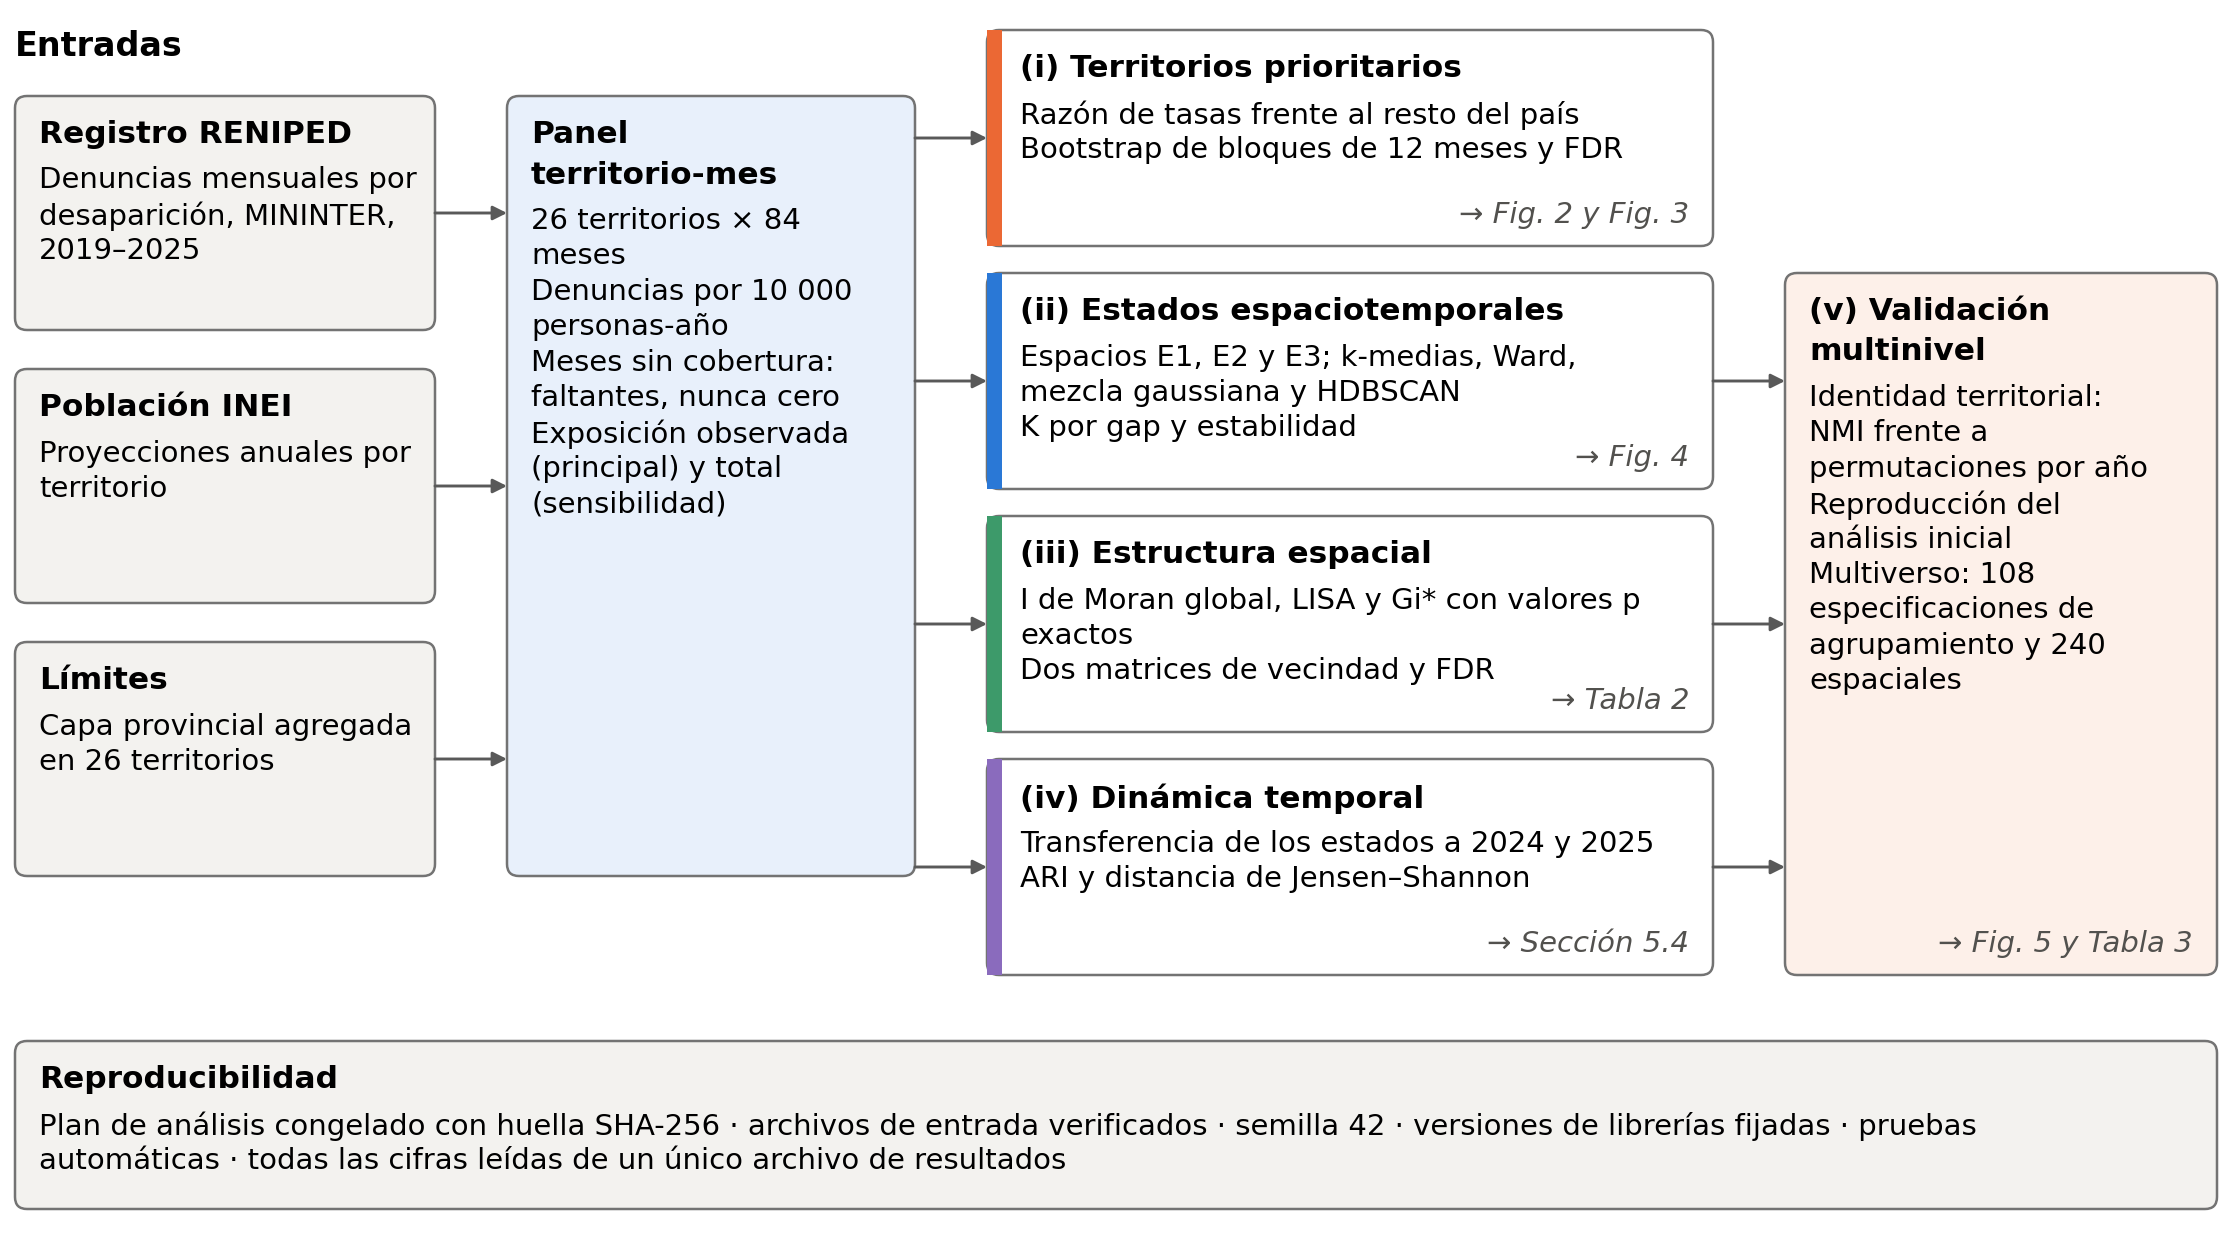

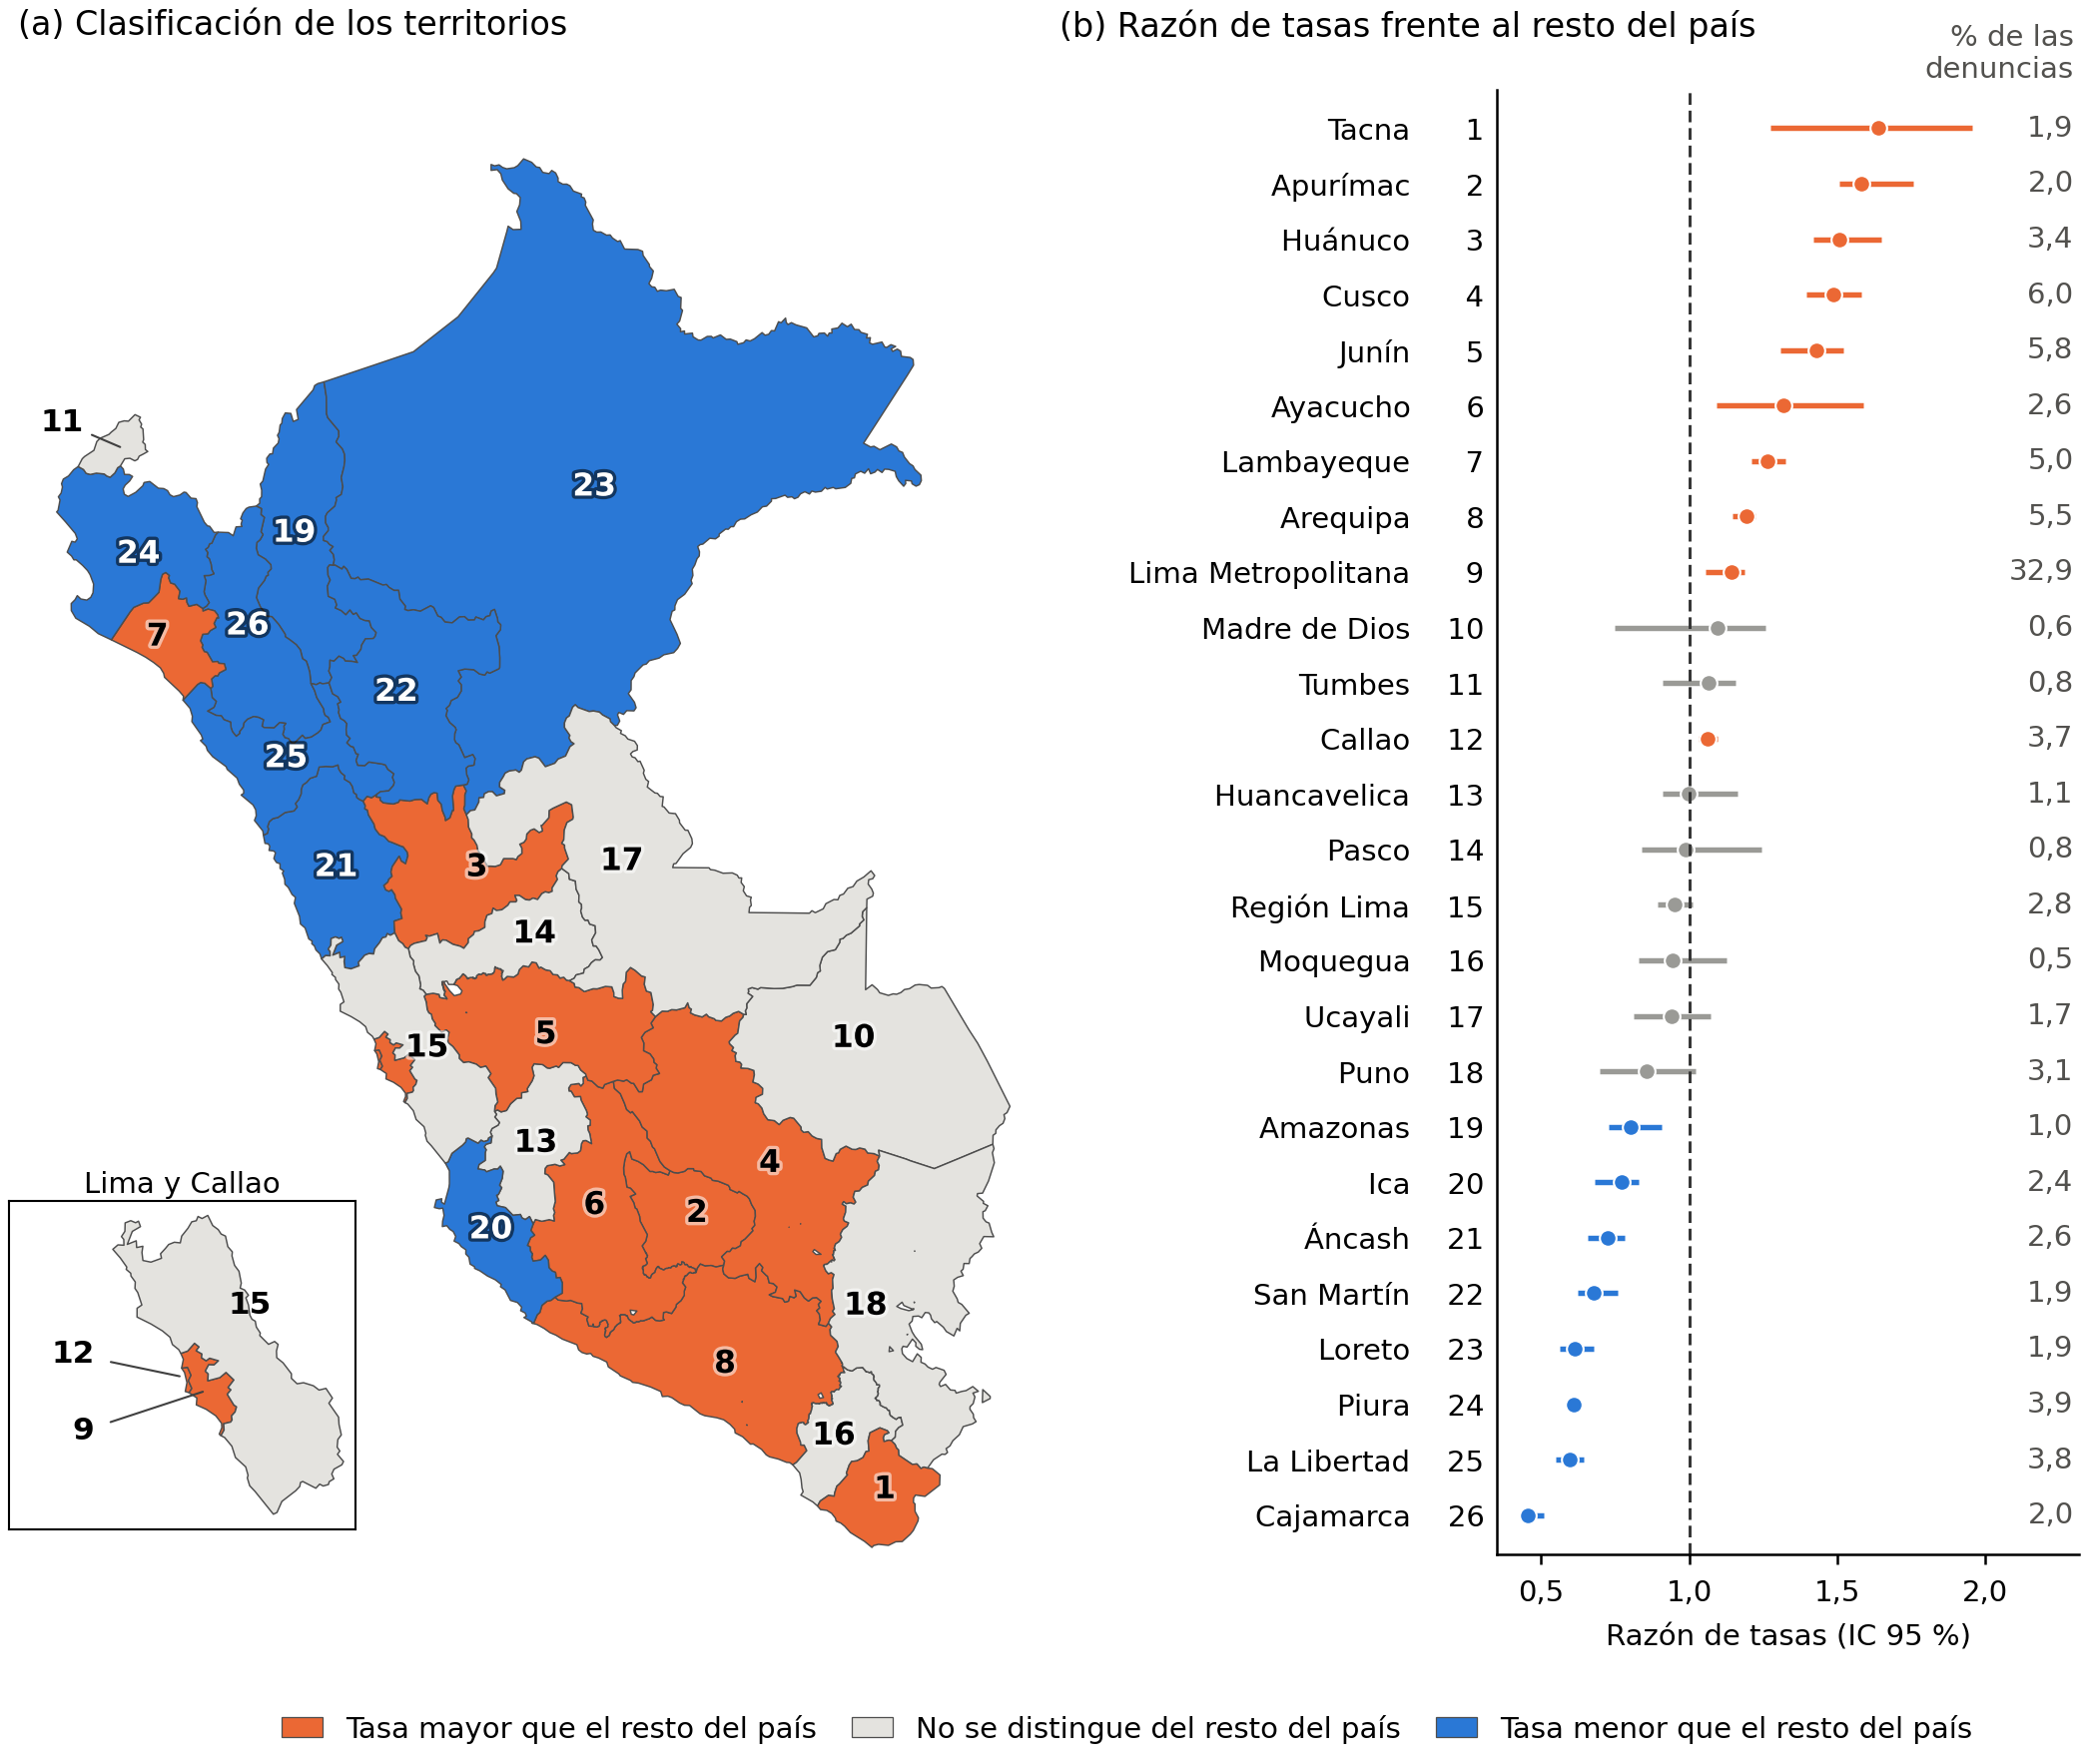

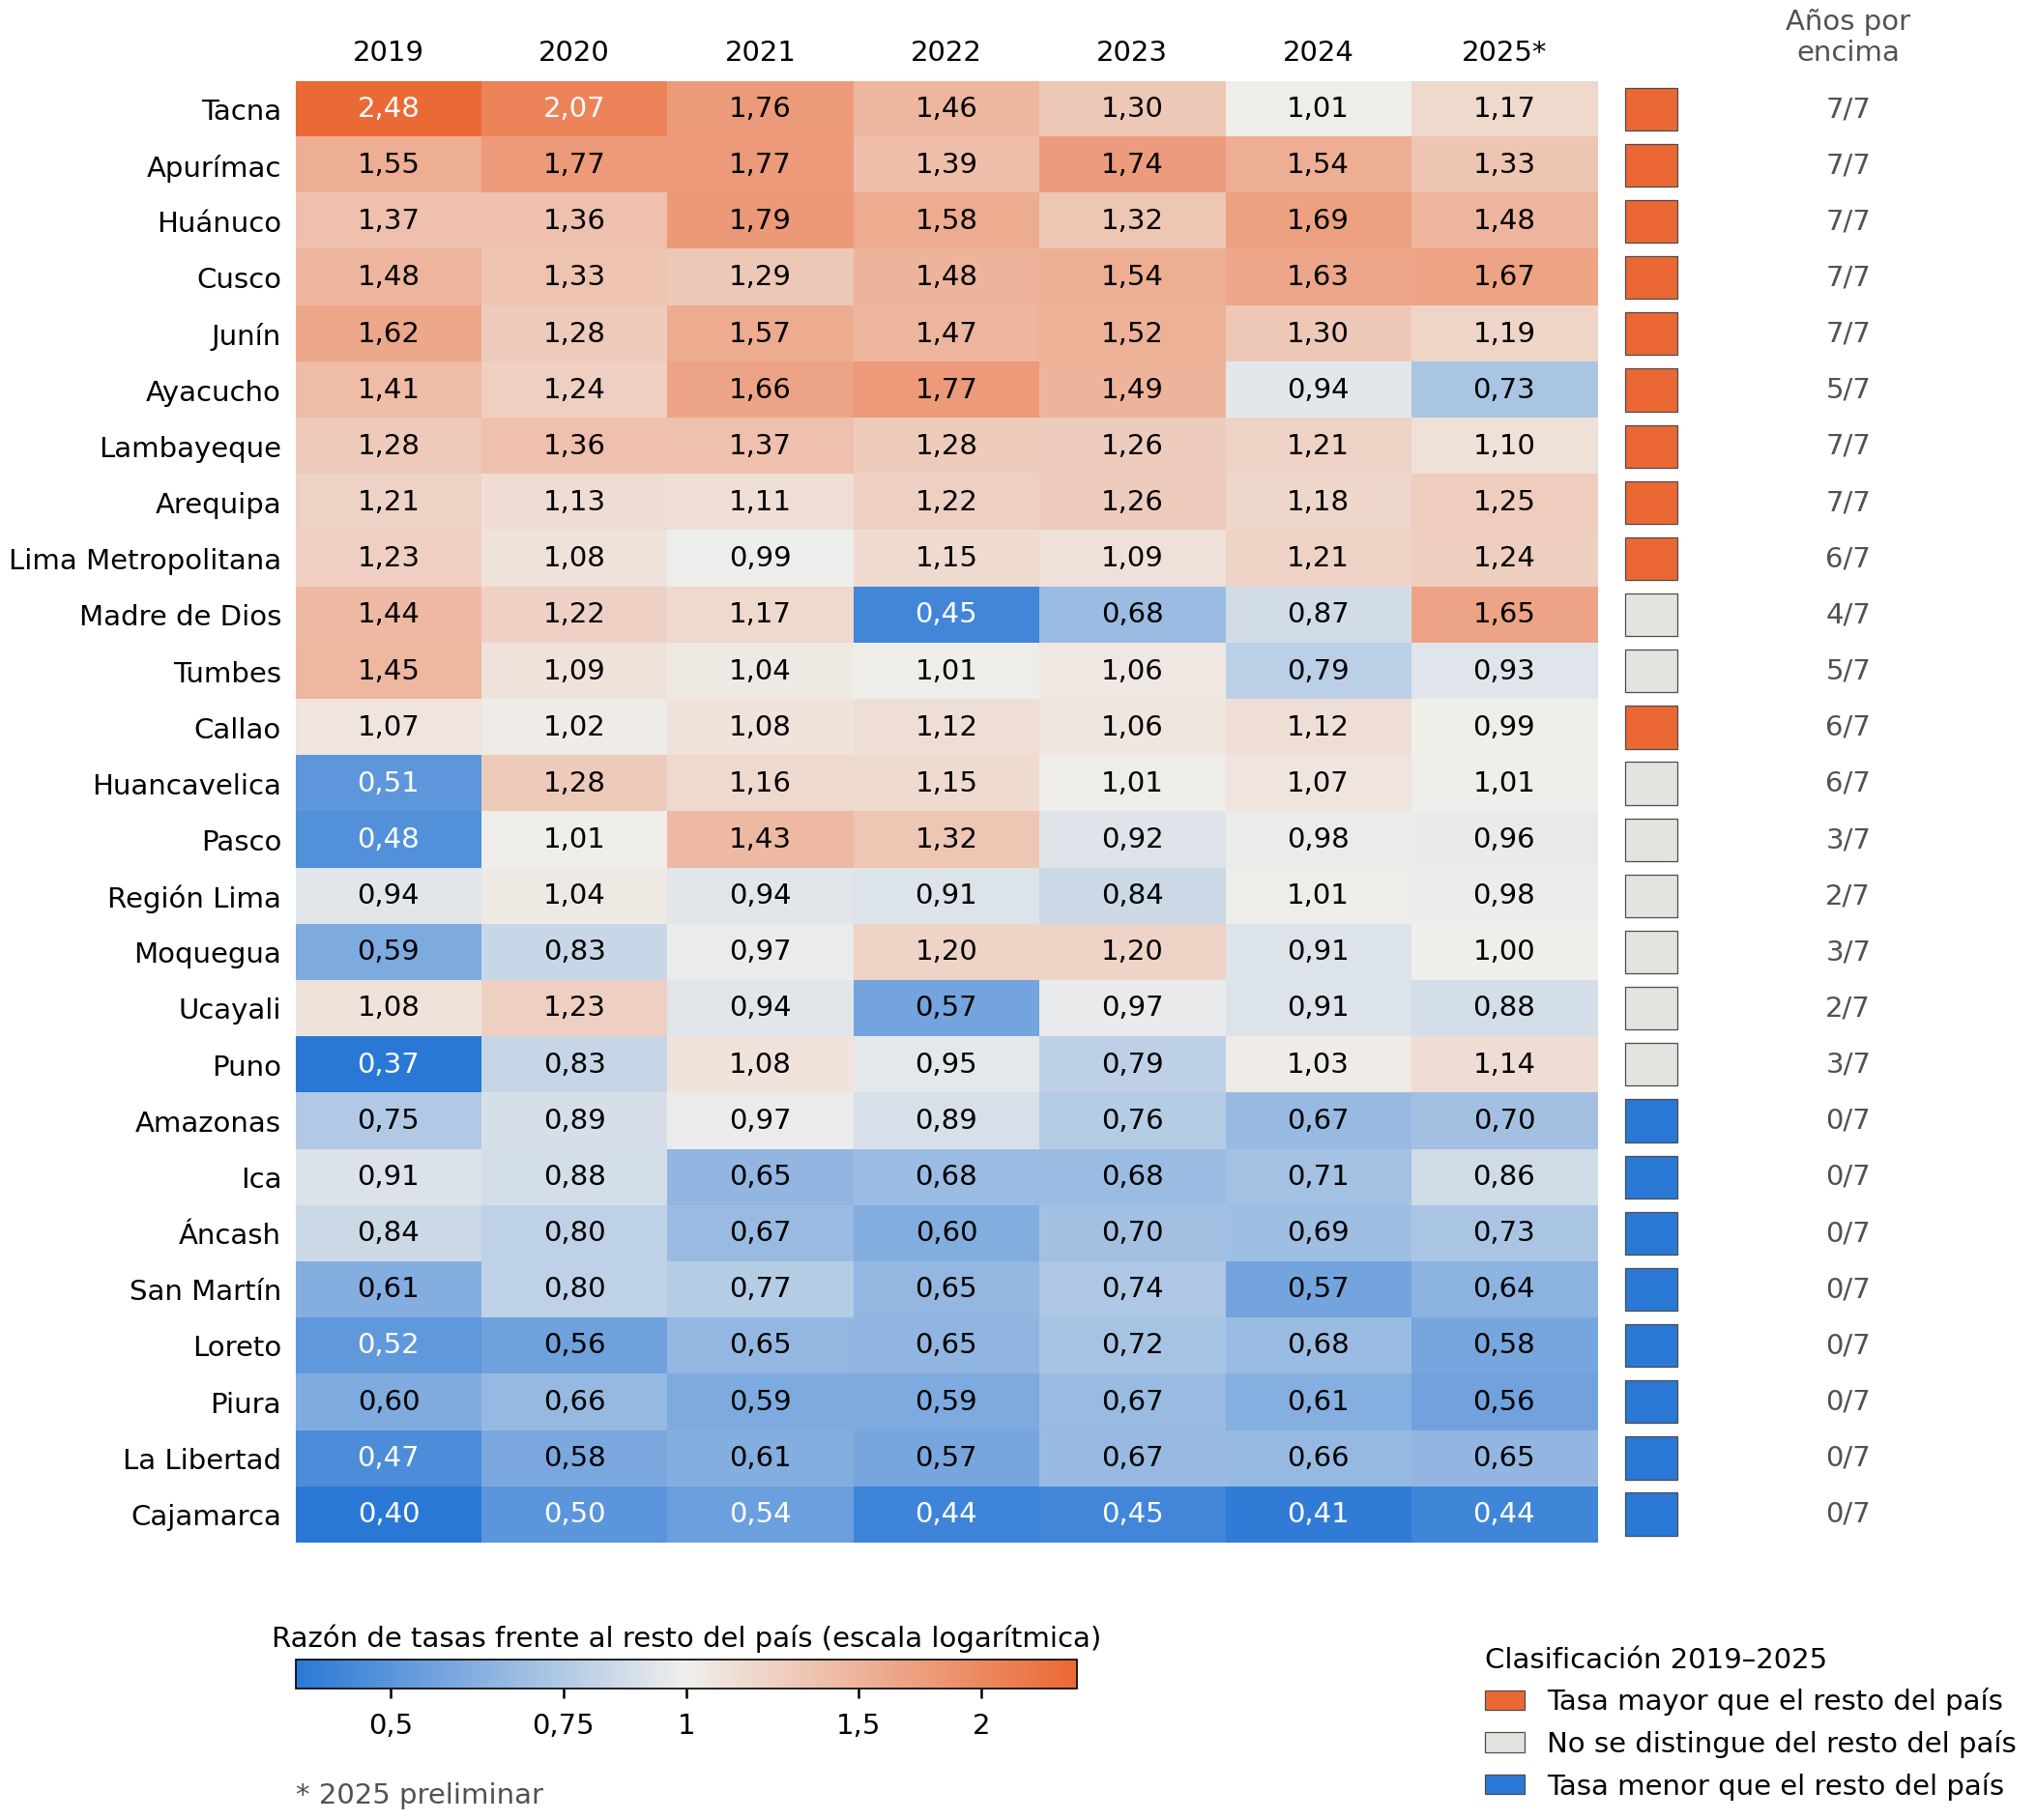

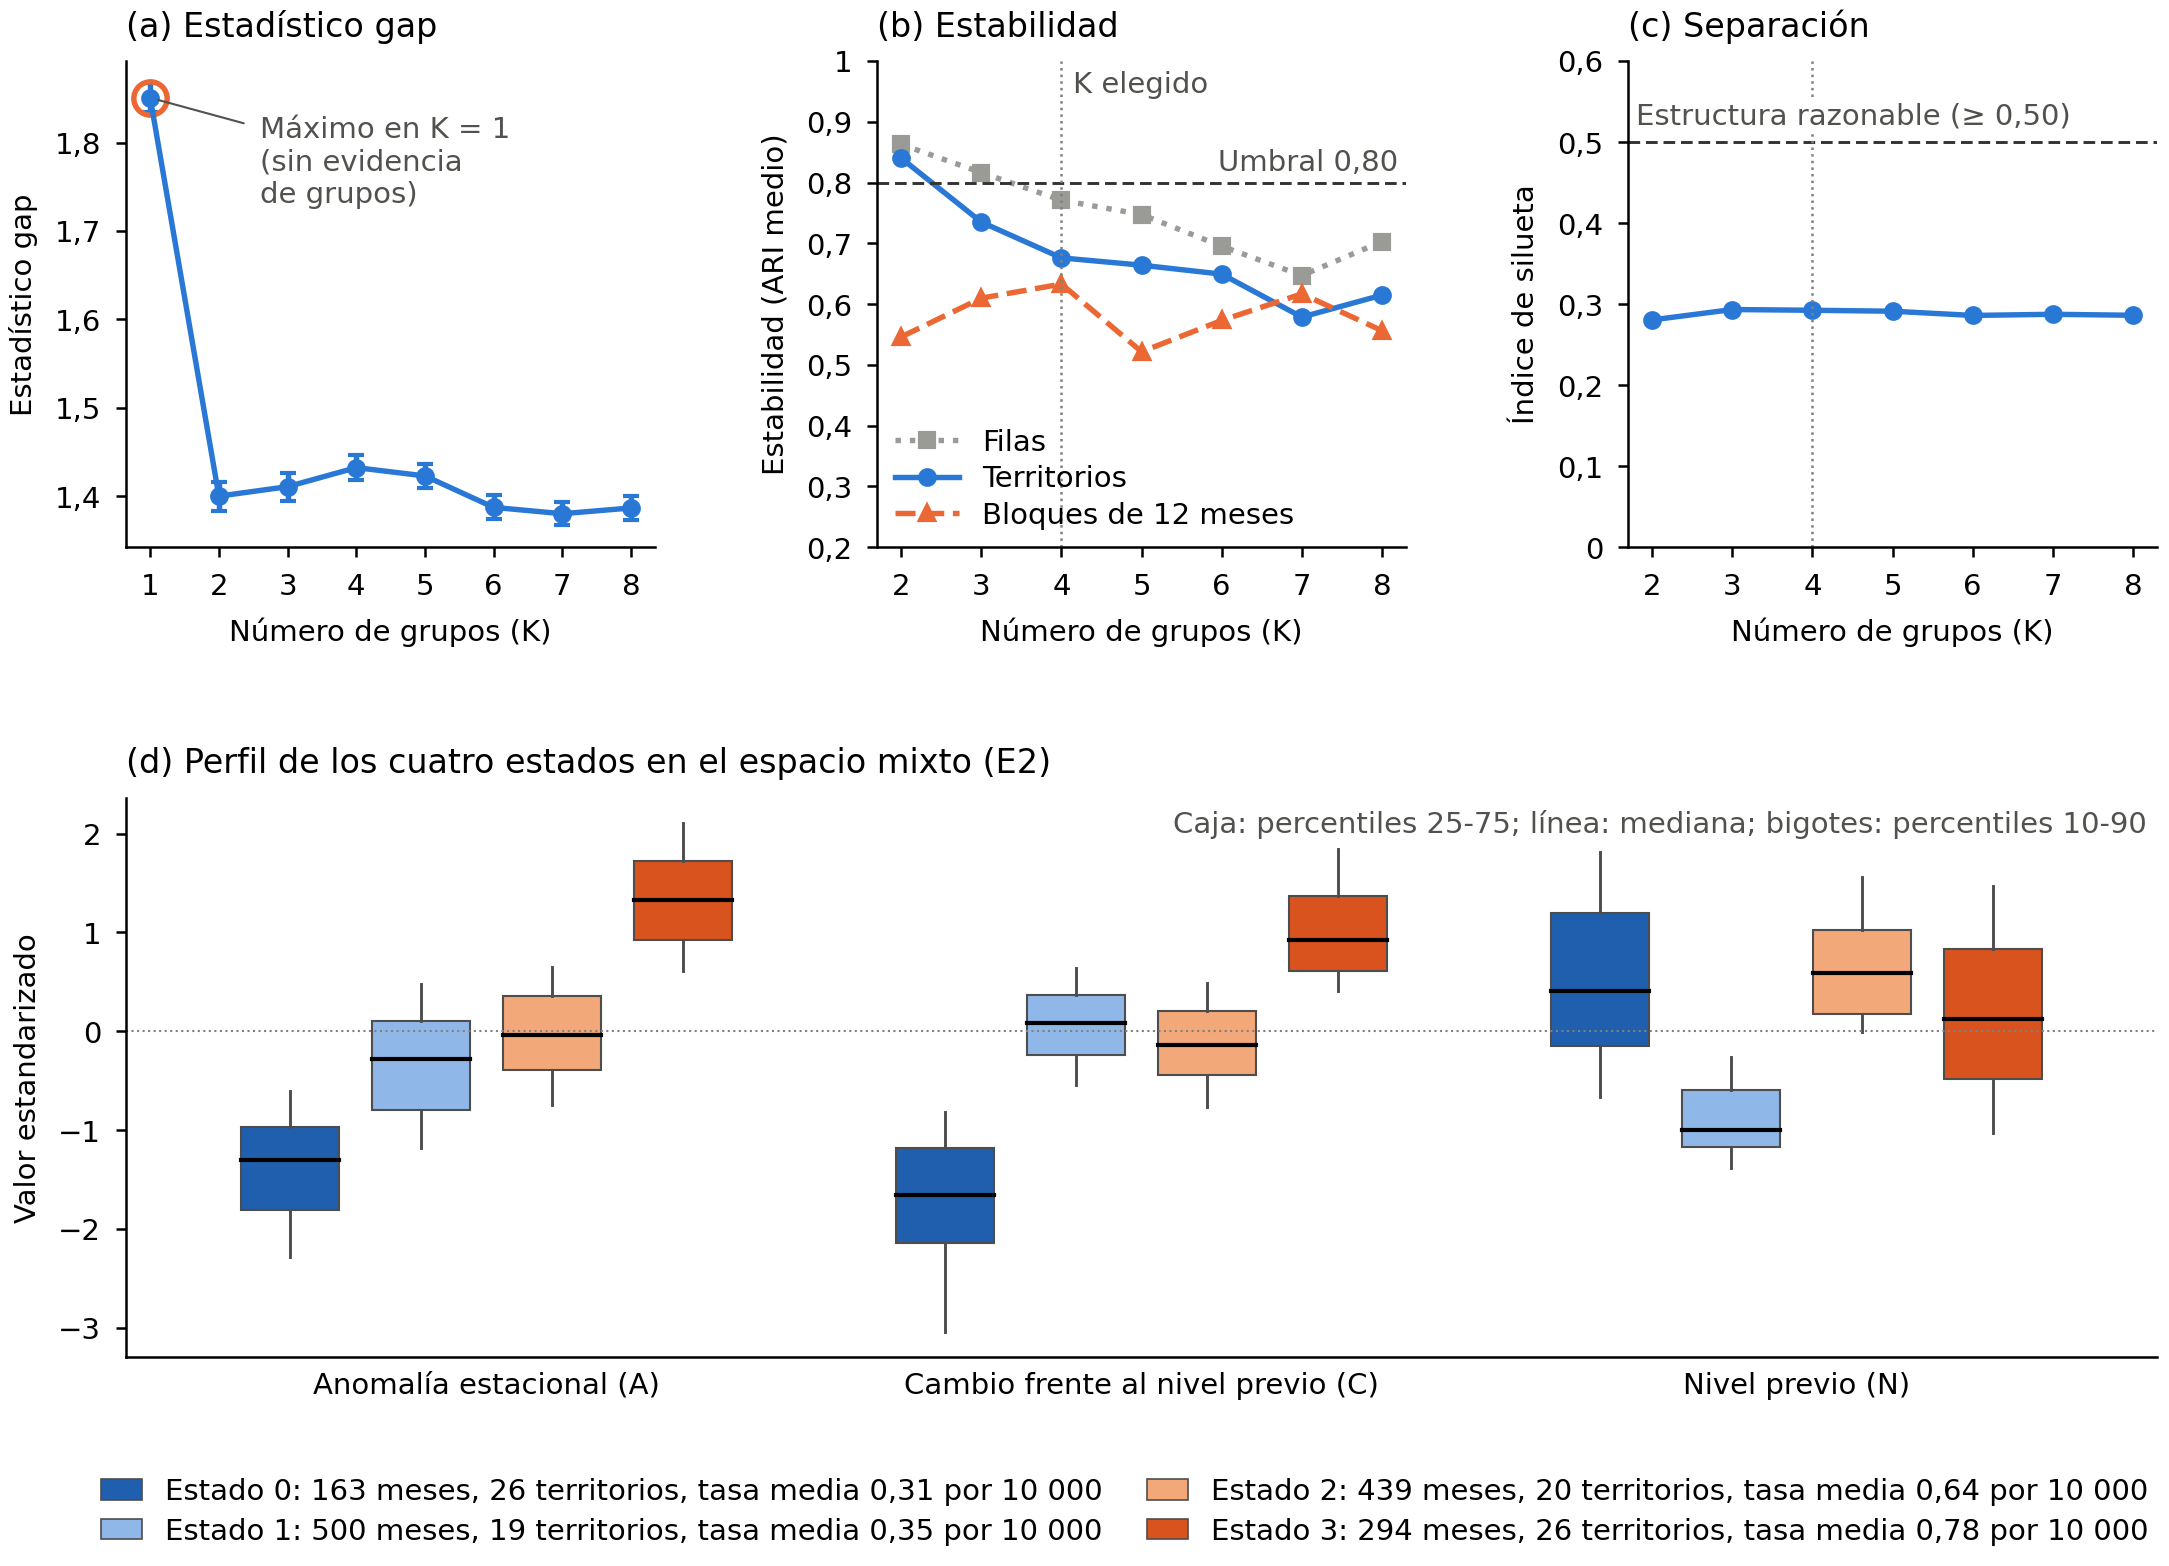

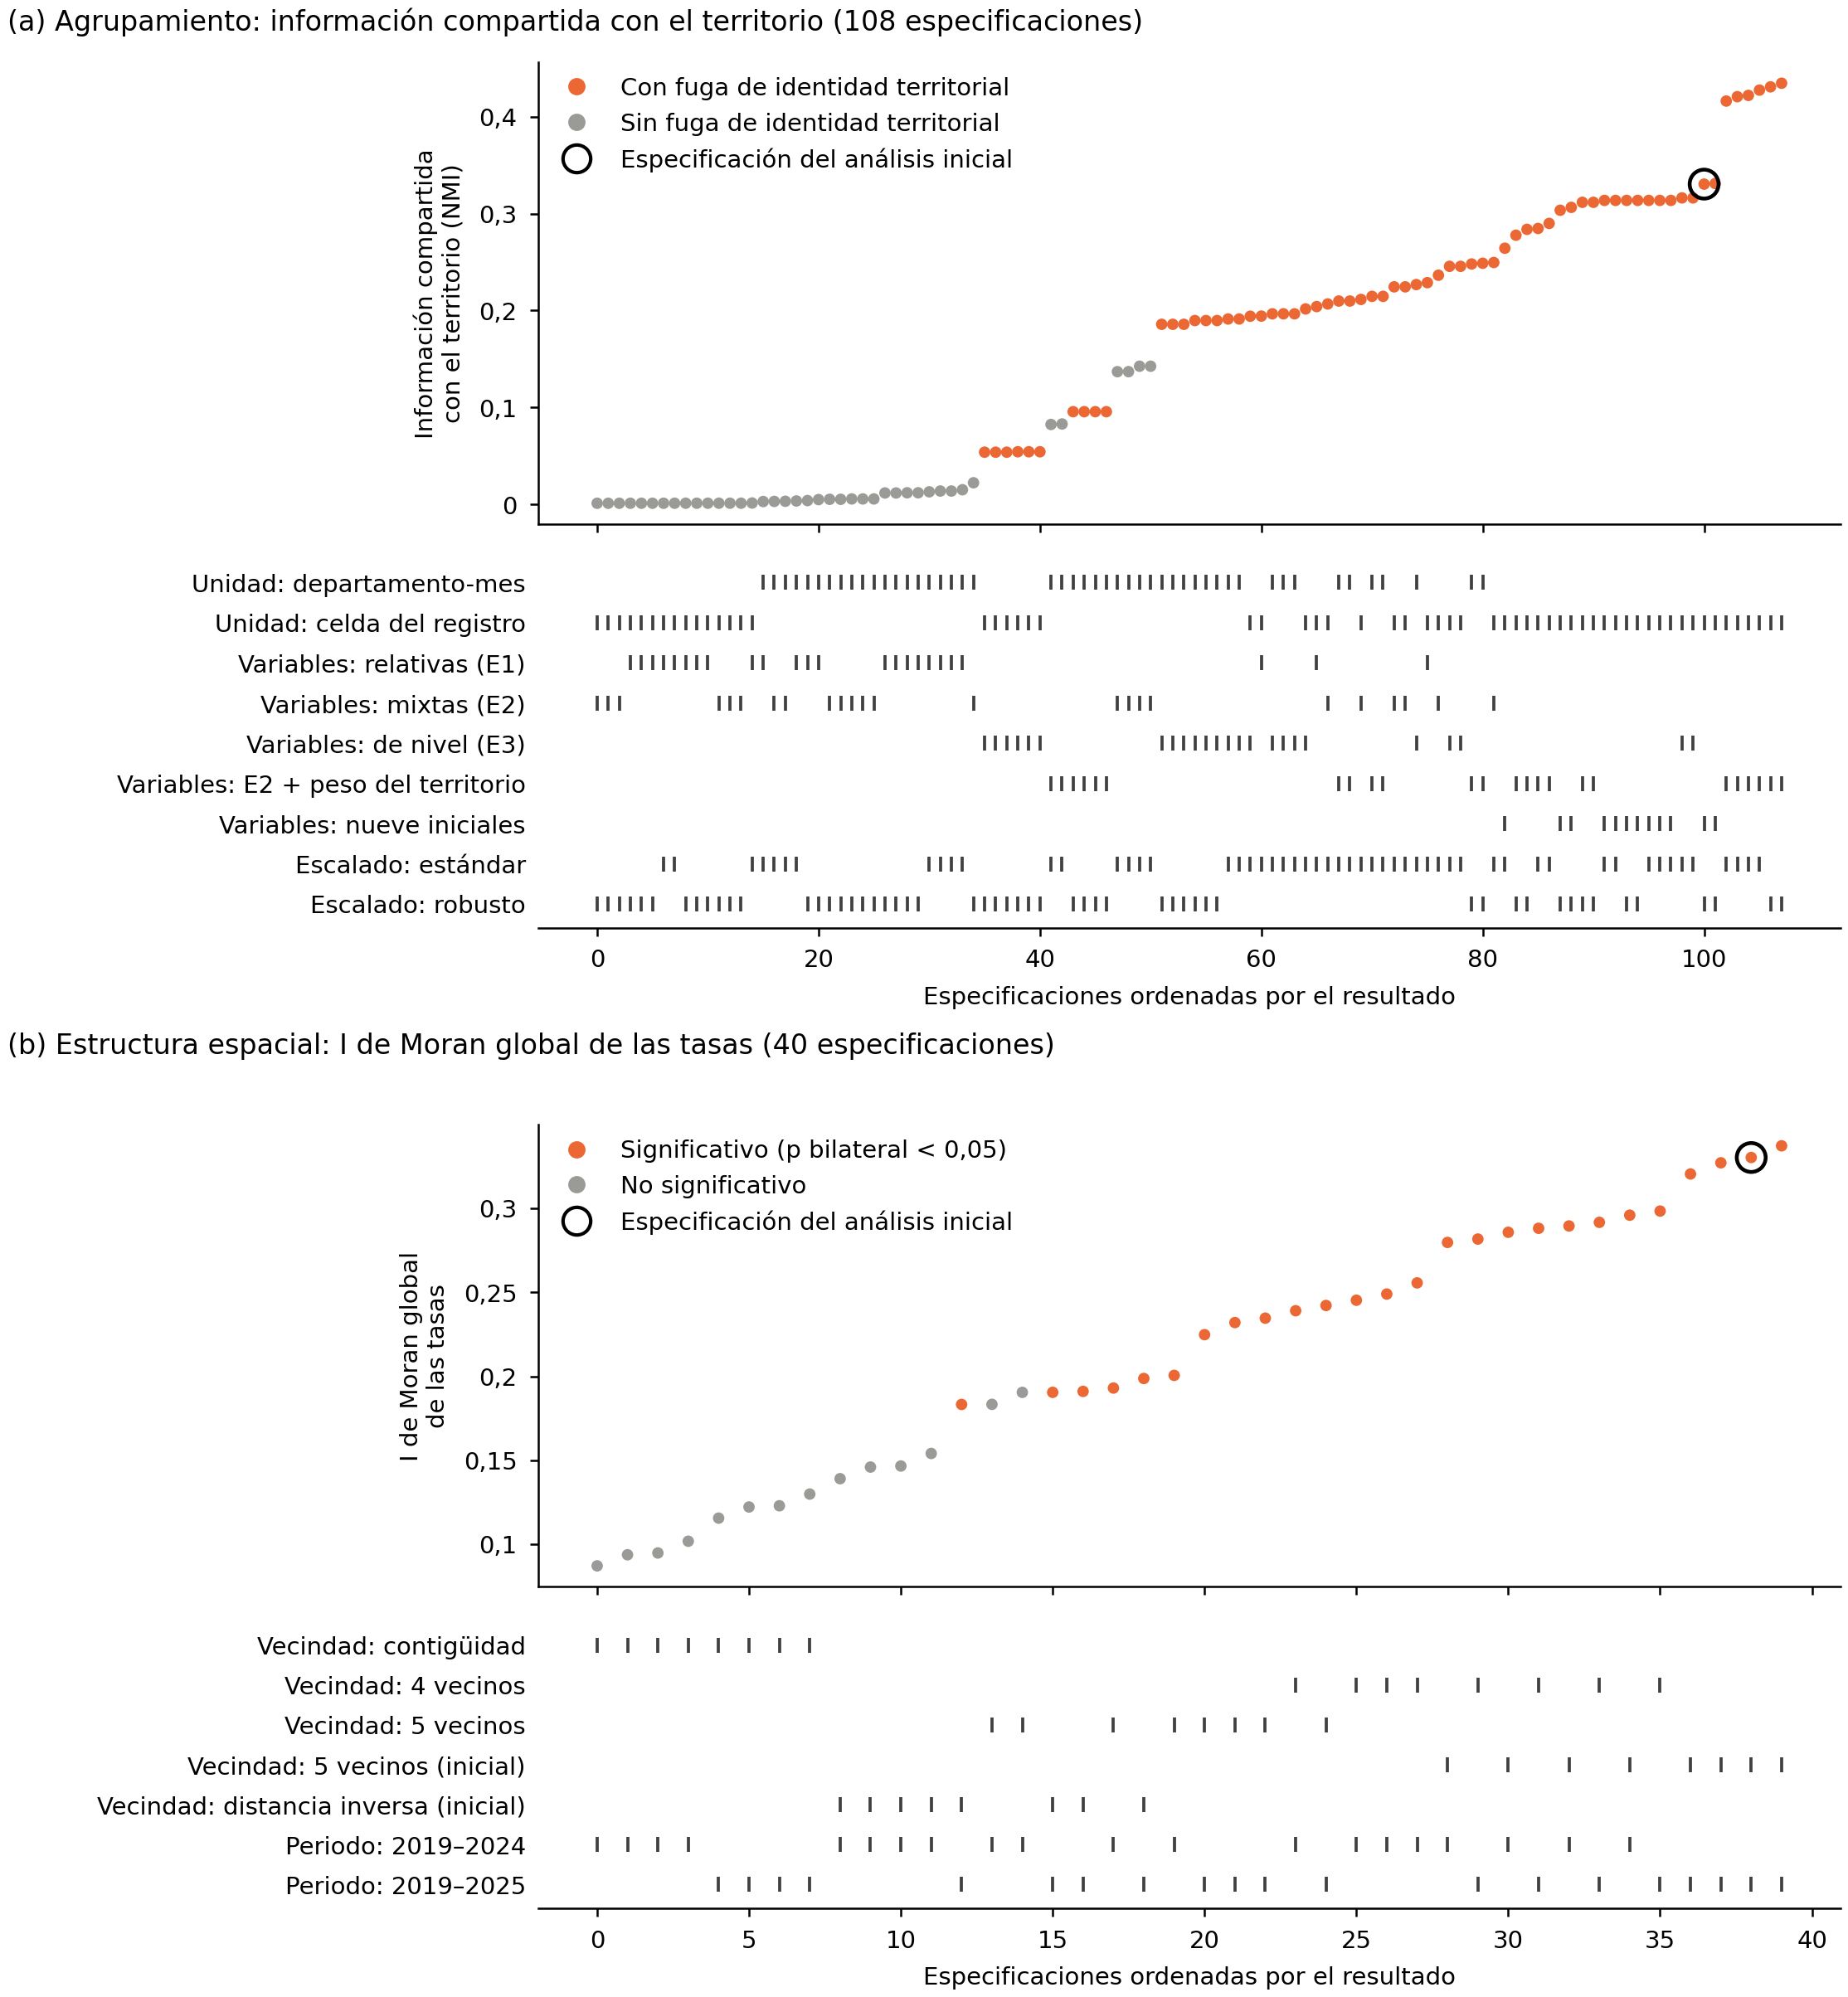

In [34]:
# CELDA 12b — FIGURAS 1-5 DEL ARTÍCULO (español para revisión, inglés para envío)
# Fig. 1 marco, Fig. 2 prioridad, Fig. 3 persistencia, Fig. 4 estados, Fig. 5 validación (letra ≥ 7 pt a 190 mm).
# TIFF: mapa a 600 ppp, gráficos a 1000 ppp (guía de Information Sciences).
ctx = P.stage_article_figures(ctx)
for _f in sorted((ROOT / 'results/figures_article').glob('*_es.png')):
    display(Image(filename=str(_f)))


In [ ]:
# ======================================================================
# CELDA 13 — CIERRE: ENTORNO, DOCUMENTACIÓN, FINAL_RESULTS.json, NOTEBOOK, MANIFIESTO Y ZIP
# ======================================================================
import json
import zipfile
from reniped.docs import write_repository_docs
from reniped.results import freeze_environment, write_manifest, bundle_files

env = freeze_environment(ROOT)
ctx["res"].set("entorno", env)
res_path = ctx["res"].save()
json.loads(res_path.read_text(encoding="utf-8"),
           parse_constant=lambda c: (_ for _ in ()).throw(ValueError(f"JSON no estricto: {c}")))
write_repository_docs(ROOT, PLAN, env)

NB_NAME = f"C26_RENIPED_v{PLAN['version_plan']}_Colab.ipynb"
if EN_COLAB:
    try:
        from google.colab import _message
        nb = _message.blocking_request("get_ipynb", timeout_sec=60)["ipynb"]
        (ROOT / "notebooks" / NB_NAME).write_text(json.dumps(nb, ensure_ascii=False, indent=1),
                                                  encoding="utf-8")
        print(f"  Notebook guardado en notebooks/{NB_NAME}")
    except Exception as e:
        print(f"  No se pudo guardar el notebook automáticamente ({e}); descárgalo y colócalo en notebooks/.")

n = write_manifest(ROOT)
ZIP = ROOT.parent / f"C26_RENIPED_GeoAI_v{PLAN['version_plan']}.zip"
with zipfile.ZipFile(ZIP, "w", zipfile.ZIP_DEFLATED) as z:
    for p in bundle_files(ROOT):
        z.write(p, p.relative_to(ROOT.parent).as_posix())
with zipfile.ZipFile(ZIP) as z:
    en_zip = {x.split("/", 1)[1] for x in z.namelist()}
en_manifiesto = {l.split("  ", 1)[1] for l in (ROOT / "MANIFEST.sha256").read_text().splitlines()}
faltan = en_manifiesto - en_zip
if faltan:
    raise RuntimeError(f"Archivos del manifiesto ausentes en el ZIP: {sorted(faltan)[:5]}")
print(f"Resultados: {res_path.relative_to(ROOT)} (JSON estricto) | manifiesto: {n} archivos, todos en el ZIP")
print(f"ZIP: {ZIP.name} ({ZIP.stat().st_size / 1e6:.1f} MB) | tiempos: {ctx['res'].timings}")
if EN_COLAB:
    from google.colab import files
    files.download(str(ZIP))